In [71]:
import torch
import math
import numpy as np
from tqdm import tqdm
from pyhdf.SD import SD, SDC
from torch.utils.data import Dataset
from os.path import join as path_join
from neuralop import LpLoss
from scipy.ndimage import zoom
import os
from neuralop.losses import H1Loss
import matplotlib.pyplot as plt
import seaborn as sns
from initial_param_dataloader import *
import pandas as pd

In [72]:
data_dict = {}
file_dict = {'vr': "vr002.hdf", 
             'br': "br002.hdf", 
             'vt': "vt002.hdf", 
             'vp': "vp002.hdf", 
             'bt': "bt002.hdf", 
             'bp': "bp002.hdf", 
             'jt': "jt002.hdf", 
             'jp': "jp002.hdf", 
             'jr': "jr002.hdf", 
             'rho': "rho002.hdf", 
             'p': "p002.hdf"
}
FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf", "jt002.hdf", "jp002.hdf", "jr002.hdf", "rho002.hdf", "p002.hdf"]


In [73]:
# b = [read_hdf(path_join(sim_path, f'kpo_mas_mas_std_0101/{file}'), ['Data-Set-2']) for file in FILE_NAMES]

In [74]:
DATA_DIR = "/data/solar_wind_pred_vignesh/hdf/medium"
cr_dirs = get_cr_dirs(DATA_DIR)
sim_path = path_join(DATA_DIR, 'cr1654/kpo_mas_mas_std_0101')

In [75]:
# def get_coords(sim_path):
#     v_path = path_join(sim_path, FILE_NAMES[0])
    
#     thetas, phis = read_hdf(v_path, ["fakeDim1", "fakeDim0"])
#     return thetas, phis

In [76]:
get_coords(sim_path)[0].shape, get_coords(sim_path)[1].shape

((111,), (128,))

In [77]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import torch.nn as nn
import math
import numpy as np
from tqdm import tqdm
from pyhdf.SD import SD, SDC

from os.path import join as path_join
from neuralop import LpLoss
from scipy.ndimage import zoom
import os
from neuralop.losses import H1Loss
from scipy.interpolate import RegularGridInterpolator
import gc

FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf", "jt002.hdf", "jp002.hdf", "jr002.hdf", "rho002.hdf", "p002.hdf"]
# FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf"]

DEFAULT_INSTRUMENTS = [
    "kpo_mas_mas_std_0101",
    "mdi_mas_mas_std_0101",
    "hmi_mast_mas_std_0101",
    "hmi_mast_mas_std_0201",
    "hmi_masp_mas_std_0201",
    "mdi_mas_mas_std_0201",
]


def read_hdf(hdf_path, dataset_names):
    f = SD(hdf_path, SDC.READ)
    datasets = []
    for dataset_name in dataset_names:
        datasets.append(f.select(dataset_name).get())
    return datasets


def get_coords(sim_path):
    v_path = path_join(sim_path, FILE_NAMES[0])
    thetas, phis = read_hdf(v_path, ["fakeDim1", "fakeDim0"])
    return thetas, phis

def interpolate_cube(data, x_old, y_old, z_old, x_new, y_new, z_new):
    interp_func = RegularGridInterpolator(
        (x_old, y_old, z_old),
        data,
        method="linear",
        bounds_error=False,
        fill_value=None,
    )
    xg, yg, zg = np.meshgrid(x_new, y_new, z_new, indexing="ij")
    points_new = np.stack([xg.ravel(), yg.ravel(), zg.ravel()], axis=-1)
    data_new_flat = interp_func(points_new)
    data_new = data_new_flat.reshape((len(x_new), len(y_new), len(z_new)))
    return data_new

def read_sim(sim_path):
    dataset_names = ["Data-Set-2", "fakeDim0", "fakeDim1", "fakeDim2"]
    component_dict = {k.split('002')[0]:{} for k in FILE_NAMES}
    target_phi, target_theta, target_r = [None]*3
    for file_name in FILE_NAMES:
        data, phi, theta, r = read_hdf(f"{sim_path}/{file_name}", dataset_names) 
        comp = file_name.split('002')[0]
        component_dict[comp] = {
            'data': data[:,:, :3],
            'theta': theta,
            'r': r[:3]
        }
        if comp == 'vp':
            target_r = np.array([r[1]], dtype=r.dtype) # [30.742662]
            target_theta = theta
            target_phi = phi
            
    return (component_dict, target_r, target_theta, target_phi)

def get_sim(sim_path, scale_up):
    
    component_list = [k.split('002')[0] for k in FILE_NAMES]
    out, target_r, target_theta, phi = read_sim(sim_path)

    final = dict()
    for component in component_list:
        
        data_old, theta_old, r_old = (
            out[component]["data"],
            out[component]["theta"],
            out[component]["r"],
        )
        # print(f'{component}: Before Interpolation shape: {data_old.shape}')
        data_new = interpolate_cube(data_old, phi, theta_old, r_old, phi, target_theta, target_r)
        data_new = np.transpose(data_new, (2, 1, 0))  # (r, theta, phi)
        # print(f'{component}: After Interpolation shape: {data_new.shape}')
        final[component] = data_new[0,1:-1,:]
        # print(f'{component}: After Cropping shape: {final[component].shape}')

    final_component_arr = np.array([final[comp] for comp in component_list])
    
    if scale_up != 1:
        final_component_arr = enlarge_cube(final_component_arr, scale_up)

    return final_component_arr, (target_r, target_theta[1:-1], phi)


def get_sims(sim_paths, scale_up, pos_emb = None):
    sims = []

    for sim_path in tqdm(sim_paths, desc="Loading simulations"):
        sim, _ = get_sim(sim_path, scale_up)  # (140, 111, 128)
        sims.append(sim)

    sims = np.stack(sims, axis=0)  # (N, 11, 111, 128)
    return sims



def enlarge_cube(cube, scale):
    """
    Enlarge the spatial dimensions (axis 2 and 3) of a 4D cube using bilinear interpolation.

    Parameters:
    - cube: np.ndarray of shape (11, 110, 128)
    - scale: int or float (e.g., 2)

    Returns:
    - enlarged_cube: np.ndarray of shape (11, 110 * scale, 128 * scale)
    """
    return zoom(cube, (1, scale, scale), order=1)

def signed_sqrt_transform(array):
    return np.sign(array) * (np.abs(array)**0.5)

def signed_pow_transform(array, power):
    return np.sign(array) * (np.abs(array)**power)

def signed_log_transform(array):
    return np.sign(array) * np.log(np.abs(array)+1)

def signed_transform(array, transform='sqrt', power=None):
    if transform == 'sqrt':
        return signed_sqrt_transform(array)
    elif transform == 'log':
        return signed_log_transform(array)
    elif transform == 'pow' and power is not None:
        return signed_pow_transform(array, power)
    else:
        raise ValueError("Unsupported transform type or missing power for 'pow' transform.")

def data_transformation(array, transform='sqrt', power=None):
    """
    :param array: (11, H, W)
    Returns: array after data transformation 
    """
    # VR_0 -> No transformation required
    
    # BR_0 -> No transformation required
    # VT_0
    array[:,2] = signed_transform(array[:,2], transform=transform, power=power)   # Sign-preserving data transformation
    # VP_0
    array[:,3] = signed_transform(array[:,3], transform=transform, power=power)   # Sign-preserving data transformation
    # BT_0
    array[:,4] = signed_transform(array[:,4], transform=transform, power=power)   # Sign-preserving data transformation
    # BP_0
    array[:,5] = signed_transform(array[:,5], transform=transform, power=power)   # Sign-preserving data transformation
    # JT_0 -> No transformation required
    # JP_0
    array[:,7] = signed_transform(array[:,7], transform=transform, power=power)   # Sign-preserving data transformation
    # JR_0
    array[:,8] = signed_transform(array[:,8], transform=transform, power=power)   # Sign-preserving data transformation
    # RHO_0 -> No transformation required
    array[:,9] = signed_sqrt_transform(array[:,9])   # Sign-preserving square root transformation
    # P_0 
    array[:,10] = signed_transform(array[:,10], transform='pow', power=0.25)   # Sign-preserving POW(0.25) transformation
    return array


def signed_power_inverse_transform(array, power):
    return torch.sign(array) * (torch.abs(array)**power)

def signed_exp_inverse_transform(array):
    return torch.sign(array) * torch.exp(torch.abs(array))

def signed_inverse_transform(array, transform='square', power=None):
    if transform == 'square':
        return signed_power_inverse_transform(array, power=2)
    elif transform == 'exp':
        return signed_exp_inverse_transform(array - 1)  # Subtract 1 to reverse the +1 in the log transform
    elif transform == 'pow' and power is not None:
        return signed_power_inverse_transform(array, power=power)
    else:
        raise ValueError("Unsupported inverse transform type or missing power for 'pow' inverse transform.")

def data_inverse_transformation(array,inverse_transform, power=None, scale_metric=481.3711):
    """
    :param array: (9, H, W)  
    Returns: array after data transformation 
    """
    # VR_0 -> No inverse transformation required
    
    # BR_0 -> No inverse transformation required
    # VT_0
    array[:, 0] = signed_inverse_transform(array[:, 0], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # VP_0
    array[:,1] = signed_inverse_transform(array[:, 1], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # BT_0
    array[:, 2] = signed_inverse_transform(array[:, 2], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # BP_0
    array[:, 3] = signed_inverse_transform(array[:, 3], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # JT_0 -> No inverse transformation required
    # JP_0
    array[:, 5] = signed_inverse_transform(array[:, 5], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # JR_0
    array[:, 6] = signed_inverse_transform(array[:, 6], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # RHO_0 -> No inverse transformation required
    array[:, 7] = signed_inverse_transform(array[:, 7], transform='square')   # Sign-preserving inverse square transformation
    # P_0 
    array[:, 8] = signed_inverse_transform(array[:, 8], transform='pow', power=4)   # Sign-preserving inverse POW(4) transformation

    return array * scale_metric

def min_max_normalize(array, min_=None, max_=None):
    if min_ is None or max_ is None:
        min_ = np.min(array, axis=(0,2,3))
        max_ = np.max(array, axis=(0,2,3))
    array = (array - min_[:,None, None]) / (max_[:,None, None] - min_[:,None, None] + 1e-9)
    return array, min_, max_

def min_max_denormalize(array, min_, max_):
    '''
    Denormalize the data using the provided min and max values.
    :param array: Normalized array of shape (N, 11, H, W)
    :param min_: Minimum values for each channel (shape: (11,))
    :param max_: Maximum values for each channel (shape: (11,))
    '''
    array = array * (max_[:, None, None] - min_[:, None, None] + 1e-9) + min_[:, None, None]
    return array

def compute_climatology(data: np.ndarray, scale_up) -> np.ndarray:
    """
    Compute per-voxel climatology (mean field) from a dataset.

    Args:
        data (np.ndarray): Array of shape (N, 9, 109, 128)

    Returns:
        np.ndarray: Climatology array of shape (9, 109, 128)
    """
    assert data.ndim == 4 and data.shape[1:] == (
        9,
        109 * scale_up,
        128 * scale_up,
    ), "Unexpected input shape."
    climatology = np.mean(data, axis=0)
    climatology = torch.tensor(climatology, dtype=torch.float32)
    return climatology


def get_cr_dirs(data_path):
    """Return list of CR directories (crXXXX) inside data_path."""
    cr_dirs = sorted(
        [
            d
            for d in os.listdir(data_path)
            if d.startswith("cr") and os.path.isdir(os.path.join(data_path, d))
        ]
    )
    return cr_dirs


def collect_sim_paths(data_path, cr_list, instruments=None):
    """Collect simulation paths given a list of CR directories."""
    if instruments is None:
        instruments = DEFAULT_INSTRUMENTS

    sim_paths = []
    cr_nums = []
    for cr in cr_list:
        cr_path = os.path.join(data_path, cr)
        for instrument in instruments:
            instrument_path = os.path.join(cr_path, instrument)
            if os.path.exists(instrument_path):
                sim_paths.append(instrument_path)
                cr_nums.append(cr)
    return sim_paths, cr_nums


class InitialParamDataset(Dataset):
    def __init__(
        self,
        data_path,
        cr_list,
        v_min=None,
        v_max=None,
        instruments=None,
        scale_up=1,
        pos_embedding = None,
        transform=None,
        transform_fn = None
    ):
        super().__init__()
        if transform == 'pow':
            self.transform = 'pow'
            self.inverse_transform = 'pow'
            self.transform_power = 0.5
            self.inverse_transform_power = 2
        elif transform in {'sqrt', 'log'}:
            self.transform = transform
            self.inverse_transform = 'exp' if transform == 'log' else 'square'
            self.transform_power = None
            self.inverse_transform_power = None
        
        self.sim_paths, self.cr_mapping = collect_sim_paths(data_path, cr_list, instruments)
        self.sims = get_sims(self.sim_paths, scale_up, pos_embedding)
        self.climatology = compute_climatology(self.sims[:,2:], scale_up)
        print(self.sims.shape)

        _, (r,theta,phi) = get_sim(self.sim_paths[0], scale_up)
        self.r = torch.tensor(r, dtype=torch.float32)
        self.theta = torch.tensor(theta, dtype=torch.float32)
        self.phi = torch.tensor(phi, dtype=torch.float32)

        # self.sims = data_transformation(self.sims, self.transform, power=self.transform_power)
        self.sims, self.v_min, self.v_max = min_max_normalize(self.sims, v_min, v_max)

        self.data_min = torch.tensor([ 4.67303783e-01, -1.58353511e-03, -7.15157911e-02, -3.33132781e-02,
       -1.28728367e-04, -2.80083535e-04, -4.16646682e-04, -1.07131642e-03,
       -1.45251848e-04,  1.45591866e-06,  1.14962724e-07], dtype=torch.float32)
        self.data_max = torch.tensor([1.3710672e+00, 1.6776990e-03, 7.1827546e-02, 6.5376662e-02,
       8.6796281e-05, 2.7548801e-04, 3.7248712e-04, 1.0954458e-03,
       1.5482063e-04, 1.2102652e-05, 4.1580401e-07], dtype=torch.float32)

        

    def __getitem__(self, index):
        cube = self.sims[index]

        C, H, W = cube.shape

        return {
            "x": torch.from_numpy(cube[:2]).float(),
            "y": torch.from_numpy(cube[2:]).float(),
            'cr': self.cr_mapping[index],
            'idx': index
        }

    def __len__(self):
        return len(self.sims)

    def get_min_max(self):
        return {"v_min": [float(v) for v in self.v_min], "v_max": [float(v) for v in self.v_max]}

    def get_grid_points(self):
        return get_coords(self.sim_paths[0])


In [78]:
1999872/(4*256*9)

217.0

In [79]:
train_data = InitialParamDataset(
    DATA_DIR,
    cr_dirs[:3],
    transform='sqrt'
)

Loading simulations: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  7.46it/s]


(3, 11, 109, 128)


In [80]:
train_data.theta

tensor([0.0144, 0.0432, 0.0721, 0.1009, 0.1297, 0.1585, 0.1873, 0.2162, 0.2450,
        0.2738, 0.3026, 0.3315, 0.3603, 0.3891, 0.4179, 0.4467, 0.4756, 0.5044,
        0.5332, 0.5620, 0.5908, 0.6197, 0.6485, 0.6773, 0.7061, 0.7350, 0.7638,
        0.7926, 0.8214, 0.8502, 0.8791, 0.9079, 0.9367, 0.9655, 0.9944, 1.0232,
        1.0520, 1.0808, 1.1096, 1.1385, 1.1673, 1.1961, 1.2249, 1.2538, 1.2826,
        1.3114, 1.3402, 1.3690, 1.3979, 1.4267, 1.4555, 1.4843, 1.5132, 1.5420,
        1.5708, 1.5996, 1.6284, 1.6573, 1.6861, 1.7149, 1.7437, 1.7725, 1.8014,
        1.8302, 1.8590, 1.8878, 1.9167, 1.9455, 1.9743, 2.0031, 2.0319, 2.0608,
        2.0896, 2.1184, 2.1472, 2.1761, 2.2049, 2.2337, 2.2625, 2.2913, 2.3202,
        2.3490, 2.3778, 2.4066, 2.4355, 2.4643, 2.4931, 2.5219, 2.5507, 2.5796,
        2.6084, 2.6372, 2.6660, 2.6949, 2.7237, 2.7525, 2.7813, 2.8101, 2.8390,
        2.8678, 2.8966, 2.9254, 2.9542, 2.9831, 3.0119, 3.0407, 3.0695, 3.0984,
        3.1272])

In [ ]:
old_data, r,t,p = read_sim(sim_path)

In [ ]:
for comp in file_dict.keys():
    print(f"{comp}: R=> {old_data[comp]['r']}||T=> {old_data[comp]['theta'][:3]}|| data_shape=> {old_data[comp]['data'].shape}")

In [ ]:
61.4855/2

In [ ]:
new_data, (new_r, new_t, new_p) = get_sim(sim_path, 1)

In [ ]:
for comp in file_dict.keys():
    print(f"{comp}: R=> {new_data.shape}")

In [ ]:
new_data.shape

In [ ]:
radii

In [ ]:
r

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pred = np.random.randn(9,110,128)
y_true = np.random.randn(9,110,128)

In [ ]:
plt.imshow(pred[0])
plt.show()

In [81]:
LABELS = ["vt", "vp", "bt", "bp", "jt", "jp", "jr", "rho", "p"]

NameError: name 'y_true' is not defined

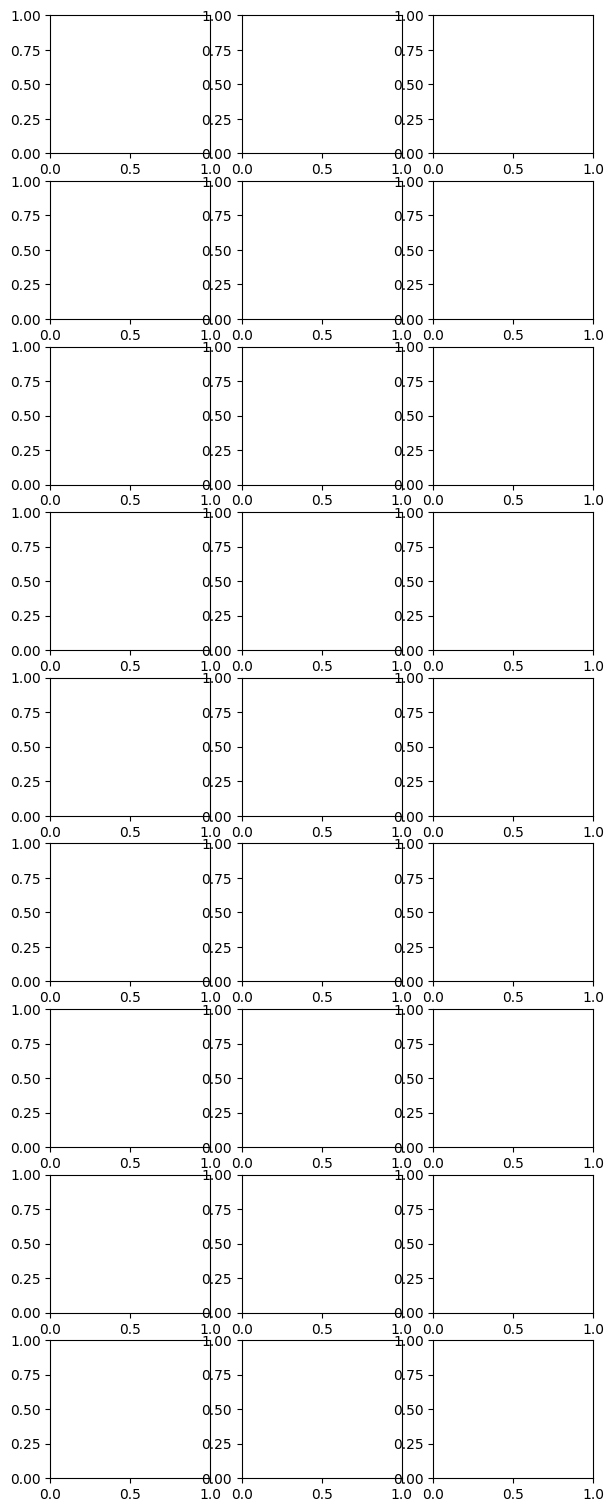

In [82]:
fig, ax = plt.subplots(9,3, figsize=(7,19))
for i in range(9):
    vmin = np.min([y_true[i].min(), pred[i].min()])
    vmax = np.max([y_true[i].max(), pred[i].max()])

    im0 = ax[i, 0].imshow(y_true[i], cmap='viridis', vmin=vmin, vmax=vmax)
    ax[i, 0].axis('off')
    ax[i, 0].set_title(f'{LABELS[i]} True')

    im1 = ax[i, 1].imshow(pred[i], cmap='viridis', vmin=vmin, vmax=vmax)
    ax[i, 1].axis('off')
    ax[i, 1].set_title(f'{LABELS[i]} Prediction')
    ax[i, 2].axis('off')
    # colorbar for each image, same scale (vmin/vmax) within the row
    # fig.colorbar(im0, ax=ax[i, 0], fraction=0.046, pad=0.02)
    fig.colorbar(im1, ax=ax[i, 2], fraction=0.04, pad=0.03)
plt.tight_layout()

plt.show()

In [83]:
b['x'].shape, b['y'].shape

NameError: name 'b' is not defined

In [ ]:
# plt.hist(b['y'][0].reshape(-1))
# plt.show()

save_filepath = 'histogram_distribution'
save_filename = 'Signed_MIXED_normalization'
fig, ax = plt.subplots(3,3, figsize=(19,16))
for i in range(9):
    data = b['y'][i]
    postfix = 'True'
    if LABELS[i] in {'vt', 'vp','bt', 'jp', 'jr'}:
        data = np.sign(data)* (np.abs(data)**0.5)
        # data=np.sign(data)* np.log(np.abs(data))
        postfix = 'SQRT transform'
        data = data.reshape(-1)
    elif LABELS[i] in {'rho', 'p'}:
        data = np.sign(data)* (np.abs(data)**(1/16))
        postfix = 'square transform'
        data = data.reshape(-1)
    else:
        data = data.reshape(-1)
    ax[i//3, i%3].hist(data, bins=20)
    ax[i//3, i%3].set_title(f'{LABELS[i]} {postfix}')
    # ax[i//3, i%3].set_yscale('log')
    ax[i//3, i%3].grid(axis='y', linestyle='--', which='major')
plt.suptitle(f'Distribution of variables for R_0 with Sign Preserving Transformation')
plt.tight_layout()
# plt.savefig(f'{save_filepath}/{save_filename}.png', dpi=200)
# plt.savefig(f'{save_filepath}/{save_filename}.pdf', dpi=200)
plt.show()

In [ ]:
INPUT_LABELS = ['vr', 'br']
fig, ax = plt.subplots(1,2, figsize=(13,8))
for i in range(2):
    data = b['x'][i]
    postfix = 'True'
    # if LABELS[i] in {'vt', 'vp','bt', 'jp', 'jr'}:
    #     data = np.sign(data)* (np.abs(data)**0.5)
    #     # data=np.sign(data)* np.log(np.abs(data))
    #     postfix = 'SQRT transform'
    #     data = data.reshape(-1)
    # elif LABELS[i] in {'rho', 'p'}:
    #     data = np.sign(data)* (np.abs(data)**0.25)
    #     postfix = 'square transform'
    #     data = data.reshape(-1)
    # else:
    data = data.reshape(-1)
    ax[i%2].hist(data, bins=20)
    ax[i%2].set_title(f'{INPUT_LABELS[i]} {postfix}')
    # ax[i//3, i%3].set_yscale('log')
    ax[i%2].grid(axis='y', linestyle='--', which='major')
plt.suptitle(f'Distribution of variables for R_0')
plt.tight_layout()
# plt.savefig(f'{save_filepath}/{save_filename}.png', dpi=200)
plt.savefig(f'{save_filepath}/input_variables.pdf', dpi=200)
plt.show()

In [ ]:
def sqrt_transform(X):
    return np.sign(X)*np.sqrt(np.abs(X))
def log_transform(X):
    return np.sign(X)*np.log(np.abs(X))
def power_transform(X, power=2):
    return np.sign(X)*np.power(np.abs(X), power)
def exp_transform(X):
    return np.exp(X)

In [ ]:
feat = LABELS.index('p')
feat

In [ ]:
fig, ax = plt.subplots(2,3, figsize=(15,8))

ax[0,0].hist(b['y'][feat].reshape(-1), bins=50)
ax[0,0].set_title('vt no transformation')
ax[0,0].grid(axis='y', linestyle='--', which='major')

ax[0,1].hist(sqrt_transform(b['y'][feat]).reshape(-1), bins=50)
ax[0,1].set_title('vt signed sqrt transform')
ax[0,1].grid(axis='y', linestyle='--', which='major')

ax[0,2].hist(log_transform(b['y'][feat]).reshape(-1), bins=50)
ax[0,2].set_title('vt signed log transform')
ax[0,2].grid(axis='y', linestyle='--', which='major')

ax[1,0].hist(power_transform(b['y'][feat], 0.25).reshape(-1), bins=50)
ax[1,0].set_title('vt signed POWER(0.25) transformation')
ax[1,0].grid(axis='y', linestyle='--', which='major')

ax[1,1].hist(power_transform(b['y'][feat], 1/2.2).reshape(-1), bins=50)
ax[1,1].set_title('vt signed gamma [POWER(1/2.2)] transform')
ax[1,1].grid(axis='y', linestyle='--', which='major')

ax[1,2].hist(exp_transform(b['y'][feat]).reshape(-1), bins=50)
ax[1,2].set_title('vt Exponential transform')
ax[1,2].grid(axis='y', linestyle='--', which='major')

plt.suptitle(f'Data transformation of feature {LABELS[feat]}')
plt.savefig(f'{save_filepath}/possible_transforms/{LABELS[feat]}.pdf', dpi=200)
plt.tight_layout()
plt.show()

In [ ]:
def get_sim(sim_path, scale_up):
    # (v_path,) = [path_join(sim_path, file_name) for file_name in FILE_NAMES]
    v_list = [read_hdf(path_join(sim_path, file_name), ['Data-Set-2'])[0] for file_name in FILE_NAMES]
    print(v_list[0].shape)
    v_0 = np.array([t for t in v[0]])
    v_0 = v_0.transpose(2,1,0)

    if scale_up != 1:
        v_0 = enlarge_cube(v_0, scale_up)
    return v_0

In [ ]:
v = get_sim(sim_path, 1)
# file_name = FILE_NAMES[0]
# v = read_hdf(path_join(sim_path, file_name), ['Data-Set-2'])

In [ ]:
v.shape

In [ ]:
def enlarge_cube(cube, scale1, scale2):
    """
    Enlarge the spatial dimensions (axis 2 and 3) of a 4D cube using bilinear interpolation.

    Parameters:
    - cube: np.ndarray of shape (11, 110, 128)
    - scale: int or float (e.g., 2)

    Returns:
    - enlarged_cube: np.ndarray of shape (11, 110 * scale, 128 * scale)
    """
    return zoom(cube, (1, scale1, scale2), order=1)

In [ ]:
v_zoom = enlarge_cube(v, 110/157, 128/361)

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(15,5))
ax[0].imshow(v[0])
ax[0].set_title(f'High Res {v.shape}')
ax[1].imshow(v_zoom[0])
ax[1].set_title(f'Resized Res {v_zoom.shape}')
plt.tight_layout()
plt.show()

In [ ]:
def get_coords(sim_path):
    v_path = path_join(sim_path, FILE_NAMES[0])
    radii, thetas, phis = read_hdf(v_path, ["fakeDim2","fakeDim1", "fakeDim0"])
    return radii, thetas, phis

In [ ]:
r,t,p = get_coords(sim_path)

In [ ]:
r.shape

In [ ]:
r

In [149]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import torch.nn as nn
import math
import numpy as np
from tqdm import tqdm
from pyhdf.SD import SD, SDC

from os.path import join as path_join
from neuralop import LpLoss
from scipy.ndimage import zoom
import os
from neuralop.losses import H1Loss
from scipy.interpolate import RegularGridInterpolator
import gc

FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf", "jt002.hdf", "jp002.hdf", "jr002.hdf", "rho002.hdf", "p002.hdf"]
# FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf"]

DEFAULT_INSTRUMENTS = [
    "kpo_mas_mas_std_0101",
    "mdi_mas_mas_std_0101",
    "hmi_mast_mas_std_0101",
    "hmi_mast_mas_std_0201",
    "hmi_masp_mas_std_0201",
    "mdi_mas_mas_std_0201",
]


def read_hdf(hdf_path, dataset_names):
    f = SD(hdf_path, SDC.READ)
    datasets = []
    for dataset_name in dataset_names:
        datasets.append(f.select(dataset_name).get())
    return datasets


def get_coords(sim_path):
    v_path = path_join(sim_path, FILE_NAMES[0])
    thetas, phis = read_hdf(v_path, ["fakeDim1", "fakeDim0"])
    return thetas, phis

def interpolate_cube(data, x_old, y_old, z_old, x_new, y_new, z_new):
    interp_func = RegularGridInterpolator(
        (x_old, y_old, z_old),
        data,
        method="linear",
        bounds_error=False,
        fill_value=None,
    )
    xg, yg, zg = np.meshgrid(x_new, y_new, z_new, indexing="ij")
    points_new = np.stack([xg.ravel(), yg.ravel(), zg.ravel()], axis=-1)
    data_new_flat = interp_func(points_new)
    data_new = data_new_flat.reshape((len(x_new), len(y_new), len(z_new)))
    return data_new

def read_sim(sim_path):
    dataset_names = ["Data-Set-2", "fakeDim0", "fakeDim1", "fakeDim2"]
    component_dict = {k.split('002')[0]:{} for k in FILE_NAMES}
    target_phi, target_theta, target_r = [None]*3
    for file_name in FILE_NAMES:
        data, phi, theta, r = read_hdf(f"{sim_path}/{file_name}", dataset_names) 
        comp = file_name.split('002')[0]
        component_dict[comp] = {
            'data': data[:,:, :3],
            'theta': theta,
            'r': r[:3]
        }
        if comp == 'vp':
            target_r = np.array([r[1]], dtype=r.dtype) # [30.742662]
            target_theta = theta
            target_phi = phi
            
    return (component_dict, target_r, target_theta, target_phi)

def get_sim(sim_path, scale_up):
    
    component_list = [k.split('002')[0] for k in FILE_NAMES]
    out, target_r, target_theta, phi = read_sim(sim_path)

    final = dict()
    for component in component_list:
        
        data_old, theta_old, r_old = (
            out[component]["data"],
            out[component]["theta"],
            out[component]["r"],
        )
        # print(f'{component}: Before Interpolation shape: {data_old.shape}')
        data_new = interpolate_cube(data_old, phi, theta_old, r_old, phi, target_theta, target_r)
        data_new = np.transpose(data_new, (2, 1, 0))  # (r, theta, phi)
        # print(f'{component}: After Interpolation shape: {data_new.shape}')
        final[component] = data_new[0,1:-1,:]
        # print(f'{component}: After Cropping shape: {final[component].shape}')

    final_component_arr = np.array([final[comp] for comp in component_list])
    
    if scale_up != 1:
        final_component_arr = enlarge_cube(final_component_arr, scale_up)

    return final_component_arr, (target_r, target_theta[1:-1], phi)


def get_sims(sim_paths, scale_up, pos_emb = None):
    sims = []

    for sim_path in tqdm(sim_paths, desc="Loading simulations"):
        sim, _ = get_sim(sim_path, scale_up)  # (140, 111, 128)
        sims.append(sim)

    sims = np.stack(sims, axis=0)  # (N, 11, 111, 128)
    return sims



def enlarge_cube(cube, scale):
    """
    Enlarge the spatial dimensions (axis 2 and 3) of a 4D cube using bilinear interpolation.

    Parameters:
    - cube: np.ndarray of shape (11, 110, 128)
    - scale: int or float (e.g., 2)

    Returns:
    - enlarged_cube: np.ndarray of shape (11, 110 * scale, 128 * scale)
    """
    return zoom(cube, (1, scale, scale), order=1)

def signed_sqrt_transform(array):
    return np.sign(array) * (np.abs(array)**0.5)

def signed_pow_transform(array, power):
    return np.sign(array) * (np.abs(array)**power)

def signed_log_transform(array):
    return np.sign(array) * np.log(np.abs(array)+1)

def signed_transform(array, transform='sqrt', power=None):
    if transform == 'sqrt':
        return signed_sqrt_transform(array)
    elif transform == 'log':
        return signed_log_transform(array)
    elif transform == 'pow' and power is not None:
        return signed_pow_transform(array, power)
    else:
        raise ValueError("Unsupported transform type or missing power for 'pow' transform.")

def data_transformation(array, transform='sqrt', power=None):
    """
    :param array: (11, H, W)
    Returns: array after data transformation 
    """
    # VR_0 -> No transformation required
    
    # BR_0 -> No transformation required
    # VT_0
    array[:,2] = signed_transform(array[:,2], transform=transform, power=power)   # Sign-preserving data transformation
    # VP_0
    array[:,3] = signed_transform(array[:,3], transform=transform, power=power)   # Sign-preserving data transformation
    # BT_0
    array[:,4] = signed_transform(array[:,4], transform=transform, power=power)   # Sign-preserving data transformation
    # BP_0
    array[:,5] = signed_transform(array[:,5], transform=transform, power=power)   # Sign-preserving data transformation
    # JT_0 -> No transformation required
    # JP_0
    array[:,7] = signed_transform(array[:,7], transform=transform, power=power)   # Sign-preserving data transformation
    # JR_0
    array[:,8] = signed_transform(array[:,8], transform=transform, power=power)   # Sign-preserving data transformation
    # RHO_0 -> No transformation required
    array[:,9] = signed_sqrt_transform(array[:,9])   # Sign-preserving square root transformation
    # P_0 
    array[:,10] = signed_transform(array[:,10], transform='pow', power=0.25)   # Sign-preserving POW(0.25) transformation
    return array


def signed_power_inverse_transform(array, power):
    return torch.sign(array) * (torch.abs(array)**power)

def signed_exp_inverse_transform(array):
    return torch.sign(array) * (torch.exp(torch.abs(array)) - 1)

def signed_inverse_transform(array, transform='square', power=None):
    if transform == 'square':
        return signed_power_inverse_transform(array, power=2)
    elif transform == 'exp':
        return signed_exp_inverse_transform(array)  # Subtract 1 to reverse the +1 in the log transform
    elif transform == 'pow' and power is not None:
        return signed_power_inverse_transform(array, power=power)
    else:
        raise ValueError("Unsupported inverse transform type or missing power for 'pow' inverse transform.")

def data_inverse_transformation(array,inverse_transform, power=None, scale_metric=481.3711):
    """
    :param array: (9, H, W)  
    Returns: array after data transformation 
    """
    # VR_0 -> No inverse transformation required
    
    # BR_0 -> No inverse transformation required
    # VT_0
    array[:, 0] = signed_inverse_transform(array[:, 0], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # VP_0
    array[:,1] = signed_inverse_transform(array[:, 1], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # BT_0
    array[:, 2] = signed_inverse_transform(array[:, 2], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # BP_0
    array[:, 3] = signed_inverse_transform(array[:, 3], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # JT_0 -> No inverse transformation required
    # JP_0
    array[:, 5] = signed_inverse_transform(array[:, 5], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # JR_0
    array[:, 6] = signed_inverse_transform(array[:, 6], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # RHO_0 -> No inverse transformation required
    array[:, 7] = signed_inverse_transform(array[:, 7], transform='square')   # Sign-preserving inverse square transformation
    # P_0 
    array[:, 8] = signed_inverse_transform(array[:, 8], transform='pow', power=4)   # Sign-preserving inverse POW(4) transformation

    return array * scale_metric

def min_max_normalize(array, min_=None, max_=None):
    if min_ is None or max_ is None:
        min_ = np.min(array, axis=(0,2,3))
        max_ = np.max(array, axis=(0,2,3))
    array = (array - min_[:,None, None]) / (max_[:,None, None] - min_[:,None, None] + 1e-9)
    return array, min_, max_

def min_max_denormalize(array, min_, max_):
    '''
    Denormalize the data using the provided min and max values.
    :param array: Normalized array of shape (N, 11, H, W)
    :param min_: Minimum values for each channel (shape: (11,))
    :param max_: Maximum values for each channel (shape: (11,))
    '''
    array = array * (max_[:, None, None] - min_[:, None, None] + 1e-9) + min_[:, None, None]
    return array

def compute_climatology(data: np.ndarray, scale_up) -> np.ndarray:
    """
    Compute per-voxel climatology (mean field) from a dataset.

    Args:
        data (np.ndarray): Array of shape (N, 9, 109, 128)

    Returns:
        np.ndarray: Climatology array of shape (9, 109, 128)
    """
    assert data.ndim == 4 and data.shape[1:] == (
        9,
        109 * scale_up,
        128 * scale_up,
    ), "Unexpected input shape."
    climatology = np.mean(data, axis=0)
    climatology = torch.tensor(climatology, dtype=torch.float32)
    return climatology


def get_cr_dirs(data_path):
    """Return list of CR directories (crXXXX) inside data_path."""
    cr_dirs = sorted(
        [
            d
            for d in os.listdir(data_path)
            if d.startswith("cr") and os.path.isdir(os.path.join(data_path, d))
        ]
    )
    return cr_dirs


def collect_sim_paths(data_path, cr_list, instruments=None):
    """Collect simulation paths given a list of CR directories."""
    if instruments is None:
        instruments = DEFAULT_INSTRUMENTS

    sim_paths = []
    cr_nums = []
    for cr in cr_list:
        cr_path = os.path.join(data_path, cr)
        for instrument in instruments:
            instrument_path = os.path.join(cr_path, instrument)
            if os.path.exists(instrument_path):
                sim_paths.append(instrument_path)
                cr_nums.append(cr)
    return sim_paths, cr_nums


class InitialParamDataset(Dataset):
    def __init__(
        self,
        data_path,
        cr_list,
        v_min=None,
        v_max=None,
        instruments=None,
        scale_up=1,
        pos_embedding = None,
        transform=None,
        transform_fn = None
    ):
        super().__init__()
        if transform == 'pow':
            self.transform = 'pow'
            self.inverse_transform = 'pow'
            self.transform_power = 0.5
            self.inverse_transform_power = 2
        elif transform in {'sqrt', 'log'}:
            self.transform = transform
            self.inverse_transform = 'exp' if transform == 'log' else 'square'
            self.transform_power = None
            self.inverse_transform_power = None
        
        self.sim_paths, self.cr_mapping = collect_sim_paths(data_path, cr_list, instruments)
        self.sims = get_sims(self.sim_paths, scale_up, pos_embedding)
        self.climatology = compute_climatology(self.sims[:,2:], scale_up)
        print(self.sims.shape)

        _, (r,theta,phi) = get_sim(self.sim_paths[0], scale_up)
        self.r = torch.tensor(r, dtype=torch.float32)
        self.theta = torch.tensor(theta, dtype=torch.float32)
        self.phi = torch.tensor(phi, dtype=torch.float32)

        self.sims = data_transformation(self.sims, self.transform, power=self.transform_power)
        self.sims, self.v_min, self.v_max = min_max_normalize(self.sims, v_min, v_max)

        self.data_min = torch.tensor([ 4.67303783e-01, -1.58353511e-03, -7.15157911e-02, -3.33132781e-02,
       -1.28728367e-04, -2.80083535e-04, -4.16646682e-04, -1.07131642e-03,
       -1.45251848e-04,  1.45591866e-06,  1.14962724e-07], dtype=torch.float32)
        self.data_max = torch.tensor([1.3710672e+00, 1.6776990e-03, 7.1827546e-02, 6.5376662e-02,
       8.6796281e-05, 2.7548801e-04, 3.7248712e-04, 1.0954458e-03,
       1.5482063e-04, 1.2102652e-05, 4.1580401e-07], dtype=torch.float32)

        

    def __getitem__(self, index):
        cube = self.sims[index]

        C, H, W = cube.shape

        return {
            "x": torch.from_numpy(cube[:2]).float(),
            "y": torch.from_numpy(cube[2:]).float(),
            'cr': self.cr_mapping[index],
            'idx': index
        }

    def __len__(self):
        return len(self.sims)

    def get_min_max(self):
        return {"v_min": [float(v) for v in self.v_min], "v_max": [float(v) for v in self.v_max]}

    def get_grid_points(self):
        return get_coords(self.sim_paths[0])


In [ ]:
cr_dirs = get_cr_dirs(DATA_DIR)

In [ ]:
total_datast = InitialParamDataset(
    DATA_DIR, 
    cr_dirs,
    scale_up=1,
    transform='sqrt',
    pos_embedding=False,
    )

In [ ]:
total_datast.v_max - total_datast.v_min

In [ ]:
total_datast.v_max

# Visualize reults

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pickle as pkl
import pandas as pd
import numpy as np

In [7]:
BASE_DIR =  '/data/solar_wind_pred_vignesh/ParamNetwork_Paper'
job_id_list = [
    '2026_03_22__061249',
    '2026_03_23__041339',
    '2026_03_22__061108'
]

scaler_metrics = ['loss', 'MSE', 'MSE_MASKED', 'PSNR', 'MSSSIM', 'VIF', 'FSIM']
vector_metrics = ['UQI', 'NNSE', 'EMV', 'ACC']
metrics_keys_list = ['fold_train_metrics', 'fold_val_metrics','fold_test_metrics']
component_list = ['vt', 'vp', 'bt', 'bp', 'jt', 'jp', 'jr', 'rho', 'p']

In [8]:
def consolidate_results(run_path):
    cv_results = None
    try:
        with open(os.path.join(run_path, 'cv_results.pkl'), 'rb') as f:
            cv_results = pkl.load(f)
    except:
        return None
    scaler_res = {}
    vector_res = {}
    for metric_key in metrics_keys_list:
        data_mode = metric_key.split('_')[1]
        for met in scaler_metrics:
            metr_key = f'{data_mode}_{met}' if data_mode == 'test' else met
            metr_list = [fold[metr_key] for fold in cv_results[metric_key]]
            scaler_res[f'{data_mode}_{met}'] = metr_list
            # print(f"{data_mode}_{met} {metr_list}")
        for met in vector_metrics:
            metr_key = f'{data_mode}_{met}' if data_mode == 'test' else met
            metr_list = np.array([fold[metr_key] for fold in cv_results[metric_key]])
            vector_res[f'{data_mode}_{met}'] = metr_list
            # print(f"{data_mode}_{met} {metr_list}")
    return {'scaler': scaler_res, 'vector': vector_res}

In [196]:
results = {}
for job_id in job_id_list:
    cv_folder_path = os.path.join(BASE_DIR, job_id)
    for run in os.listdir(cv_folder_path):
        if run == 'spherical_conv_2_rank_6_layers':
            continue
        cv_run_path = os.path.join(cv_folder_path, run)
        results[run] = consolidate_results(cv_run_path)

In [197]:
results.keys()

dict_keys(['spherical_conv_2_rank_4_layers', 'spherical_conv_1_rank_4_layers', 'spherical_conv_1_rank_6_layers', 'spherical_conv_3_rank_4_layers', 'spectral_conv_2_rank_4_layers', 'spectral_conv_1_rank_4_layers'])

In [9]:
def split_metric_name(metric_name):
    parts = metric_name.split("_", 1)
    if len(parts) == 2:
        return parts[0], parts[1]
    return "unknown", metric_name

In [199]:
scalar_rows = []

for run_name, run_data in results.items():
    scalar_dict = run_data["scaler"]

    for metric_name, values in scalar_dict.items():
        values = np.asarray(values)   # shape (5,)
        split, base_metric = split_metric_name(metric_name)
        for fold_idx, val in enumerate(values):
            scalar_rows.append({
                "run": run_name,
                "metric": metric_name,
                "fold": fold_idx,
                "value": float(val),
                "split": split,
                "base_metric": base_metric
            })

scalar_df = pd.DataFrame(scalar_rows)
scalar_df.head(n=10)

,run,metric,fold,value,split,base_metric
0,spherical_conv_2_rank_4_layers,train_loss,0,14.301285,train,loss
1,spherical_conv_2_rank_4_layers,train_loss,1,16.697836,train,loss
2,spherical_conv_2_rank_4_layers,train_loss,2,15.121233,train,loss
3,spherical_conv_2_rank_4_layers,train_loss,3,17.078101,train,loss
4,spherical_conv_2_rank_4_layers,train_loss,4,15.644854,train,loss
5,spherical_conv_2_rank_4_layers,train_MSE,0,3.305085,train,MSE
6,spherical_conv_2_rank_4_layers,train_MSE,1,3.253173,train,MSE
7,spherical_conv_2_rank_4_layers,train_MSE,2,3.157915,train,MSE
8,spherical_conv_2_rank_4_layers,train_MSE,3,3.349158,train,MSE
9,spherical_conv_2_rank_4_layers,train_MSE,4,3.179811,train,MSE


In [200]:
vector_rows = []

for run_name, run_data in results.items():
    vector_dict = run_data["vector"]

    for metric_name, arr in vector_dict.items():
        arr = np.asarray(arr)   # shape (5, 9)
        split, base_metric = split_metric_name(metric_name)
        n_folds, n_components = arr.shape

        for fold_idx in range(n_folds):
            for comp_idx in range(n_components):
                vector_rows.append({
                    "run": run_name,
                    "metric": metric_name,
                    "fold": fold_idx,
                    "component": comp_idx,
                    "component_name": component_list[comp_idx],
                    "value": float(arr[fold_idx, comp_idx]),
                    "split": split,
                    "base_metric": base_metric
                })

vector_df = pd.DataFrame(vector_rows)
vector_df.head()

,run,metric,fold,component,component_name,value,split,base_metric
0,spherical_conv_2_rank_4_layers,train_UQI,0,0,vt,0.088004,train,UQI
1,spherical_conv_2_rank_4_layers,train_UQI,0,1,vp,0.458350,train,UQI
2,spherical_conv_2_rank_4_layers,train_UQI,0,2,bt,0.244370,train,UQI
3,spherical_conv_2_rank_4_layers,train_UQI,0,3,bp,0.747953,train,UQI
4,spherical_conv_2_rank_4_layers,train_UQI,0,4,jt,0.539630,train,UQI


In [201]:
scalar_df.to_csv('cv_result_plots/iqa_metrics.csv')
vector_df.to_csv('cv_result_plots/component_metrics.csv')

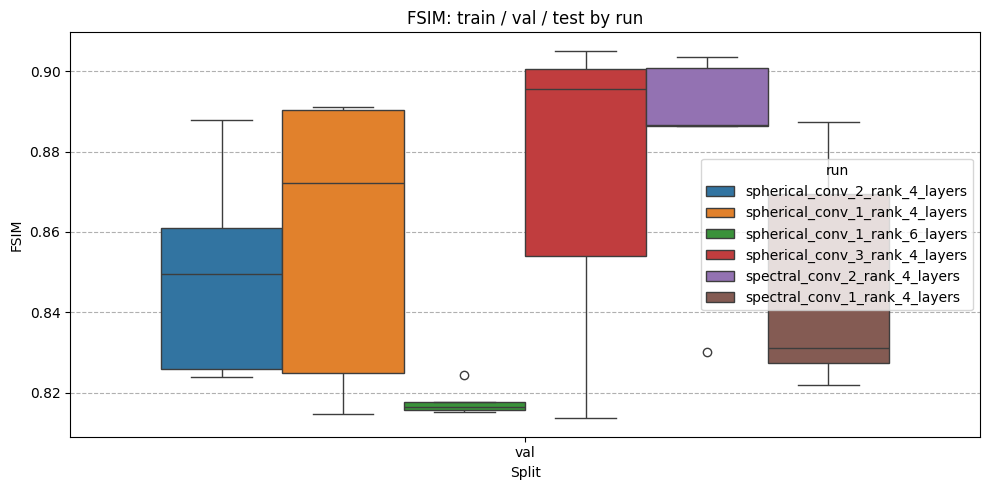

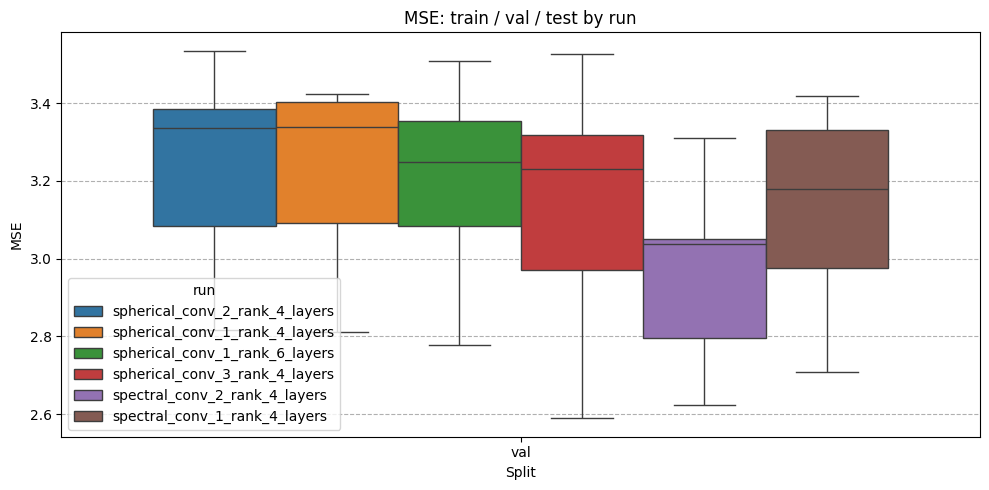

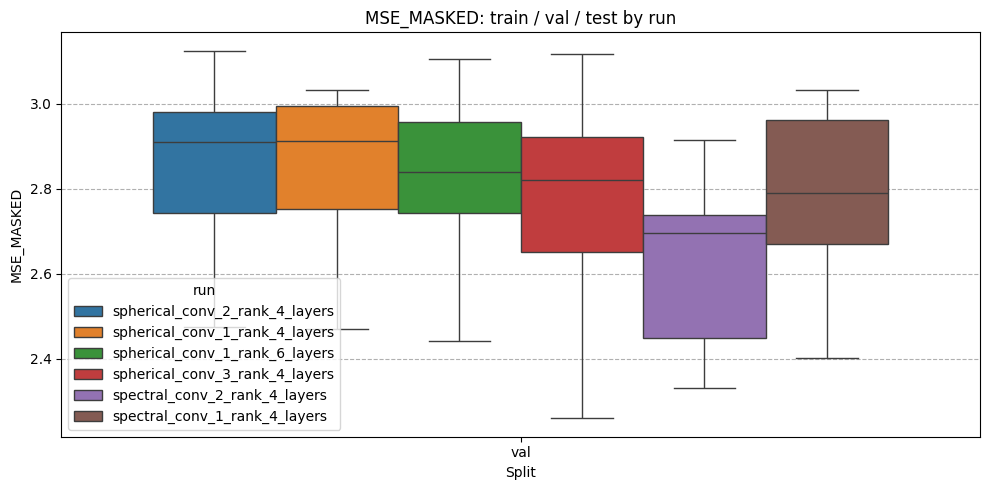

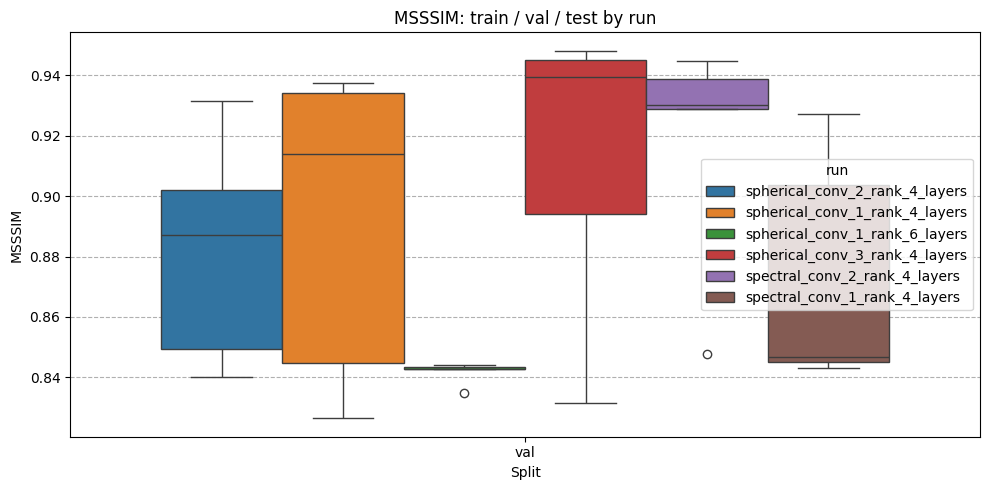

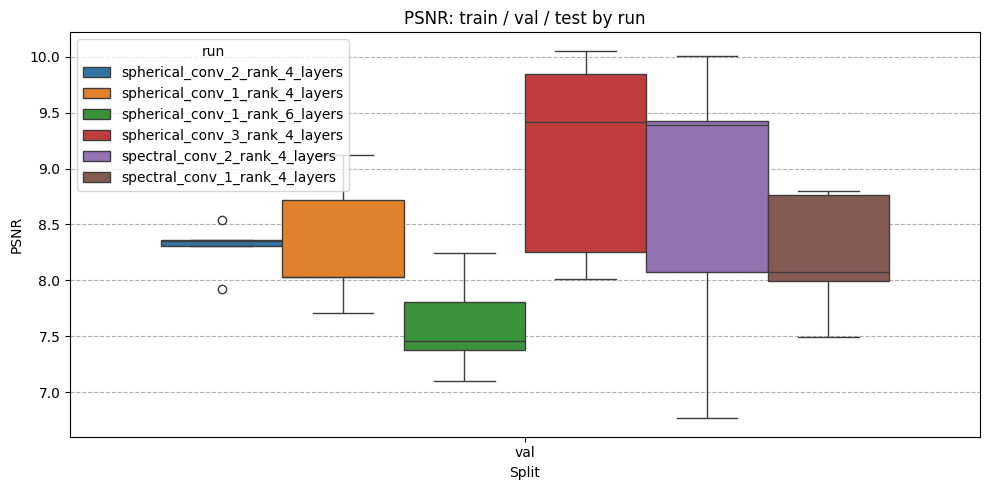

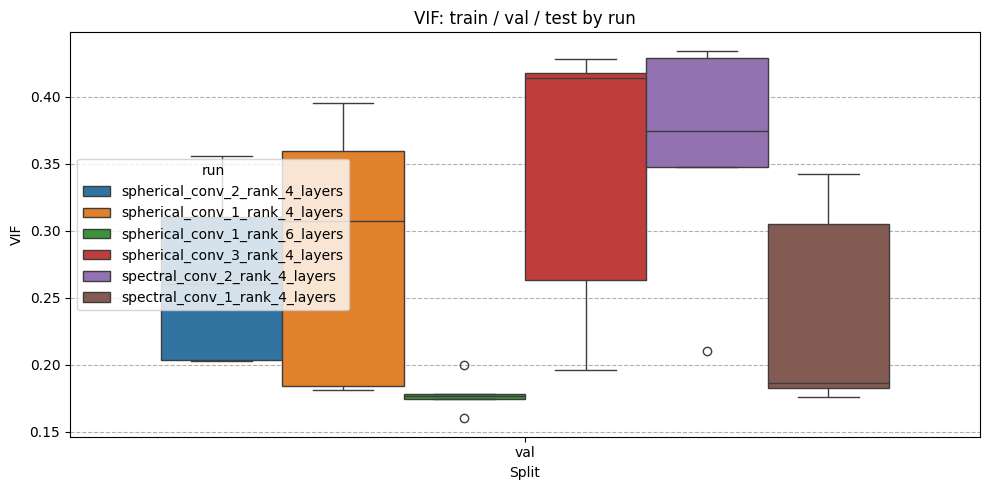

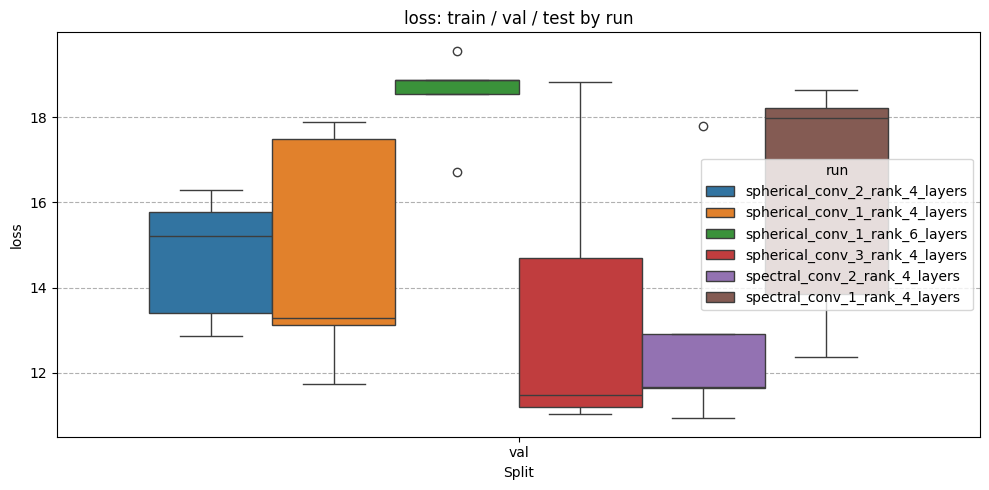

In [230]:
for base_metric in base_metrics:
    plt.figure(figsize=(10, 5))
    
    data = scalar_df[scalar_df["base_metric"] == base_metric]
    
    sns.boxplot(
        data=data,
        x="split",
        y="value",
        hue="run",
        order=["val"]
    )
    plt.title(f"{base_metric}: train / val / test by run")
    plt.xlabel("Split")
    plt.ylabel(base_metric)
    plt.grid(axis='y', linestyle='--')
    plt.tight_layout()
    plt.savefig(os.path.join('cv_result_plots', f'iqa_metrics_{base_metric}.png'), dpi=200)
    plt.show()

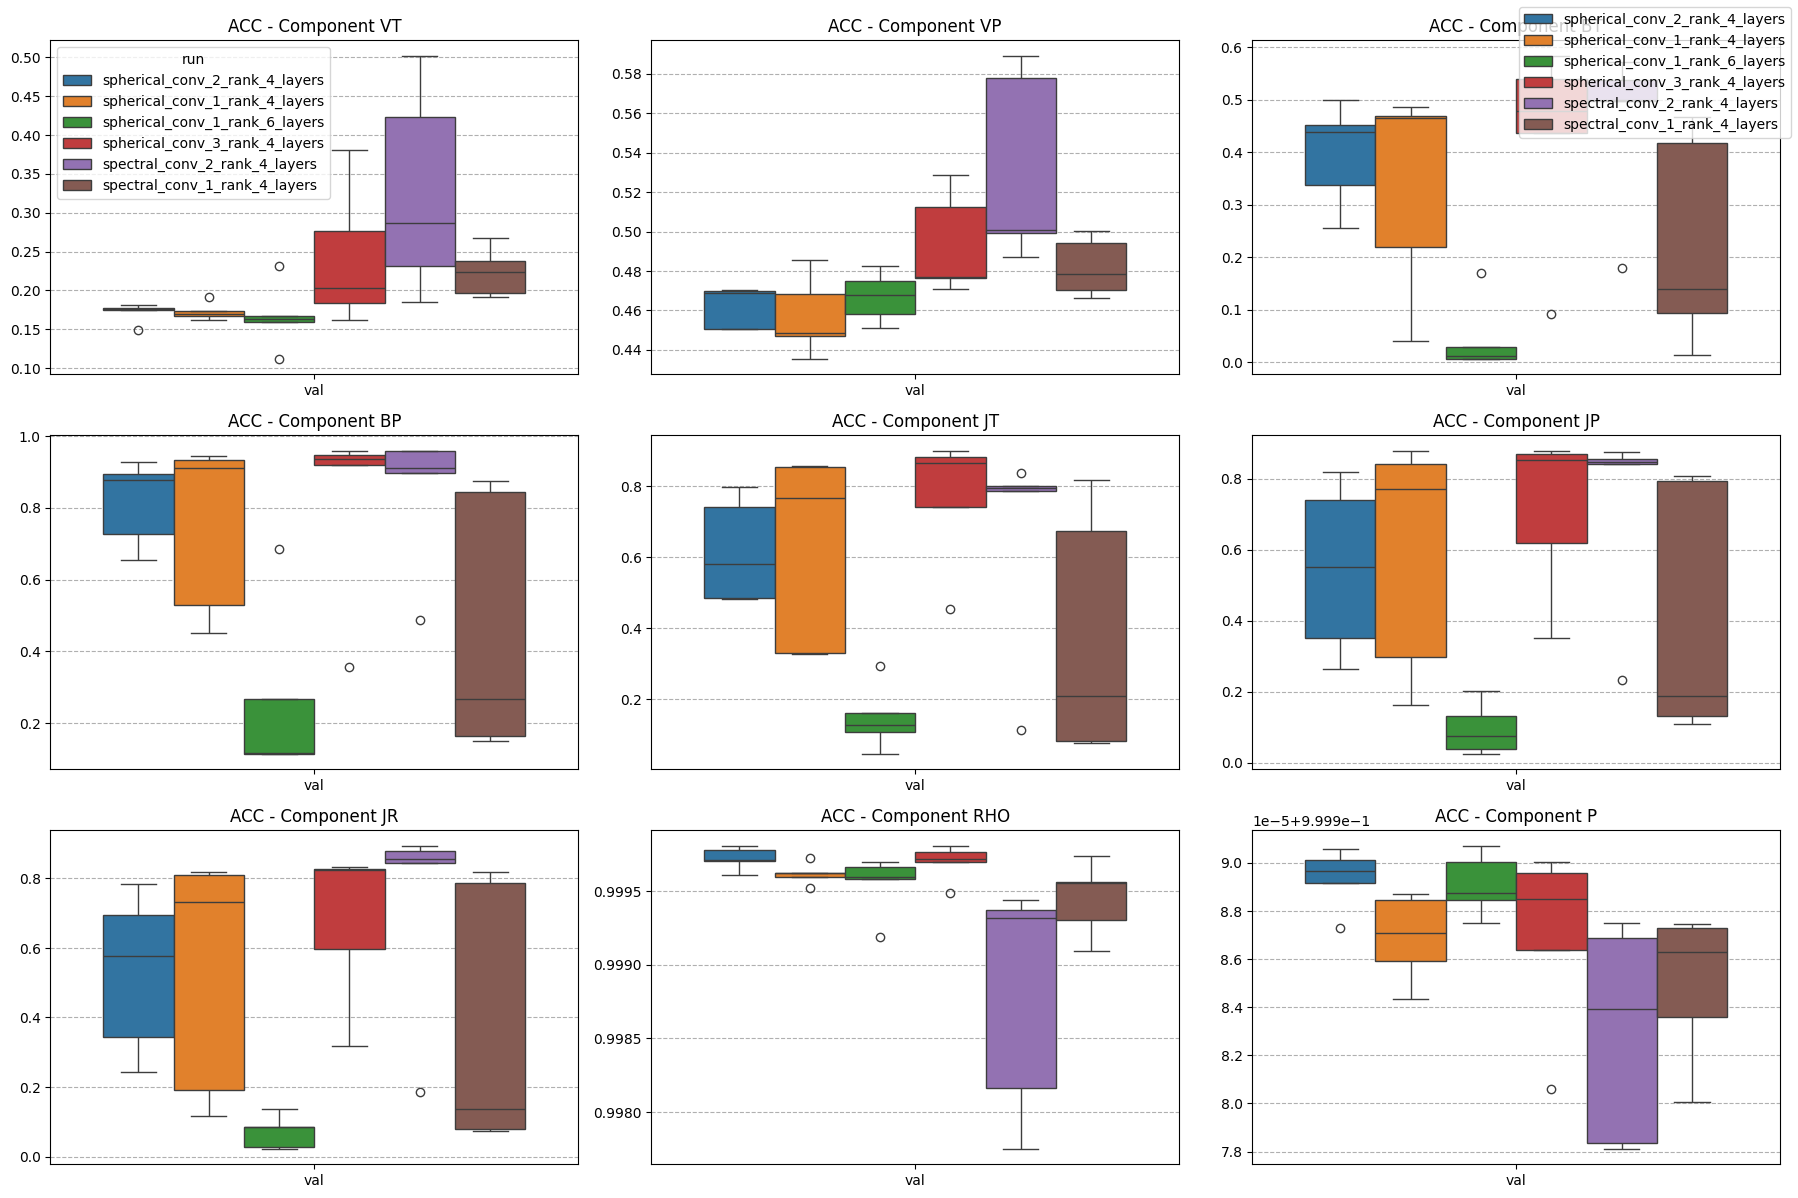

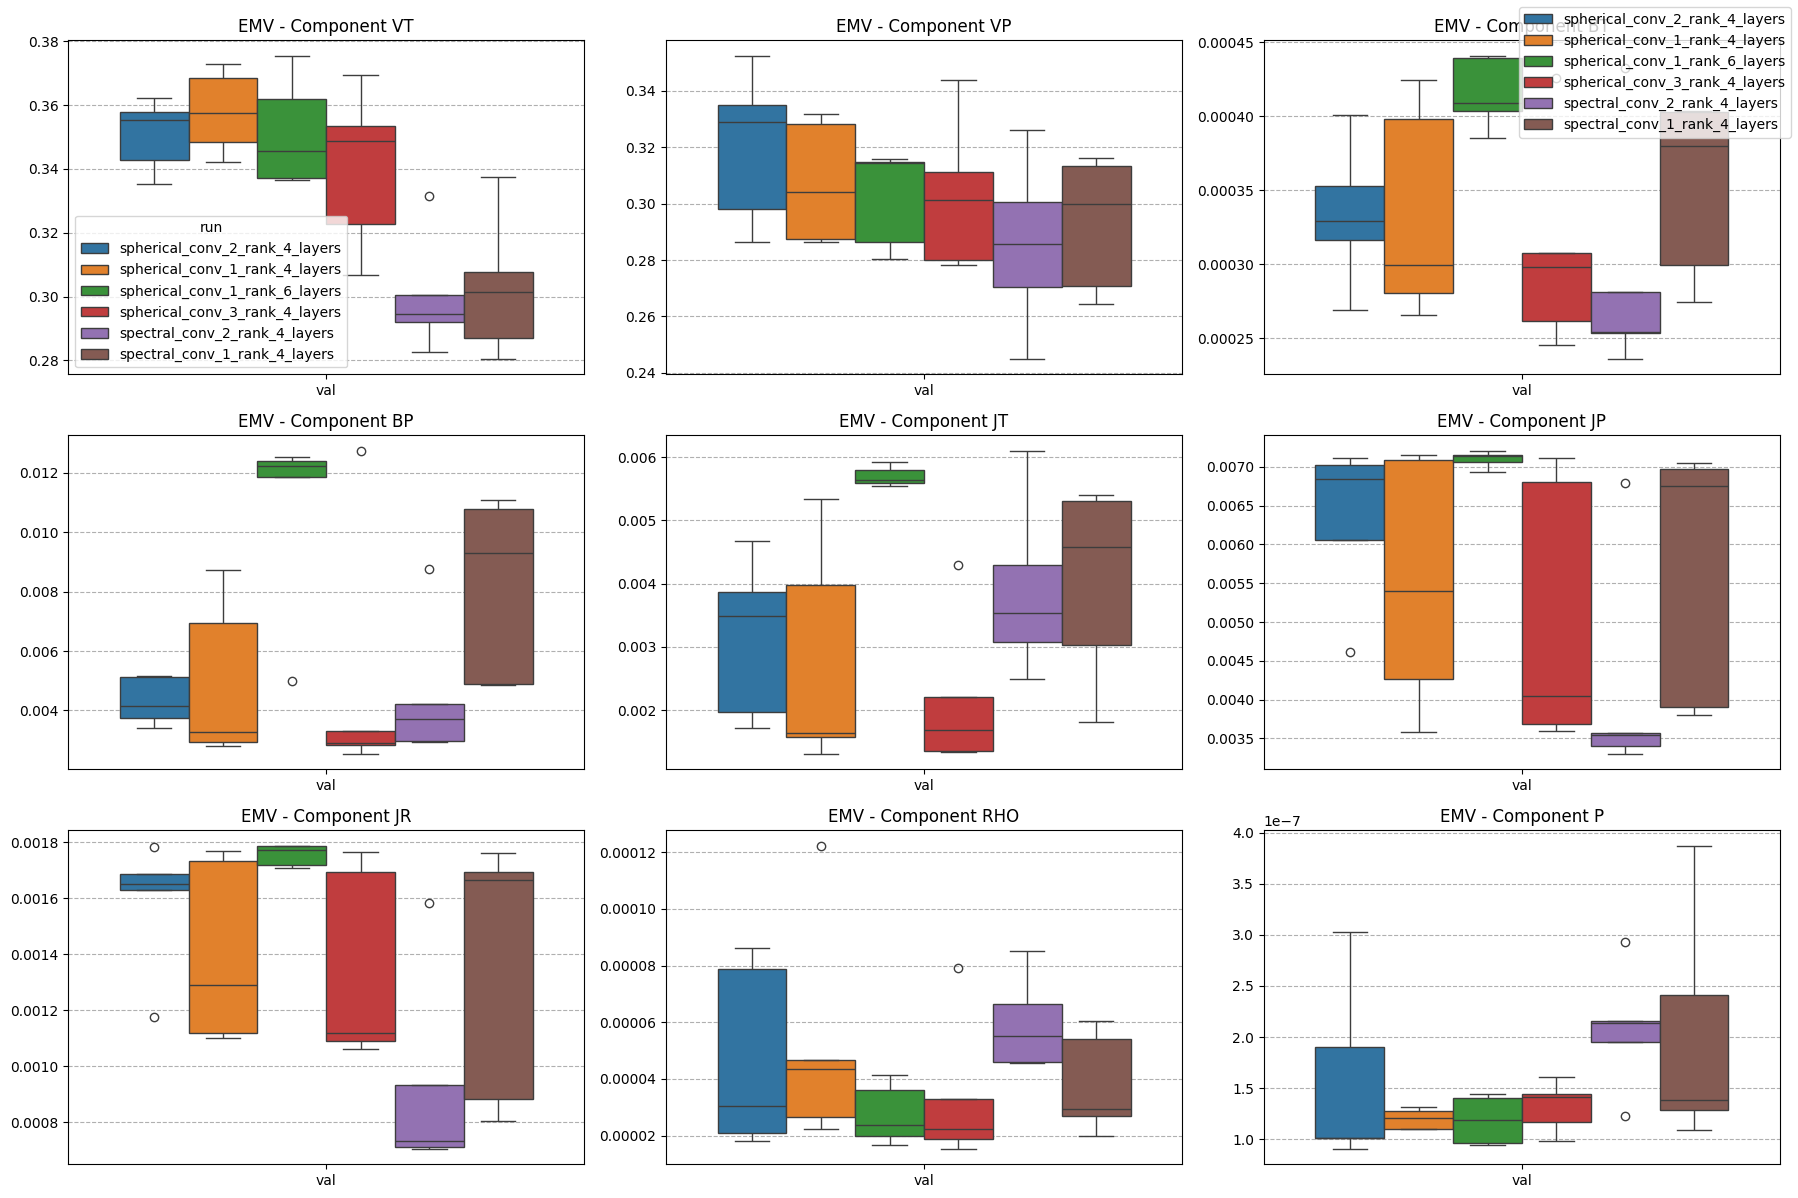

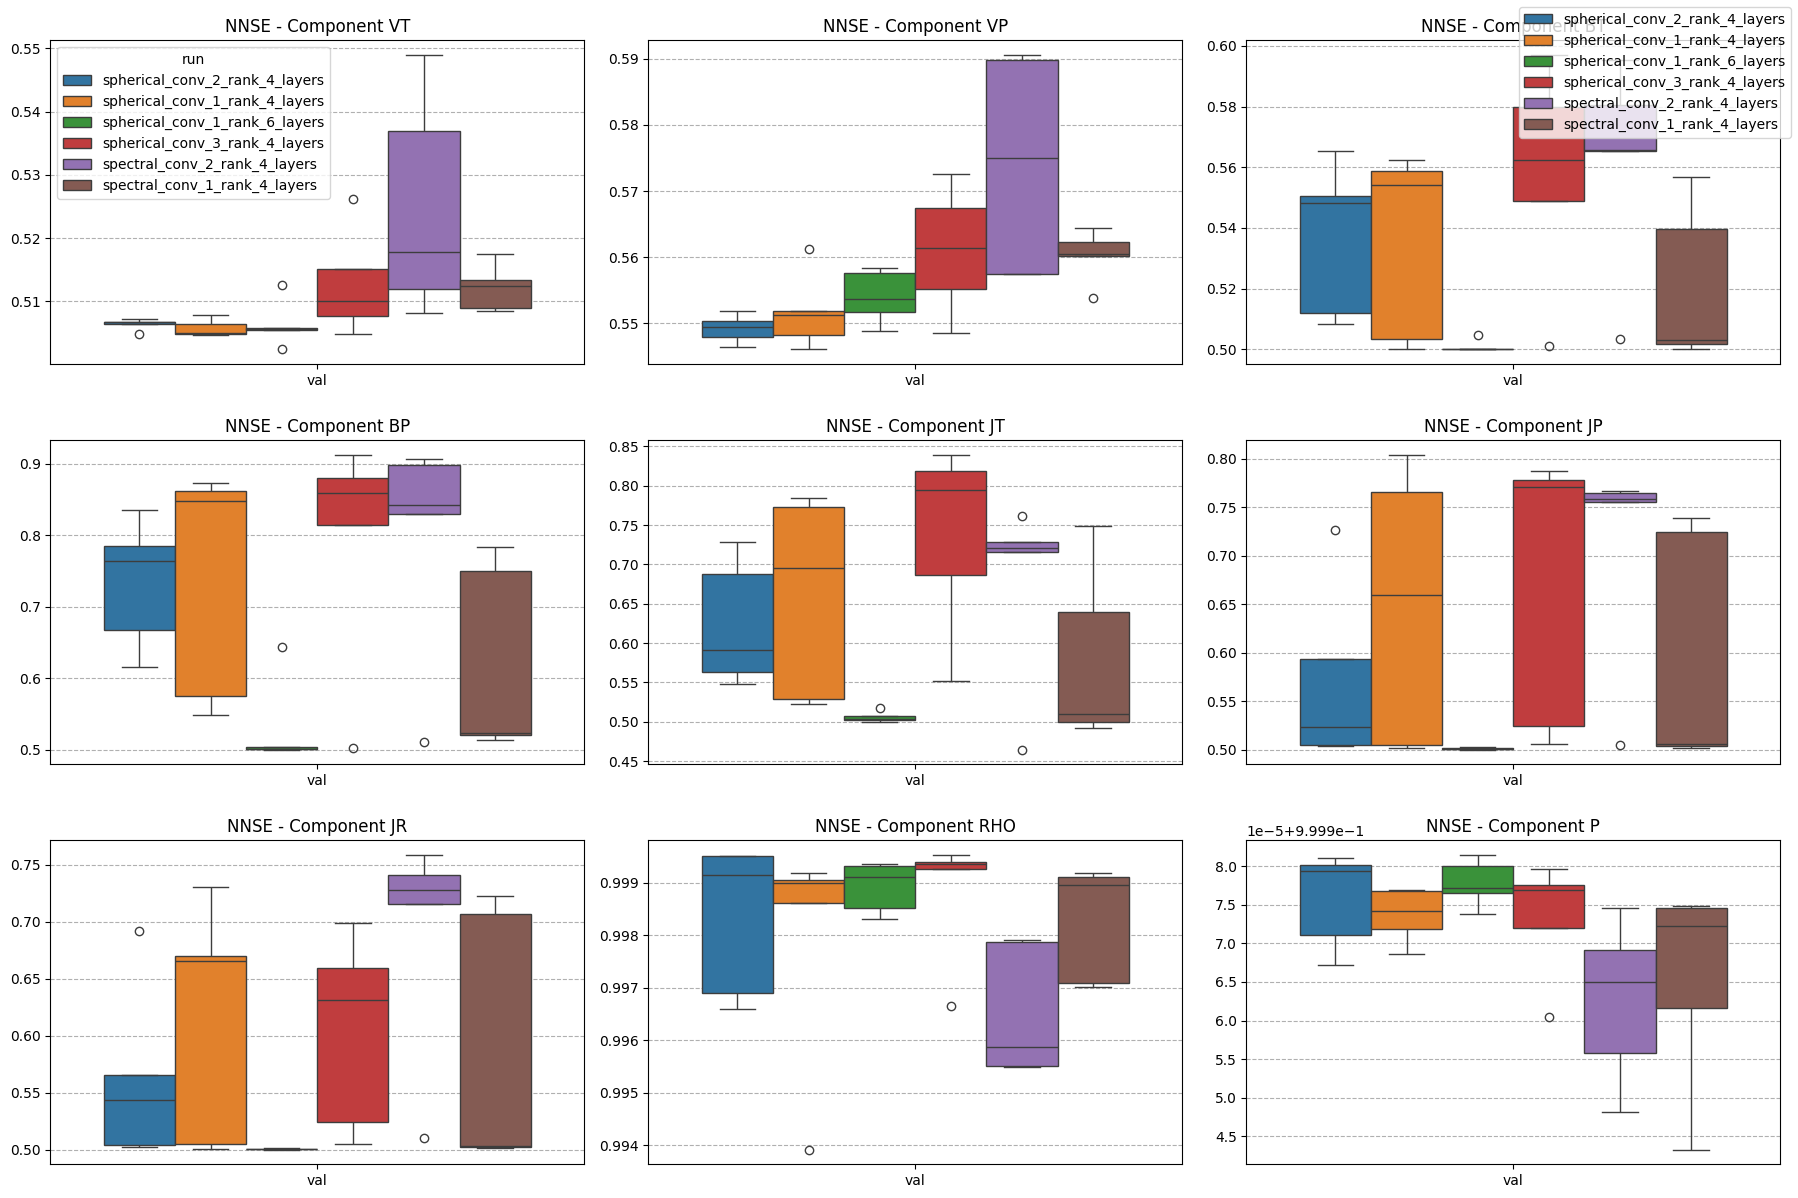

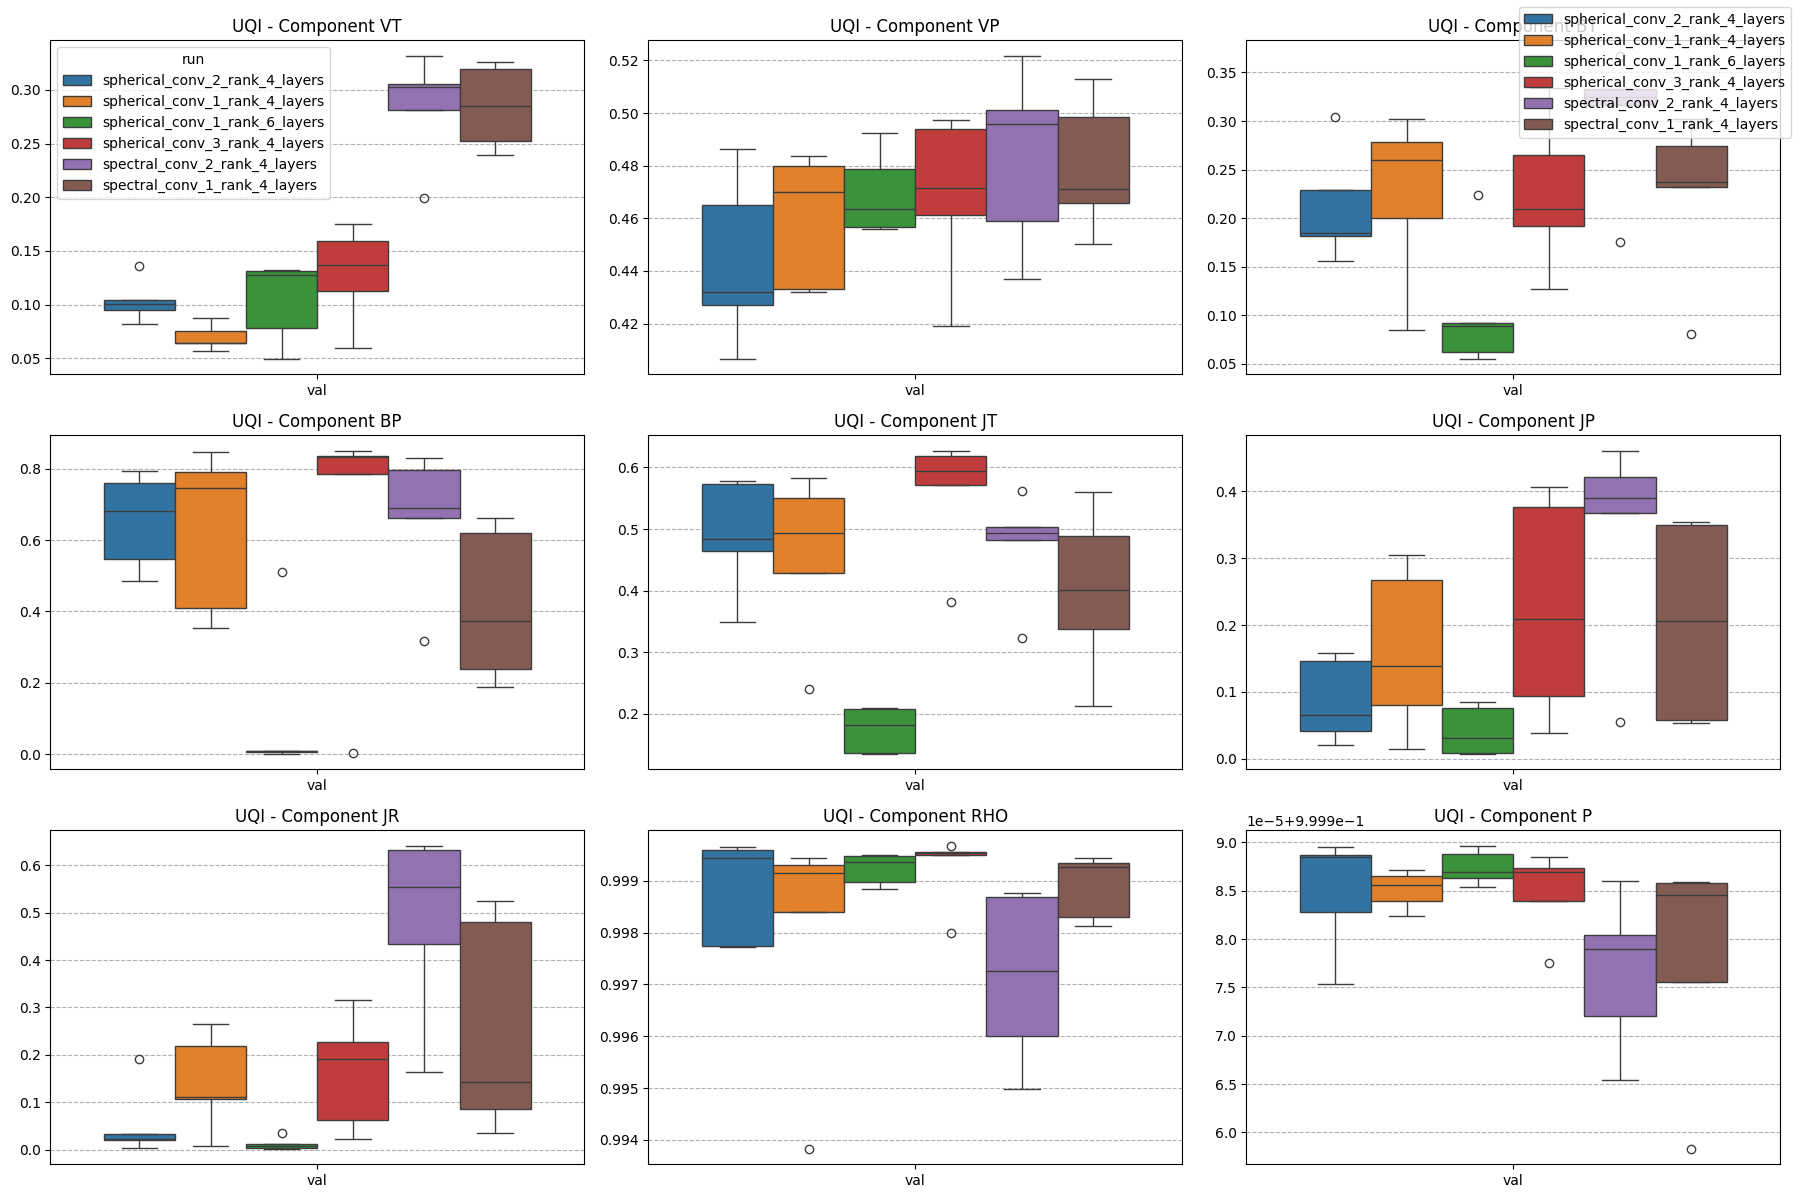

In [229]:
vector_base_metrics = sorted(vector_df["base_metric"].unique())
for base_metric in vector_base_metrics:
    fig, axes = plt.subplots(3, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    data_metric = vector_df[vector_df["base_metric"] == base_metric]
    
    for comp in range(9):
        ax = axes[comp]
        comp_data = data_metric[data_metric["component"] == comp]
        
        sns.boxplot(
            data=comp_data,
            x="split",
            y="value",
            hue="run",
            order=["val"],
            ax=ax
        )
        ax.grid(axis='y', linestyle='--')
        ax.set_title(f"{base_metric} - Component {component_list[comp].upper()}")
        ax.set_xlabel("")
        ax.set_ylabel("")
        
        if comp != 0:
            legend = ax.get_legend()
            if legend is not None:
                legend.remove()
    
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right")
    
    plt.tight_layout()
    plt.savefig(os.path.join('cv_result_plots', f'component_metrics_{base_metric}.png'), dpi=200)
    plt.show()

,run,metric,fold,value,split,base_metric
0,spherical_conv_2_rank_4_layers,train_loss,0,14.301285,train,loss
1,spherical_conv_2_rank_4_layers,train_loss,1,16.697836,train,loss
2,spherical_conv_2_rank_4_layers,train_loss,2,15.121233,train,loss
3,spherical_conv_2_rank_4_layers,train_loss,3,17.078101,train,loss
4,spherical_conv_2_rank_4_layers,train_loss,4,15.644854,train,loss
...,...,...,...,...,...,...
205,spherical_conv_1_rank_4_layers,test_FSIM,0,0.861946,test,FSIM
206,spherical_conv_1_rank_4_layers,test_FSIM,1,0.830273,test,FSIM
207,spherical_conv_1_rank_4_layers,test_FSIM,2,0.866770,test,FSIM
208,spherical_conv_1_rank_4_layers,test_FSIM,3,0.846290,test,FSIM


In [10]:
PER_SAMPLE_PER_COMPONENT_METRICS = ['MSE','PSNR','UQI', 'NNSE', 'EMV', 'ACC']
job_id = '2026_04_01__064736'
f = np.load(os.path.join(BASE_DIR, job_id,'test_best_epoch_per_sample_per_component.npz'))
print(f.keys())

KeysView(NpzFile '/data/solar_wind_pred_vignesh/ParamNetwork_Paper/2026_04_01__064736/test_best_epoch_per_sample_per_component.npz' with keys: MSE, PSNR, UQI, NNSE, EMV...)


SyntaxError: invalid decimal literal (2917446136.py, line 1)

In [260]:
job_id_descriptors = {
    '2026_04_02__060607': {'rank': 0.2,},
    '2026_04_01__064736': {'rank': 0.3,},
    '2026_04_01__065102': {'rank': 0.4},
    '2026_04_04__190917': {'rank': 0.5},
    '2026_04_02__054316': {'rank':1},
}


In [264]:
for job in job_id_descriptors.keys():
    f = np.load(os.path.join(BASE_DIR, job,'test_best_epoch_per_sample_per_component.npz'))
    for metric in PER_SAMPLE_PER_COMPONENT_METRICS:
        job_id_descriptors[job][metric] = f[metric]

In [262]:
job_id_descriptors['2026_04_01__064736']['PSNR'].shape

(95, 9)

In [266]:
result_rows = []

for run_name, run_data in job_id_descriptors.items():
    for metric in PER_SAMPLE_PER_COMPONENT_METRICS:
        metric_values = run_data[metric]
        row_dict = {}
        for idx, val in enumerate(metric_values):
            row_dict = {component_list[comp]: v for comp, v in enumerate(val)}
            row_dict['rank'] = run_data["rank"]
            row_dict['job'] = run_name
            row_dict['metric'] = metric
            
            result_rows.append(row_dict)

# summary_df.head()
            

result_df = pd.DataFrame(result_rows)
print(result_df.shape)
result_df.head(n=10)


(2850, 12)


,vt,vp,bt,bp,jt,jp,jr,rho,p,rank,job,metric
0,0.054055,0.026004,1.485598e-07,2.725089e-06,2.547773e-06,9.146729e-06,8.916526e-07,6.398916e-10,5.695843e-14,0.2,2026_04_02__060607,MSE
1,0.015707,0.009090,2.252709e-08,3.635875e-07,4.910224e-07,2.243378e-06,1.609849e-07,1.468190e-10,1.666978e-14,0.2,2026_04_02__060607,MSE
2,0.007768,0.007505,2.996154e-09,3.450263e-07,3.183433e-07,1.896152e-06,1.047145e-07,1.545100e-10,1.744864e-14,0.2,2026_04_02__060607,MSE
3,0.008125,0.004019,6.797953e-10,2.486764e-07,2.107510e-07,9.389597e-07,7.233726e-08,1.122536e-10,3.395686e-14,0.2,2026_04_02__060607,MSE
4,0.014246,0.009365,2.454294e-08,4.504741e-07,5.616986e-07,2.338630e-06,1.603790e-07,1.802244e-10,1.205619e-14,0.2,2026_04_02__060607,MSE
5,0.029825,0.023348,7.486749e-08,7.332715e-07,8.648771e-07,4.004773e-06,4.944892e-07,2.154612e-10,1.524224e-14,0.2,2026_04_02__060607,MSE
6,0.026160,0.038561,4.448477e-08,9.097407e-07,7.180130e-07,2.774001e-06,2.844816e-07,1.521903e-10,1.244228e-14,0.2,2026_04_02__060607,MSE
7,0.030498,0.038325,1.404348e-07,5.930603e-06,2.407802e-05,4.986374e-06,9.712985e-07,7.443496e-10,4.455813e-14,0.2,2026_04_02__060607,MSE
8,0.014090,0.021241,1.091944e-08,8.036199e-07,1.999823e-06,3.933675e-06,2.730799e-07,2.721545e-10,2.632425e-14,0.2,2026_04_02__060607,MSE
9,0.008321,0.023539,5.056947e-09,8.127179e-07,2.564550e-06,2.216602e-06,2.323886e-07,3.267755e-10,3.446471e-14,0.2,2026_04_02__060607,MSE


In [267]:
component_list = ["vt", "vp", "bt", "bp", "jt", "jp", "jr", "rho", "p"]

long_df = result_df.melt(
    id_vars=["metric", "rank"],
    value_vars=component_list,
    var_name="component",
    value_name="value"
)

rank_metric_summary = (
    long_df
    .groupby(["rank", "metric"])["value"]
    .agg(["mean", "std"])
    .unstack("metric")
)

rank_metric_summary = (
    rank_metric_summary
    .swaplevel(0, 1, axis=1)
    .sort_index(axis=1)
)

rank_metric_summary

metric       ACC                 EMV                 MSE                NNSE  \
            mean       std      mean       std      mean       std      mean   
rank                                                                           
0.2     0.983386  0.023973  0.009700  0.019338  0.006928  0.019134  0.967823   
0.3     0.983062  0.025483  0.009479  0.020337  0.005788  0.016816  0.967425   
0.4     0.987428  0.020409  0.006050  0.012104  0.003958  0.011354  0.975666   
0.5     0.987429  0.020223  0.006291  0.012742  0.004269  0.012528  0.974725   
1.0     0.978879  0.033660  0.010529  0.021497  0.007795  0.021704  0.960454   

metric                 PSNR                  UQI            
             std       mean        std      mean       std  
rank                                                        
0.2     0.042800  37.337547   9.941524  0.888106  0.110523  
0.3     0.044353  37.585270  10.309579  0.884337  0.114576  
0.4     0.036278  38.688164  10.120058  0.907749  0.092690  
0.5     0.037902  37.989906   9.485469  0.908689  0.091160  
1.0     0.054629  36.996857  11.134190  0.879379  0.120093

In [248]:
# result_df[['metric']].value_counts()
metric_df = result_df[result_df['metric'] == 'PSNR']
metric_df

,vt,vp,bt,bp,jt,jp,jr,rho,p,rank,job,metric
1,32.745121,20.802380,28.565611,37.211937,35.093121,29.200949,27.550344,51.264164,62.606968,0.2,2026_04_02__060607,PSNR
7,34.812126,20.210165,27.486898,40.293240,34.107204,27.891239,27.956480,50.537106,65.304901,0.3,2026_04_01__064736,PSNR
13,37.071774,21.913507,29.901712,38.500797,33.700752,31.477219,30.864441,50.787083,66.330475,0.4,2026_04_01__065102,PSNR
19,37.254807,22.553644,28.118221,38.295780,35.010674,29.539057,29.954912,48.522709,60.271118,0.5,2026_04_04__190917,PSNR
25,32.373322,20.079247,29.369480,38.576733,31.853958,28.569950,25.737335,52.284168,64.188591,1.0,2026_04_02__054316,PSNR


In [282]:
# for metric in PER_SAMPLE_PER_COMPONENT_METRICS:
    # metric_df = result_df[result_df['metric'] == metric]
    # print('='*25, metric, '='*25)
    # print(metric_df.describe())

component_title_dict = {
    'vt':r'$v_{\theta}$',
    'vp':r'$v_{\phi}$',
    'bt':r'$\mathbf{B}_{\theta}$',
    'bp':r'$\mathbf{B}_{\phi}$',
    'jt':r'$\mathbf{J}_{\theta}$',
    'jp':r'$\mathbf{J}_{\phi}$',
    'jr':r'$\mathbf{J}_{r}$'	,
    'rho':r'$\rho$',
    'p': r'p'}

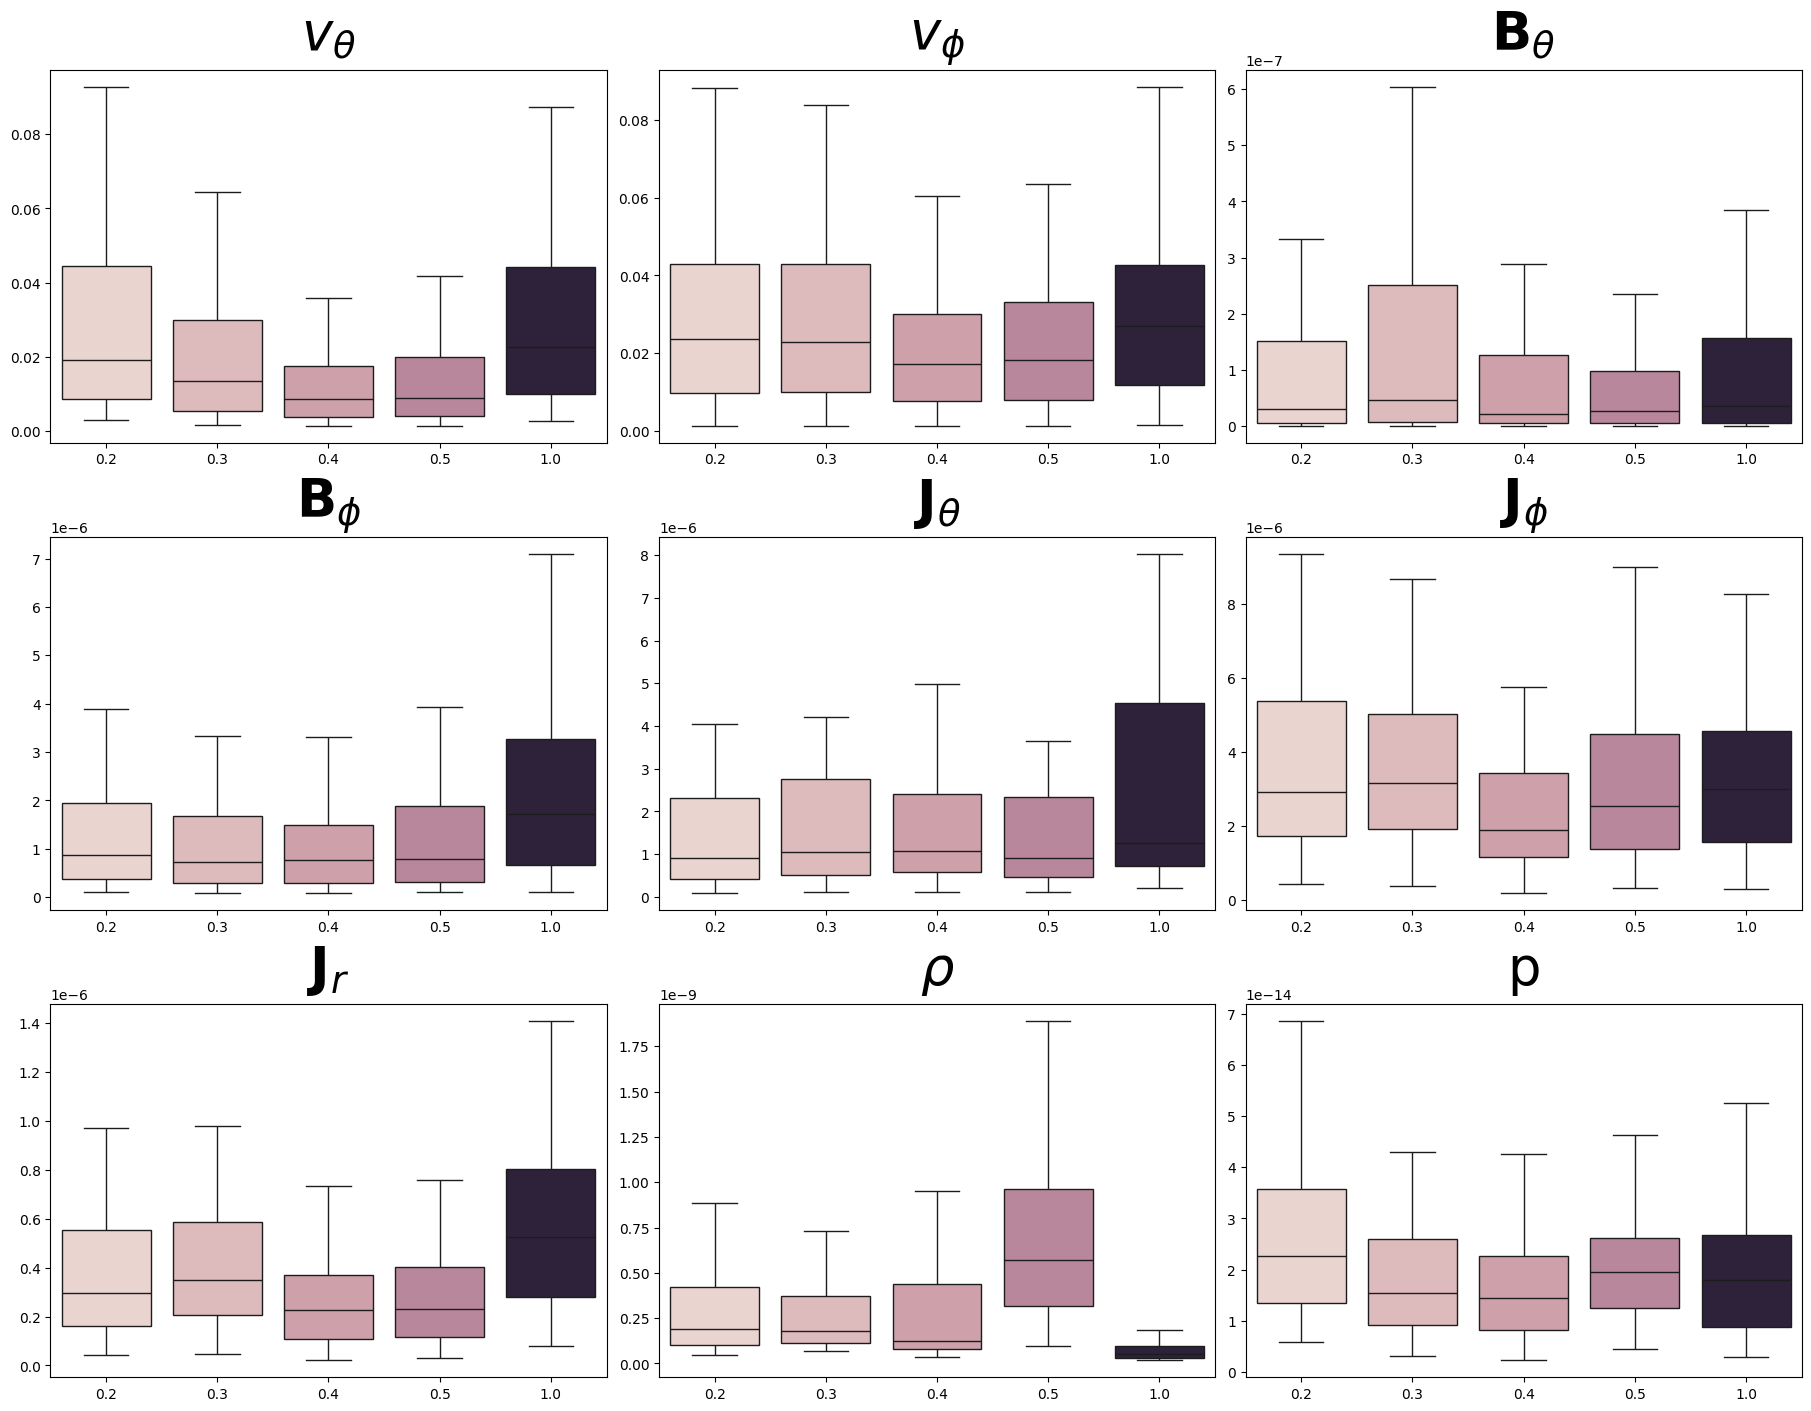

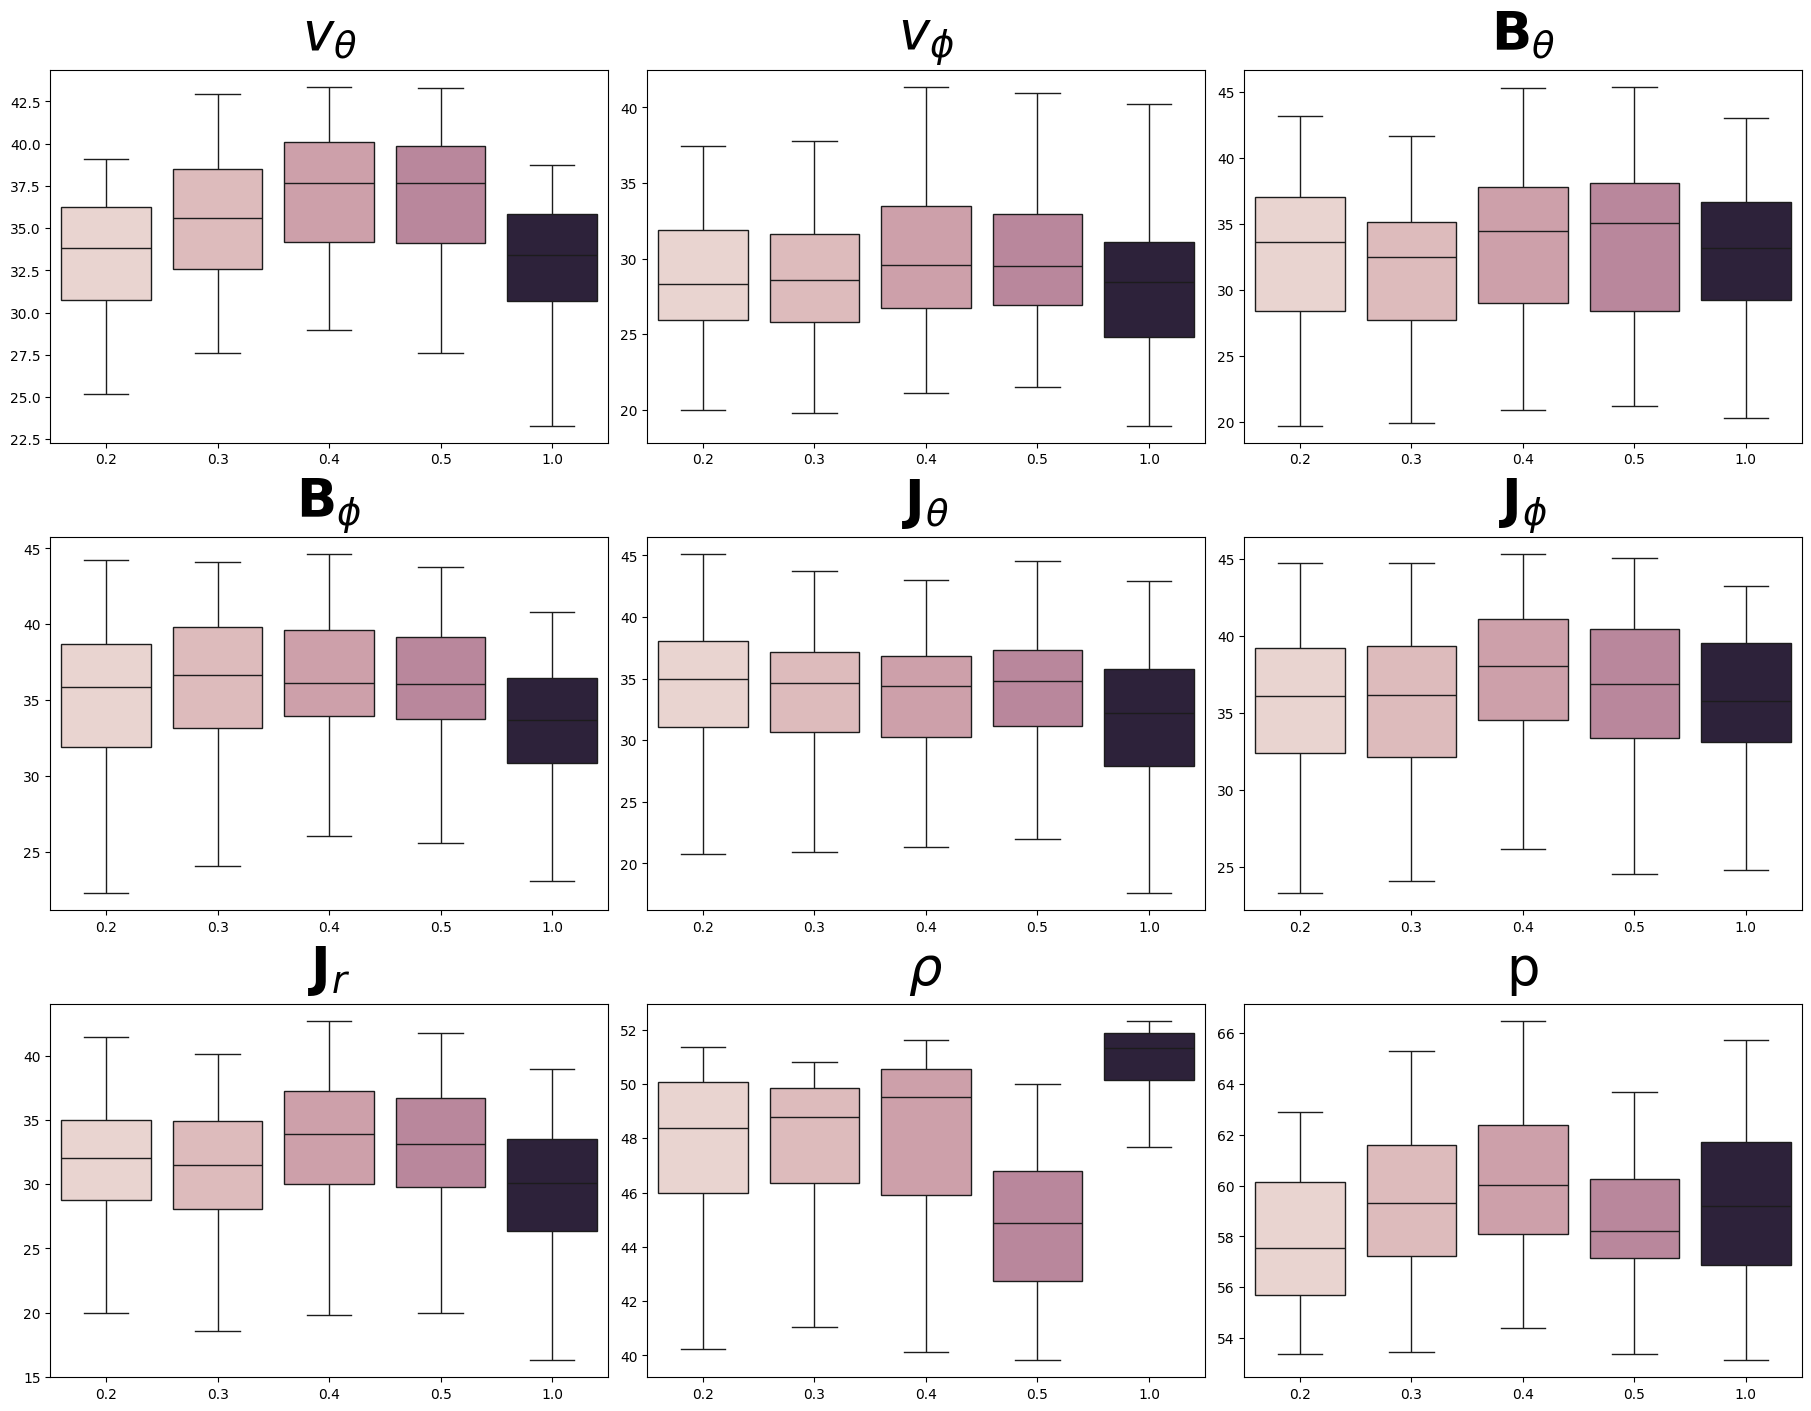

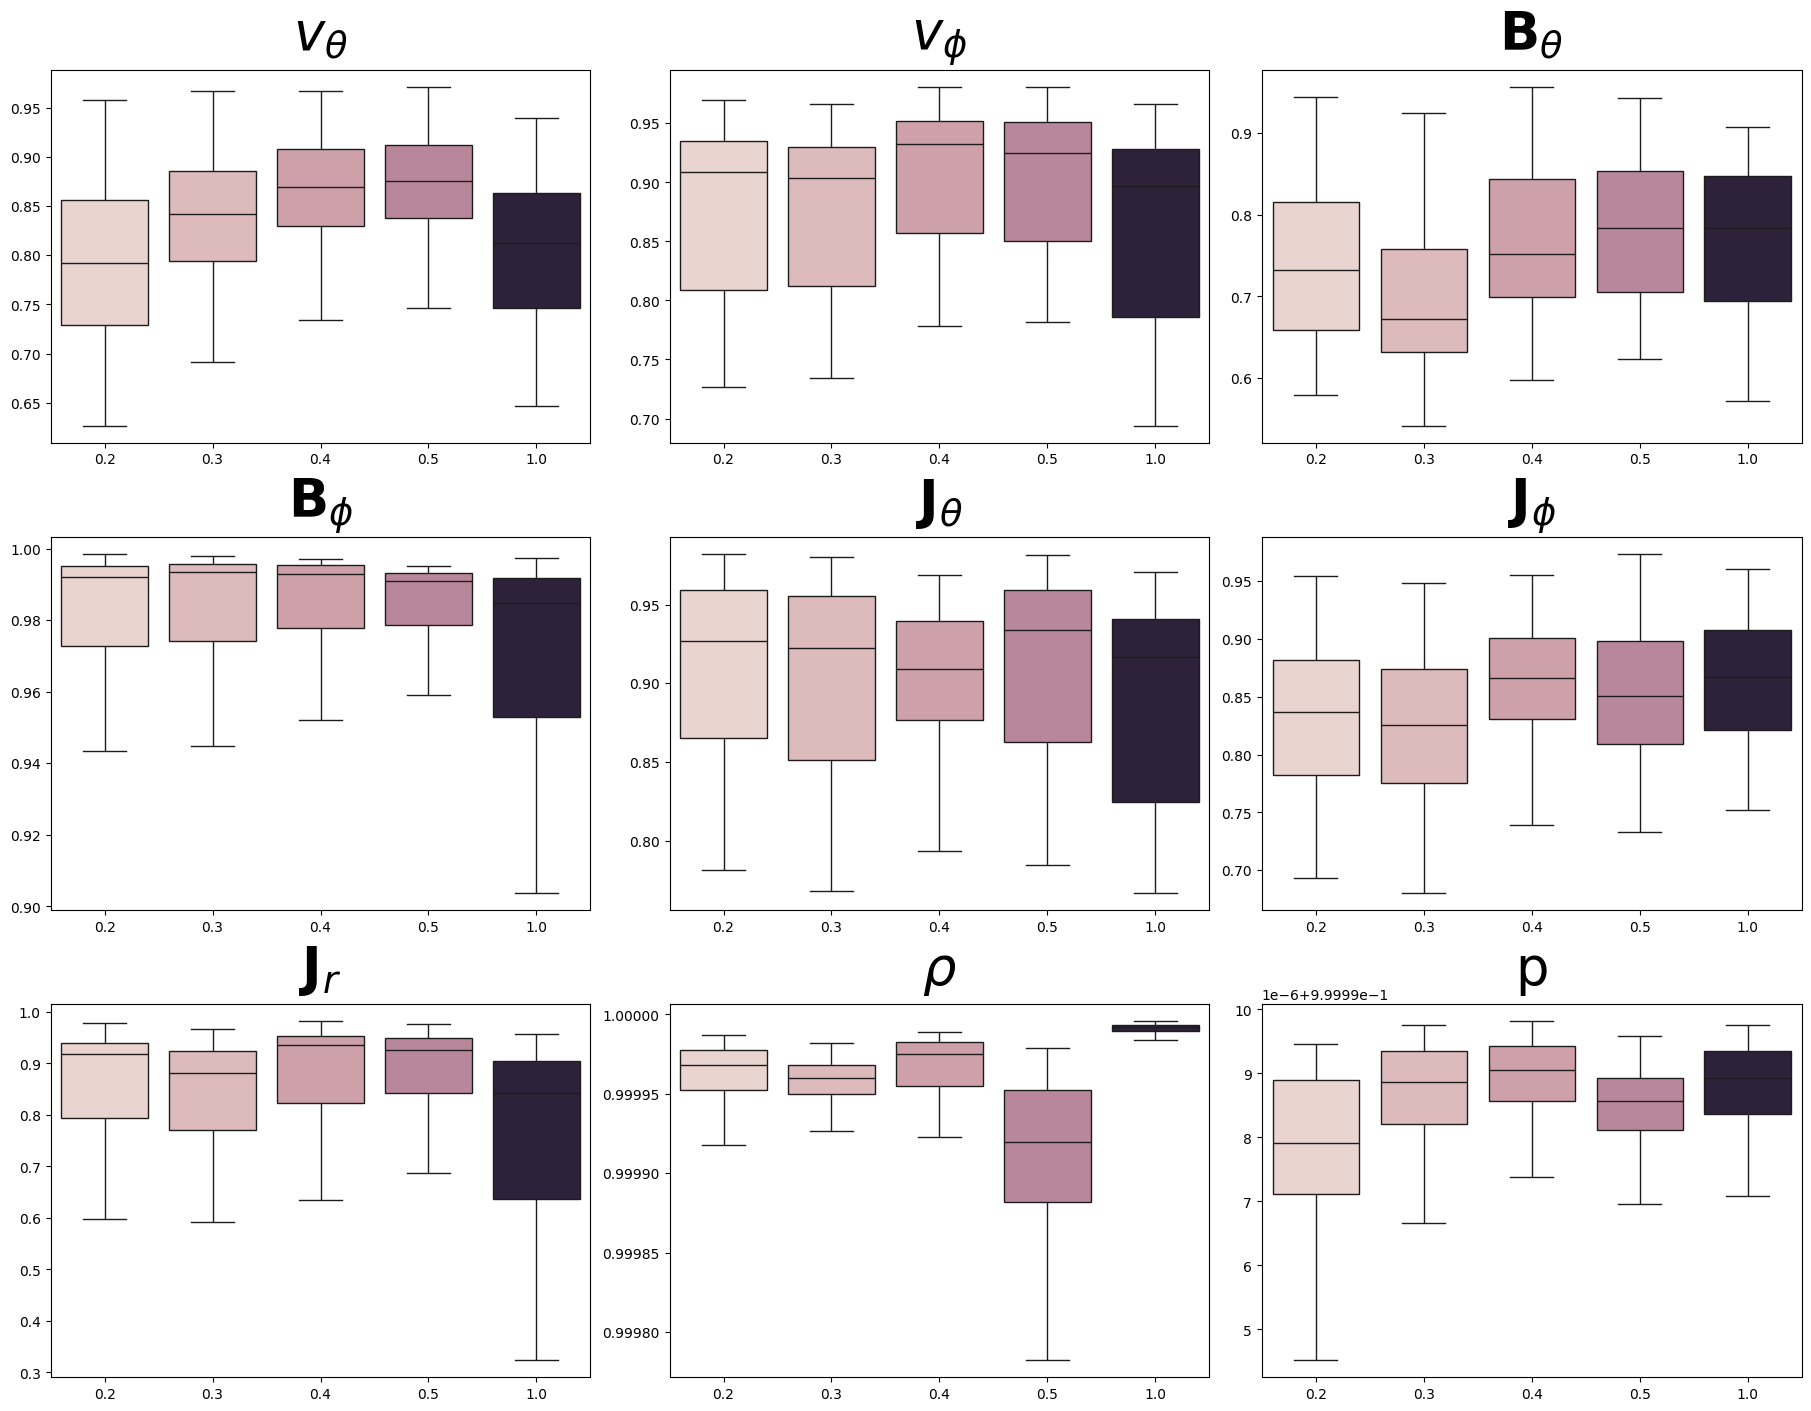

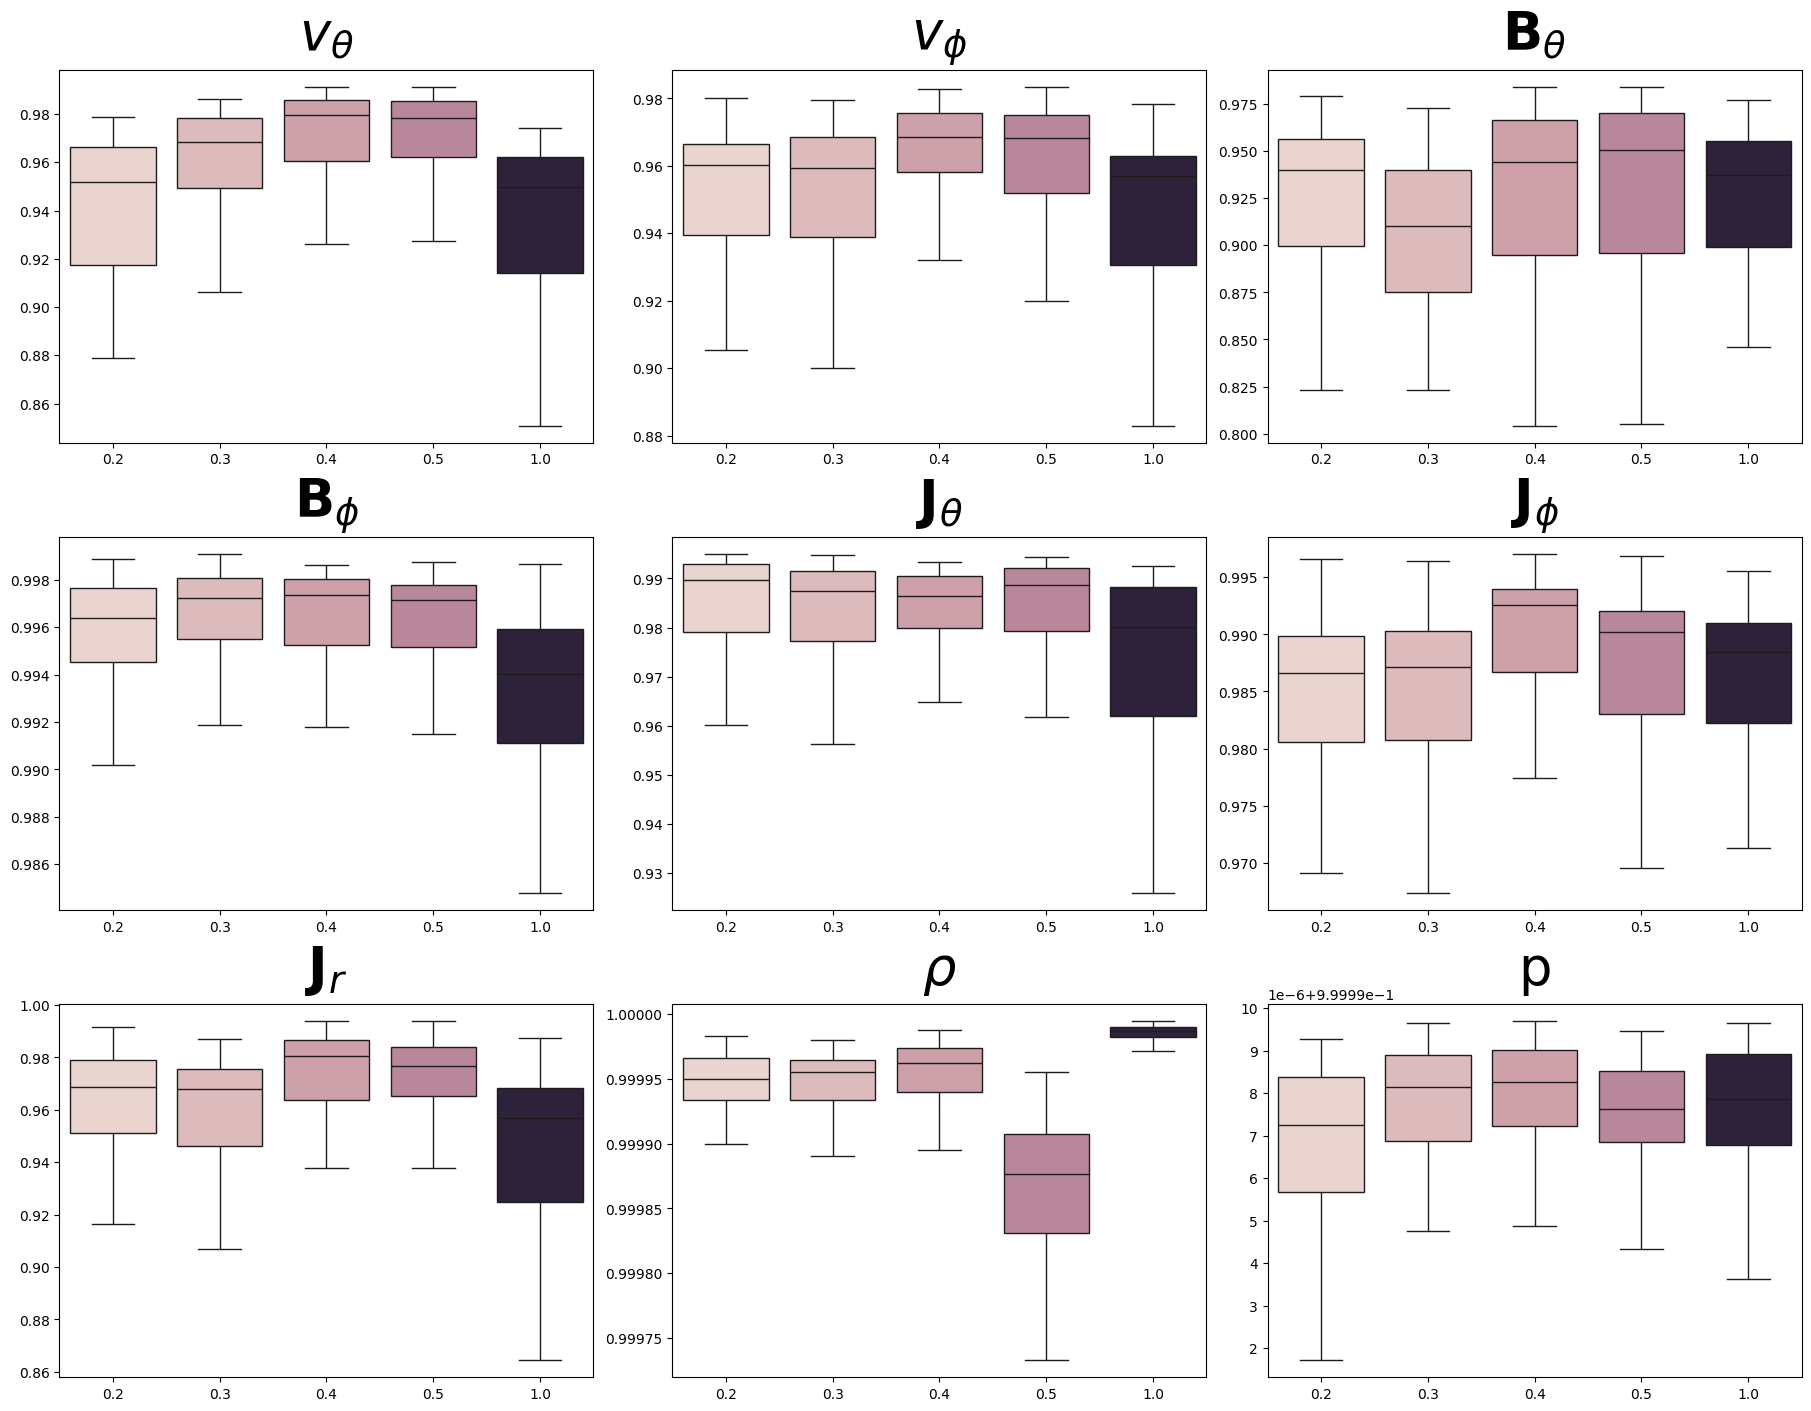

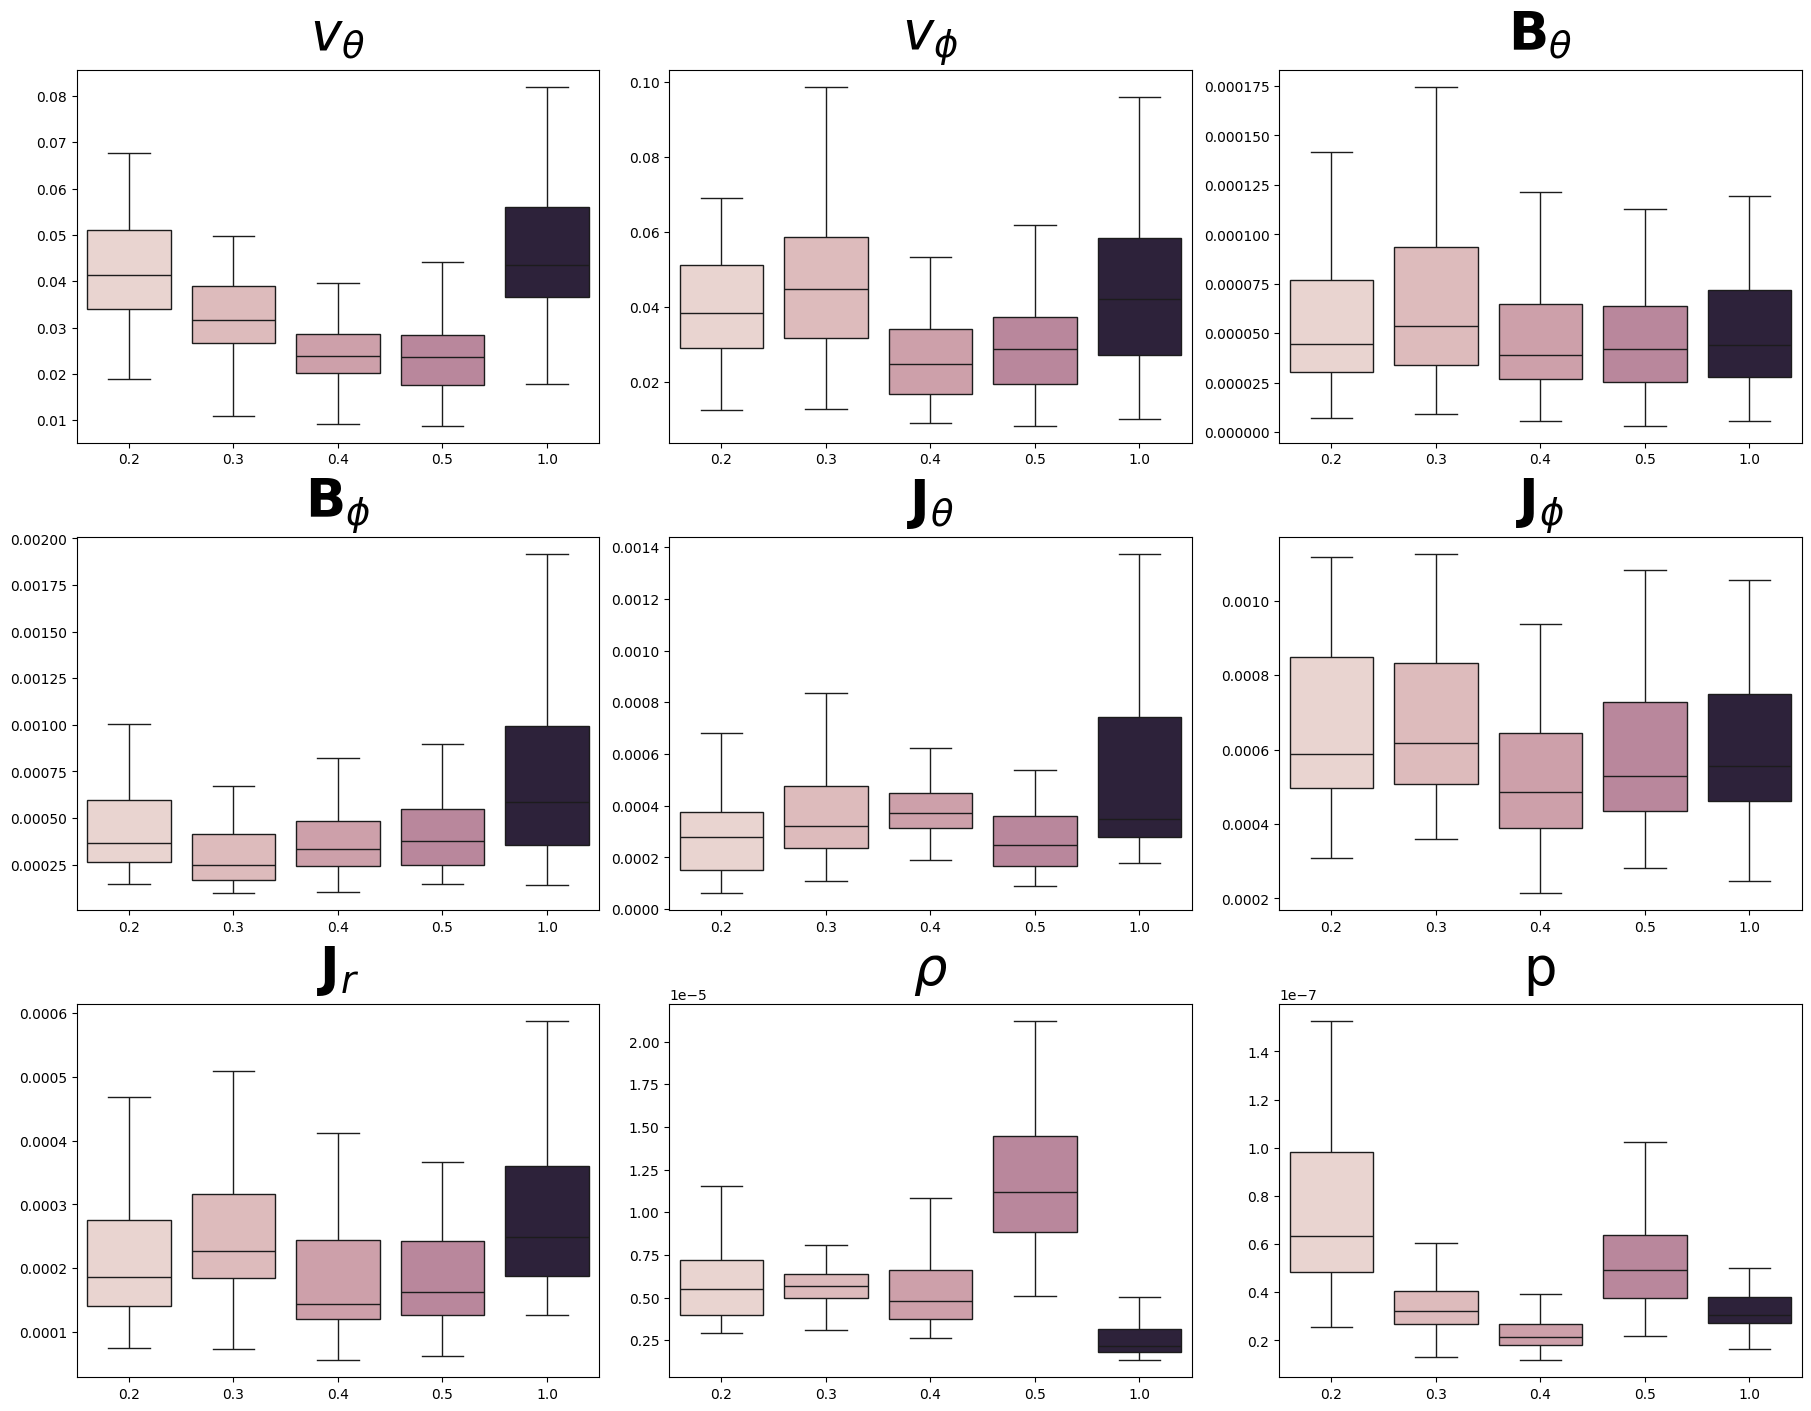

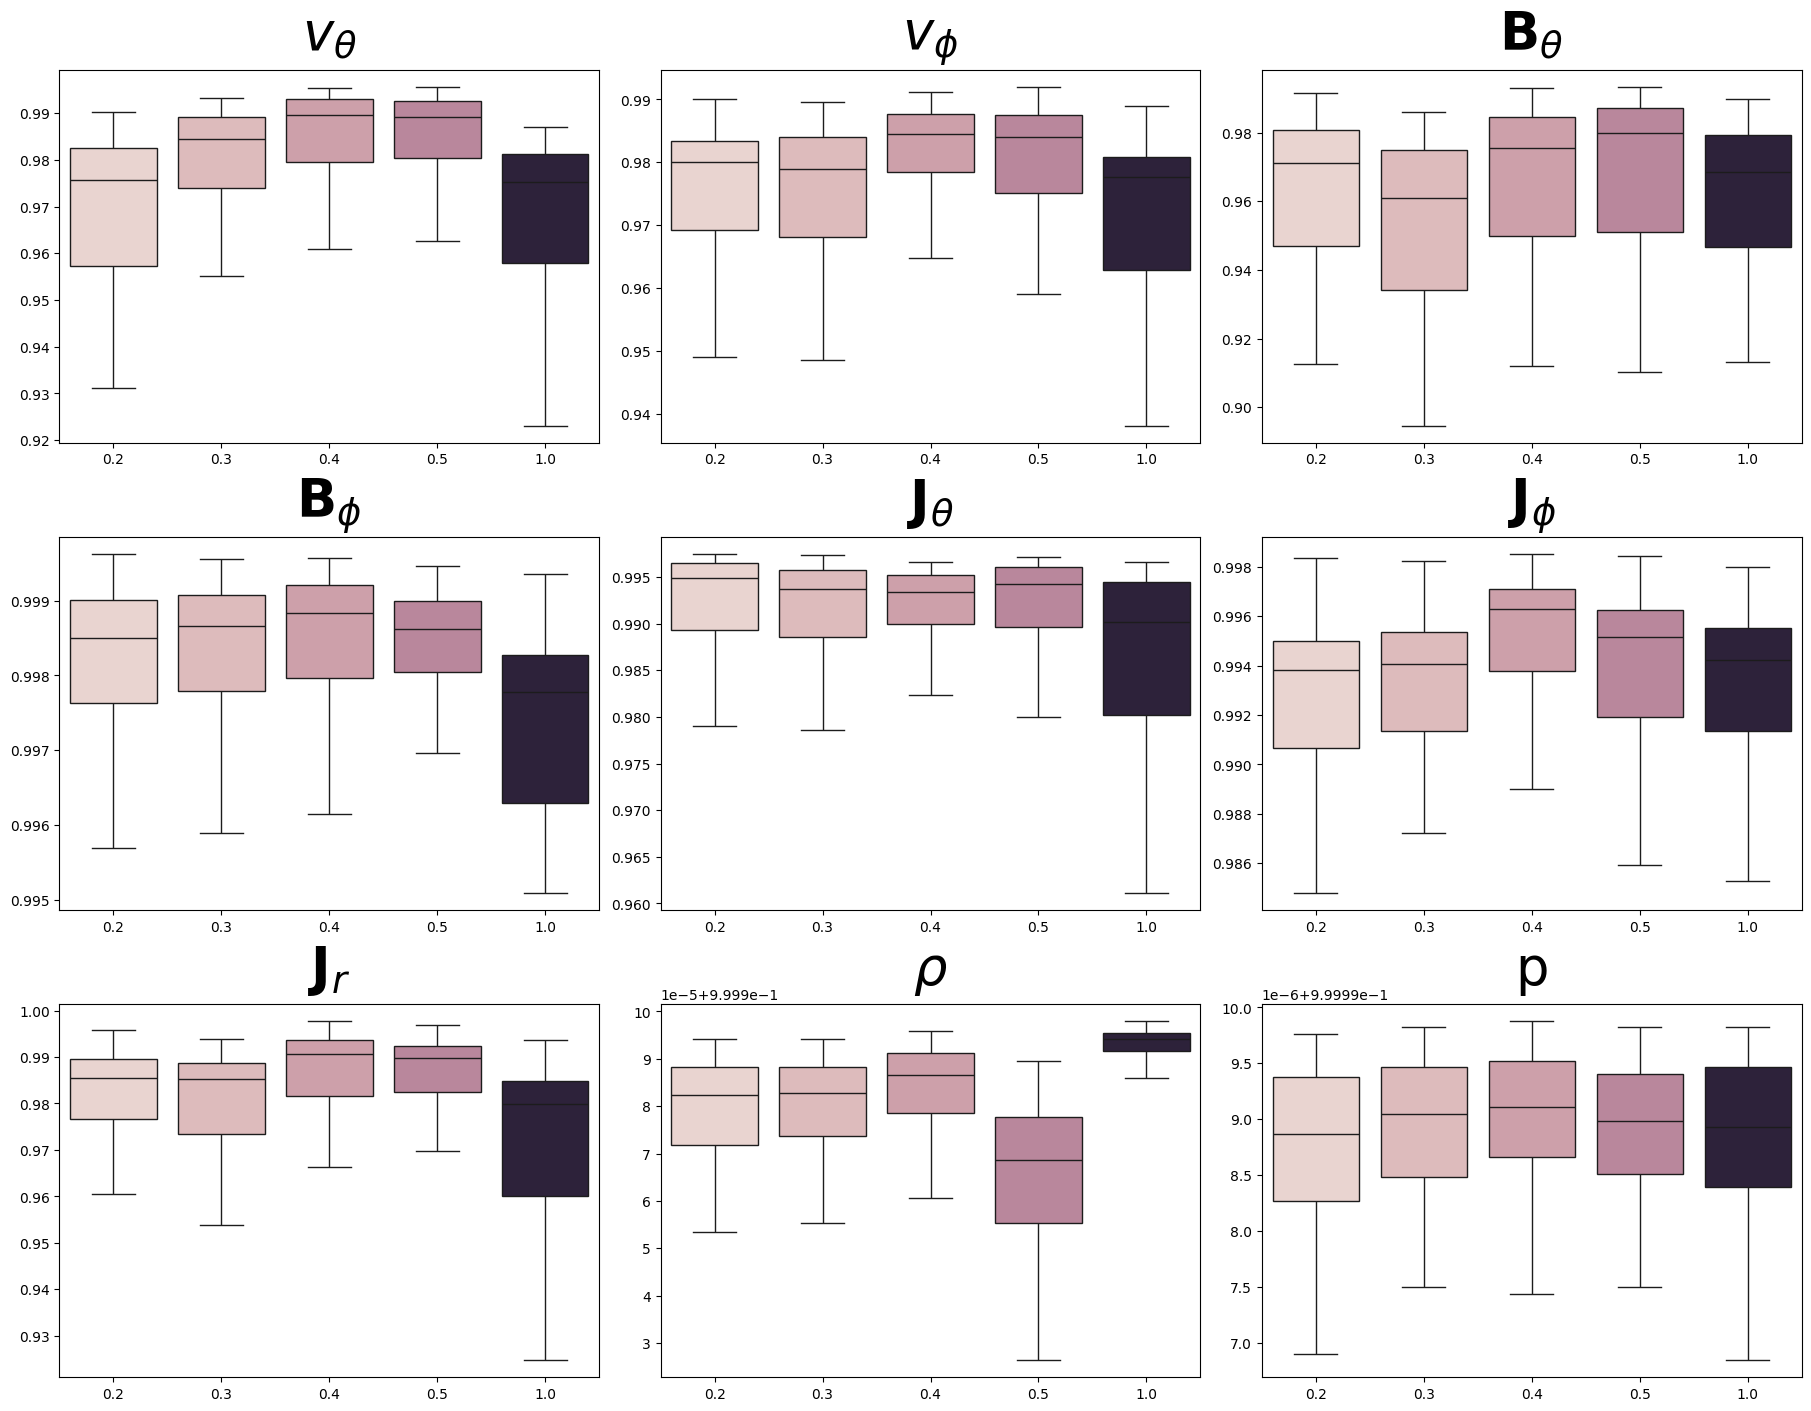

In [324]:

for metric in PER_SAMPLE_PER_COMPONENT_METRICS:
    metric_df = result_df[result_df['metric'] == metric]
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 14), sharey=False, constrained_layout=True)
    axes = axes.flatten()
    
    for i, comp in enumerate(component_list):
        sns.boxplot(
            data=metric_df,
            x="rank",              # distribution per run
            y=comp,               # PSNR values for this component
            hue="rank",           # color by rank
            ax=axes[i],
            showfliers=False,
            # showfliers=True,
        )
        axes[i].set_title(f"{component_title_dict[comp]}", fontsize=38, pad=14)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("")
        axes[i].tick_params(axis="x", rotation=0)
        # axes[i].legend(title="Rank")
        axes[i].legend_.remove()
    
    # plt.tight_layout()
    # plt.suptitle(metric)
    plt.savefig(os.path.join('per_component_distribution', f'sample_wise_distribution_{metric}.pdf'), dpi=300)
    plt.show()

# Outlier Analysis

In [5]:
job_id = '2026_04_01__065102'

In [8]:
result_arr_path = os.path.join(BASE_DIR, job_id, 'result_array')

In [85]:
trues = []
preds = []
crs = []
steps = []
for filepath in os.listdir(result_arr_path):
    f = np.load(os.path.join(result_arr_path,filepath))
    true = f['y_true']
    pred = f['pred']
    cr = f['cr']
    step = int(filepath.split('_')[2])

    trues.append(true)
    preds.append(pred)
    crs.append(cr)
    steps.append(step)
    
    # print(filepath)

In [10]:
trues = np.array(trues)
preds = np.array(preds)
steps = np.array(steps)

In [62]:
psnrs = compute_image_metrics(torch.from_numpy(trues), torch.from_numpy(preds), None, 'PSNR')
uqis = compute_image_metrics(torch.from_numpy(trues), torch.from_numpy(preds), None, 'UQI')
emvs = compute_image_metrics(torch.from_numpy(trues), torch.from_numpy(preds), None, 'EMV')
mses = compute_image_metrics(torch.from_numpy(trues), torch.from_numpy(preds), None, 'MSE')

In [2]:
from utils.metrics import compute_image_metrics

In [1]:
import sys
sys.path.append('../../')

In [63]:
component = 7
sort_idx_psnr = psnrs[:,component].argsort()
sort_idx_uqi = uqis[:,component].argsort()
sort_idx_emv = emvs[:,component].argsort()
sort_idx_mse = mses[:,component].argsort()

In [78]:
for idx, component in enumerate(component_list):
    print("="*30, component, '='*30)
    sort_idx_psnr = psnrs[:,idx].argsort()
    sort_idx_uqi = uqis[:,idx].argsort()
    sort_idx_emv = emvs[:,idx].argsort()
    sort_idx_mse = mses[:,idx].argsort()
    print('PSNR==>', f'val: {psnrs[sort_idx_psnr[0], idx]:.5f}, step: {steps[sort_idx_psnr[0]]}, CR: {crs[sort_idx_psnr[0]]}')
    print('UQI ==>', f'val: {uqis[sort_idx_uqi[0], idx]:.5f}, step: {steps[sort_idx_uqi[0]]}, CR: {crs[sort_idx_uqi[0]]}')
    print('EMV ==>', f'val: {emvs[sort_idx_emv[-1], idx]:.3e}, step: {steps[sort_idx_emv[-1]]}, CR: {crs[sort_idx_emv[-1]]}')
    print('MSE ==>', f'val: {mses[sort_idx_mse[-1], idx]:.3e}, step: {steps[sort_idx_mse[-1]]}, CR: {crs[sort_idx_mse[-1]]}')

============================== vt ==============================
PSNR==> val: 22.63188, step: 62, CR: cr2152
UQI ==> val: 0.39348, step: 42, CR: cr2234
EMV ==> val: 1.727e-01, step: 72, CR: cr1856
MSE ==> val: 8.909e-02, step: 53, CR: cr1853
============================== vp ==============================
PSNR==> val: 14.71710, step: 102, CR: cr1759
UQI ==> val: 0.57702, step: 26, CR: cr2132
EMV ==> val: 2.278e-01, step: 95, CR: cr1778
MSE ==> val: 1.834e-01, step: 52, CR: cr1909
============================== bt ==============================
PSNR==> val: 9.81389, step: 101, CR: cr2113
UQI ==> val: 0.01515, step: 43, CR: cr2234
EMV ==> val: 3.423e-04, step: 52, CR: cr1909
MSE ==> val: 1.112e-06, step: 80, CR: cr2019
============================== bp ==============================
PSNR==> val: 19.81884, step: 4, CR: cr2135
UQI ==> val: 0.86996, step: 4, CR: cr2135
EMV ==> val: 1.637e-03, step: 4, CR: cr2135
MSE ==> val: 1.307e-05, step: 52, CR: cr1909
============================== jt 

# Data Transformation Ablation

In [194]:
job_id_descriptors = {
    '2026_04_13__042815': {'rank': 0.4, 'transformation': 'None'},
    '2026_04_01__065102': {'rank': 0.4, 'transformation': 'SQRT'},
    '2026_04_23__060207': {'rank': 0.4, 'transformation': 'LOG'},
}
for job in job_id_descriptors.keys():
    f = np.load(os.path.join(BASE_DIR, job,'test_best_epoch_per_sample_per_component.npz'))
    for metric in PER_SAMPLE_PER_COMPONENT_METRICS:
        job_id_descriptors[job][metric] = f[metric]

In [195]:
result_rows = []

for run_name, run_data in job_id_descriptors.items():
    for metric in PER_SAMPLE_PER_COMPONENT_METRICS:
        metric_values = run_data[metric]
        row_dict = {}
        for idx, val in enumerate(metric_values):
            row_dict['rank'] = run_data["rank"]
            row_dict['transformation'] = run_data["transformation"]
            row_dict['job'] = run_name
            row_dict['metric'] = metric
            row_dict = {component_list[comp]: v for comp, v in enumerate(val)}
            result_rows.append(row_dict)

result_data_tf_df = pd.DataFrame(result_rows)
print(result_data_tf_df.shape)
result_data_tf_df.head(n=10)

(1710, 13)


,vt,vp,bt,bp,jt,jp,jr,rho,p,rank,transformation,job,metric
0,0.014811,0.021706,5.312866e-08,1.523983e-06,2.187900e-06,1.771643e-06,2.914558e-07,4.714010e-10,4.700427e-14,0.4,None,2026_04_13__042815,MSE
1,0.005615,0.009095,1.253154e-08,1.284671e-07,3.023526e-07,5.020038e-07,2.987050e-08,4.869023e-11,9.223433e-15,0.4,None,2026_04_13__042815,MSE
2,0.005058,0.008426,8.376770e-09,1.961110e-07,3.114265e-07,3.897005e-07,4.287304e-08,1.076159e-10,1.628333e-14,0.4,None,2026_04_13__042815,MSE
3,0.004479,0.004171,6.260746e-09,1.243070e-07,2.010803e-07,2.693348e-07,2.637828e-08,6.717587e-11,3.984774e-14,0.4,None,2026_04_13__042815,MSE
4,0.005951,0.011174,1.314739e-08,1.605805e-07,3.033388e-07,5.315362e-07,3.626555e-08,5.438550e-11,7.520934e-15,0.4,None,2026_04_13__042815,MSE
5,0.011632,0.023049,2.593628e-08,4.885122e-07,4.195338e-07,7.946559e-07,6.577775e-08,6.384598e-11,1.586357e-14,0.4,None,2026_04_13__042815,MSE
6,0.012145,0.039307,4.170612e-08,2.587331e-07,3.352599e-07,7.731256e-07,5.489966e-08,4.116209e-11,1.268704e-14,0.4,None,2026_04_13__042815,MSE
7,0.010232,0.036546,2.575015e-08,1.465066e-05,2.593093e-05,1.489244e-06,7.768595e-07,4.262730e-10,2.616236e-14,0.4,None,2026_04_13__042815,MSE
8,0.007165,0.026380,1.352253e-08,2.209796e-06,3.064223e-06,8.126746e-07,3.556531e-07,1.738819e-10,1.354855e-14,0.4,None,2026_04_13__042815,MSE
9,0.006188,0.025326,9.965686e-09,3.087027e-06,3.577231e-06,5.674336e-07,3.484795e-07,2.020737e-10,2.508780e-14,0.4,None,2026_04_13__042815,MSE


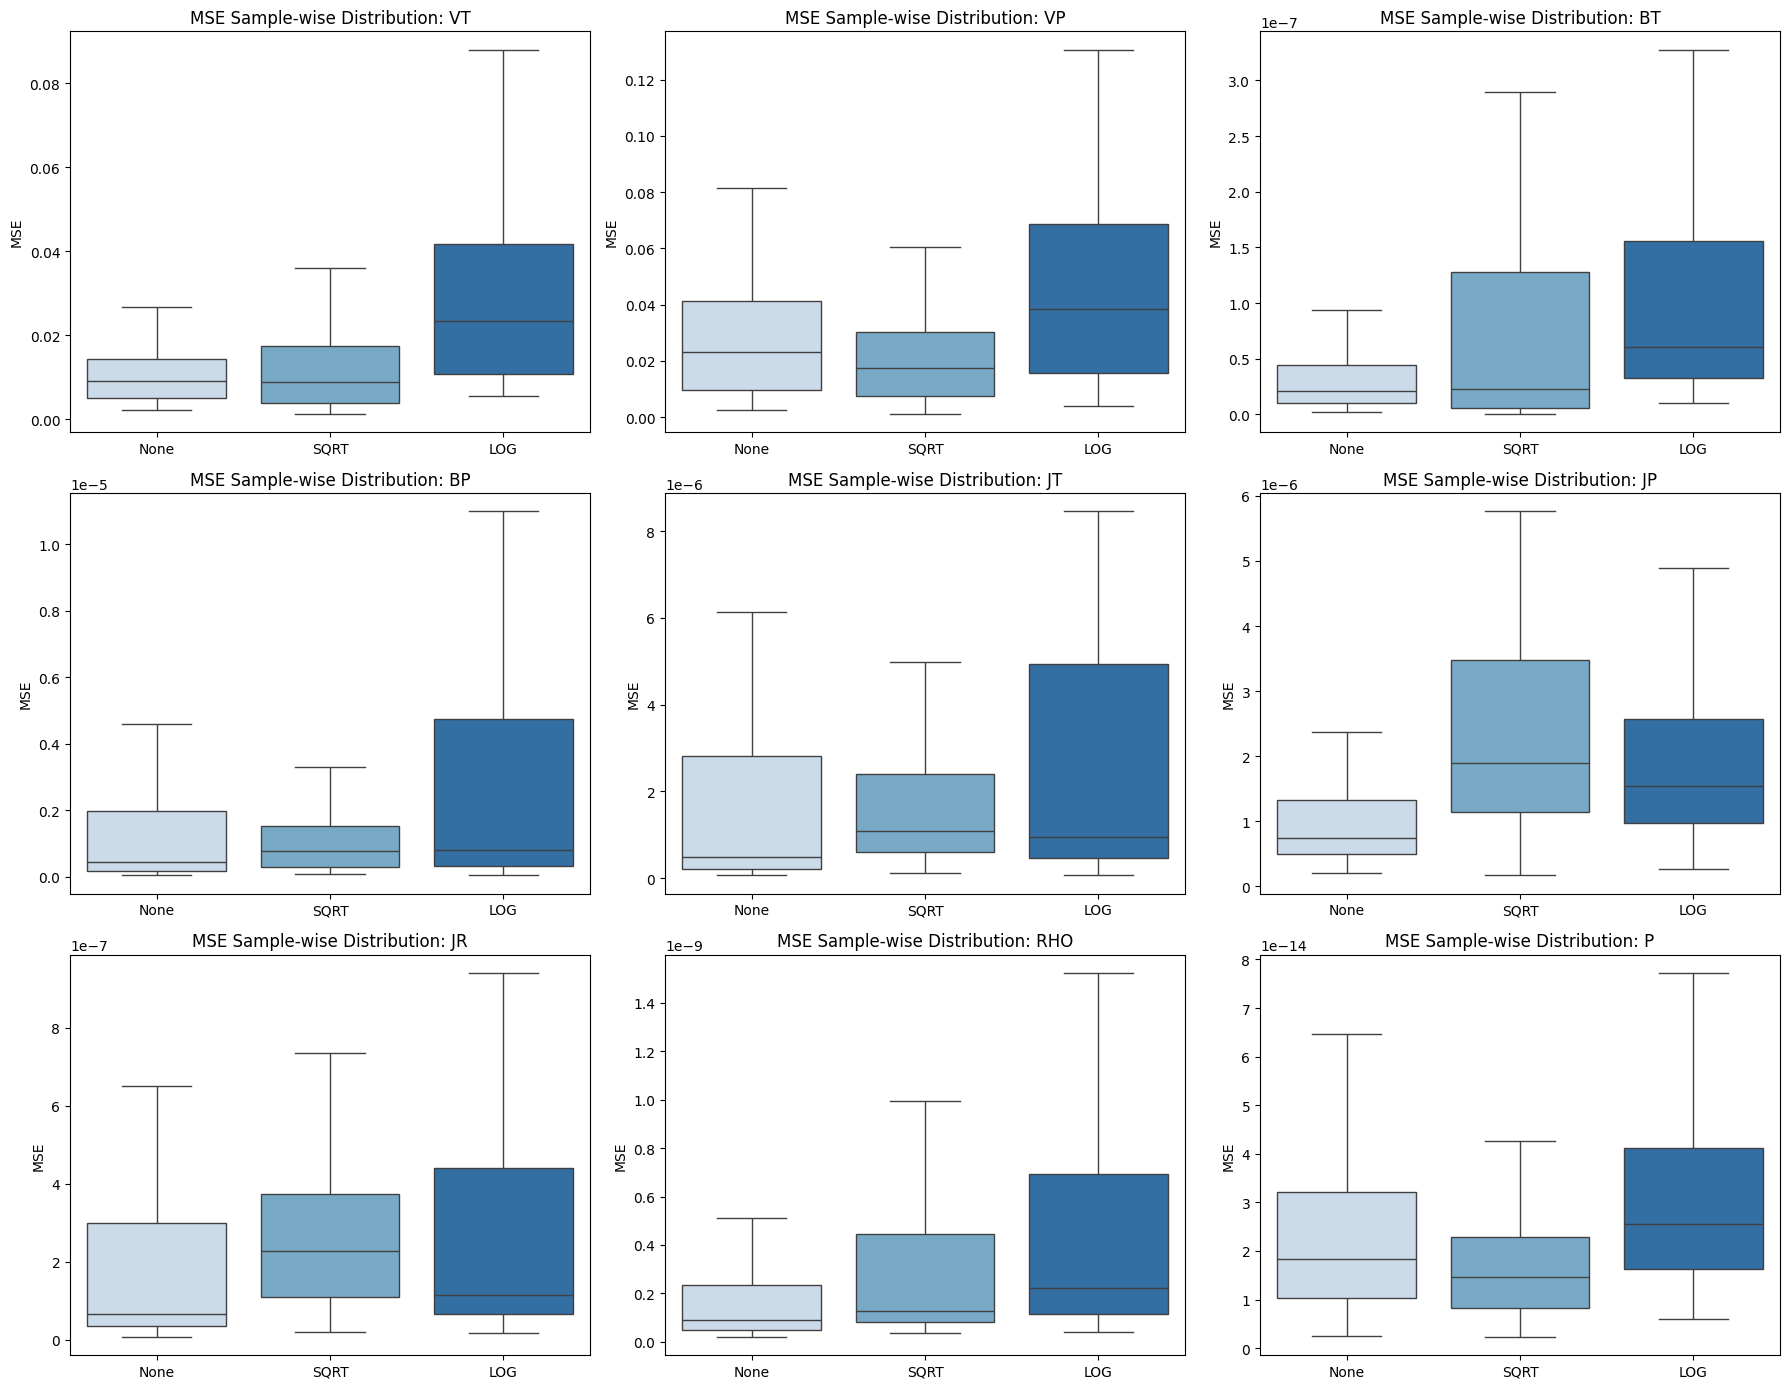

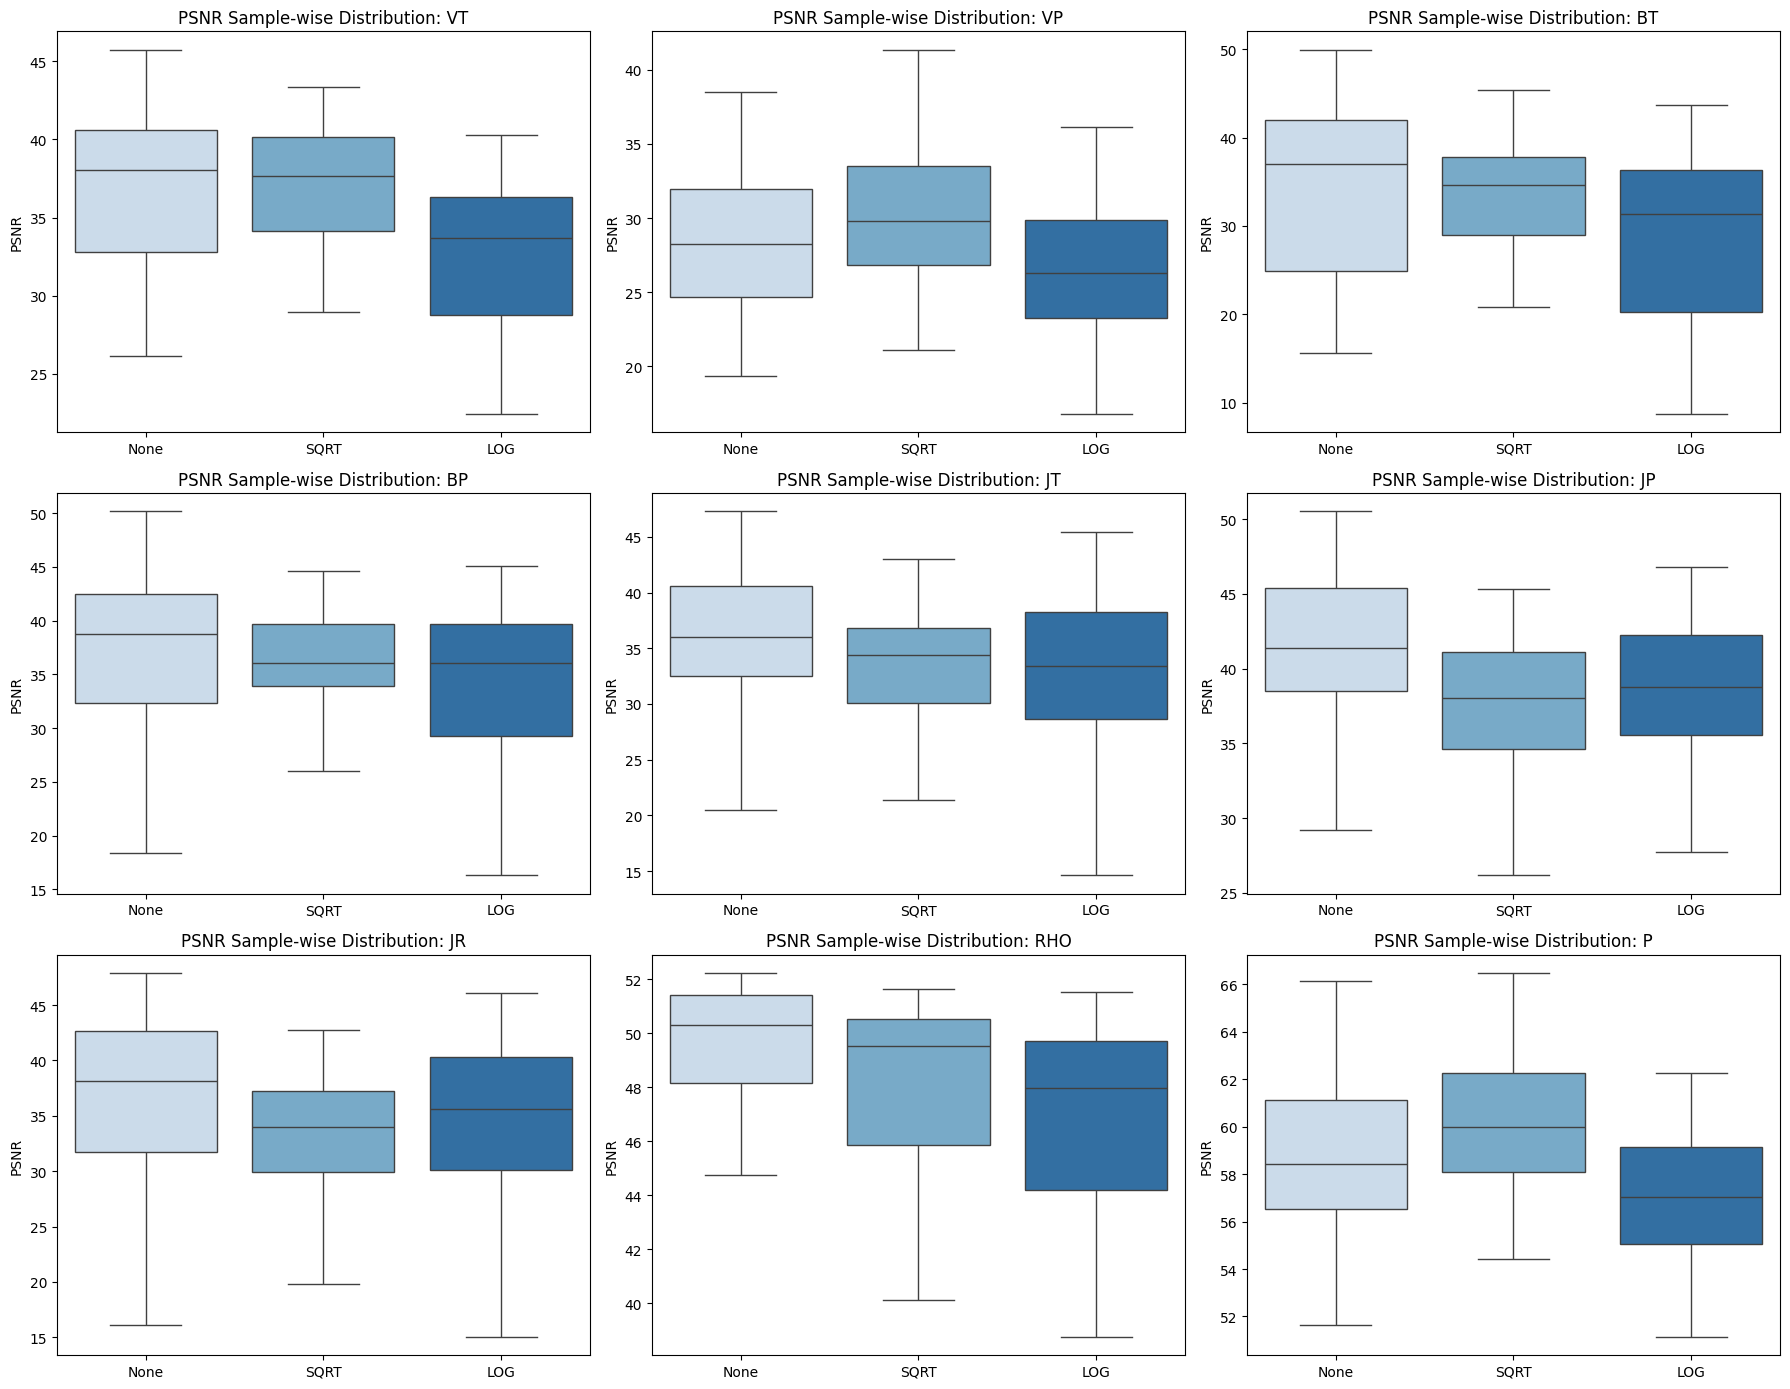

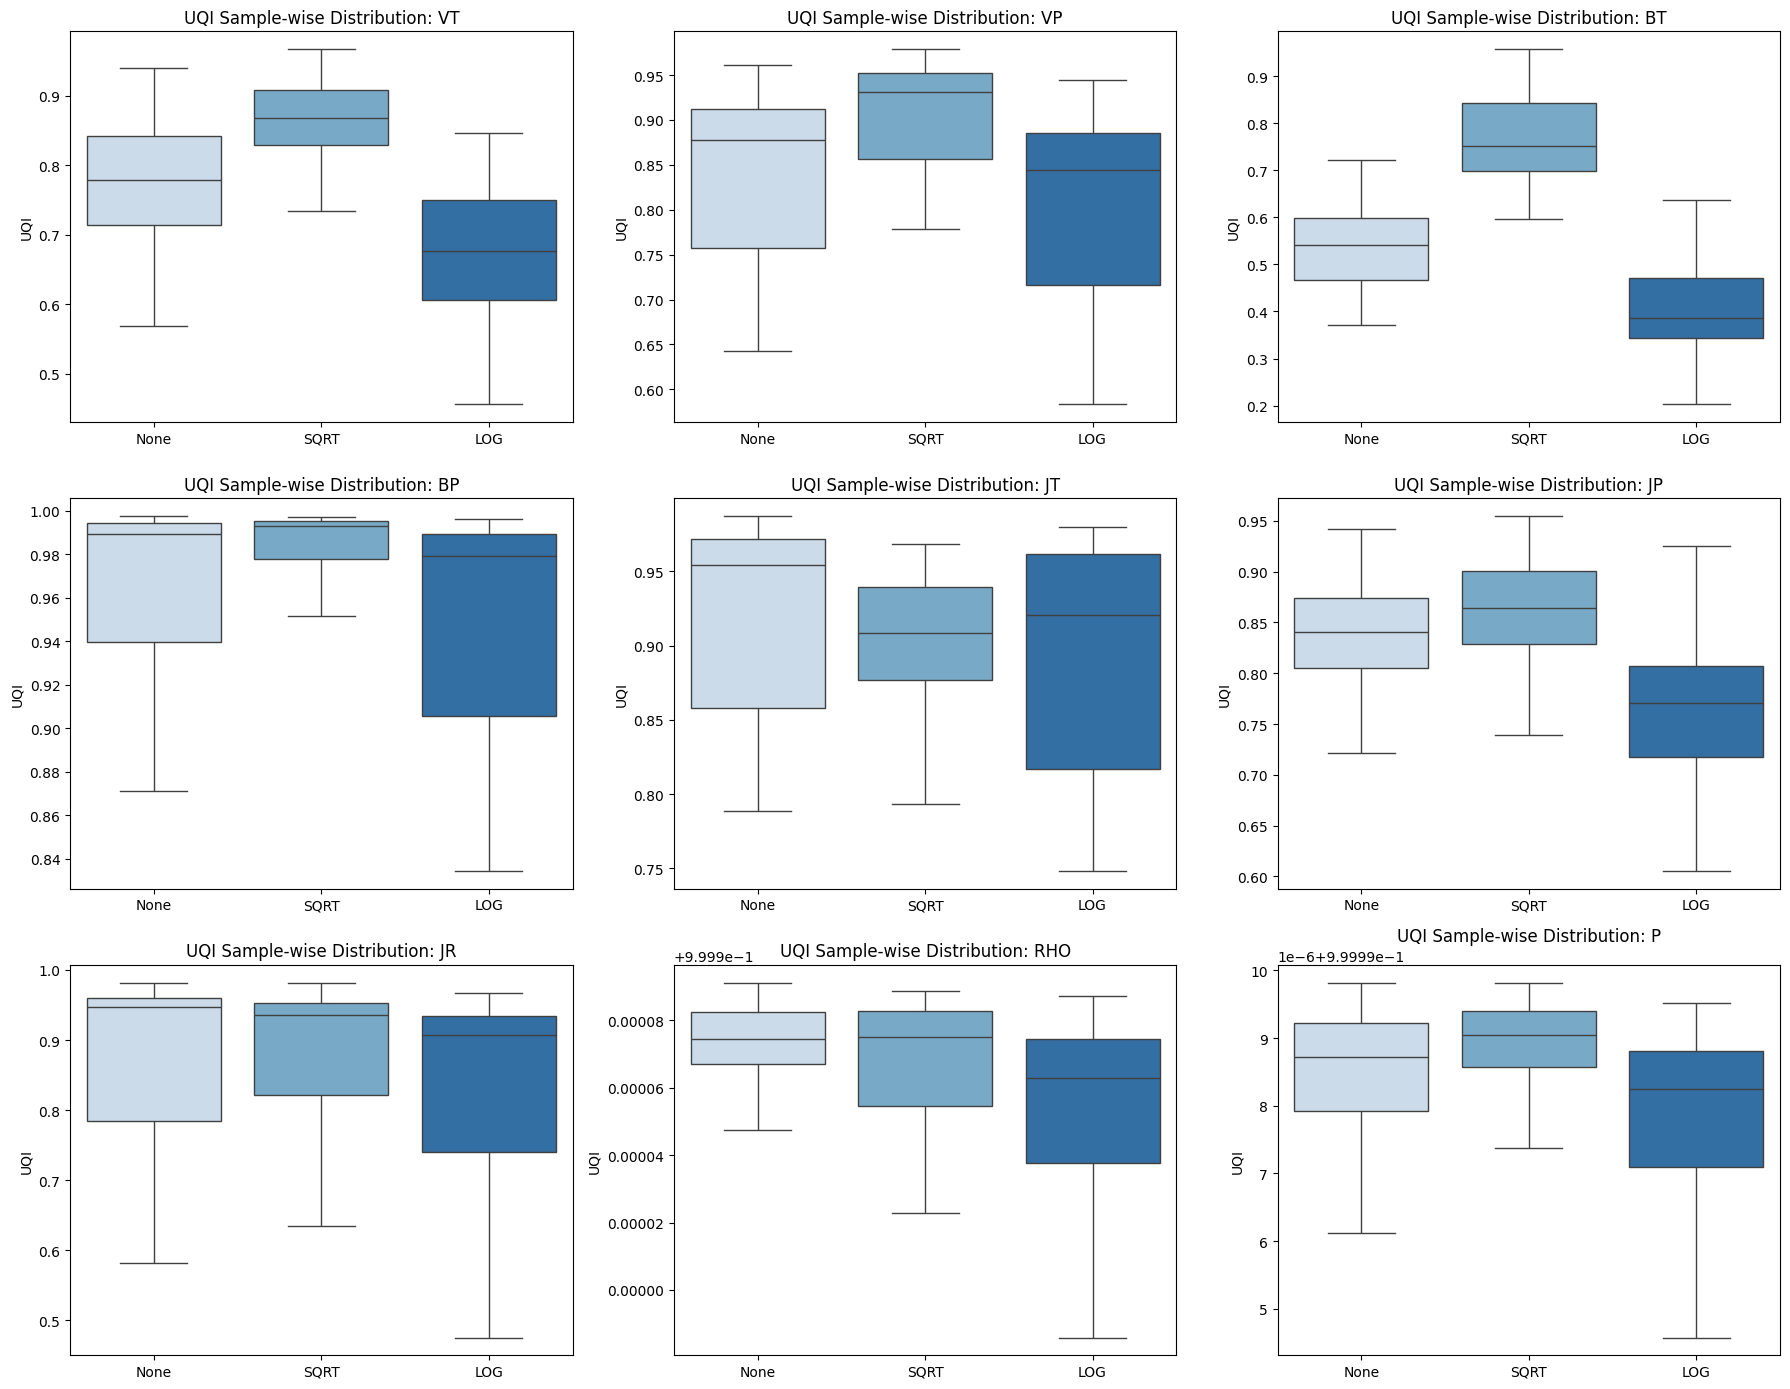

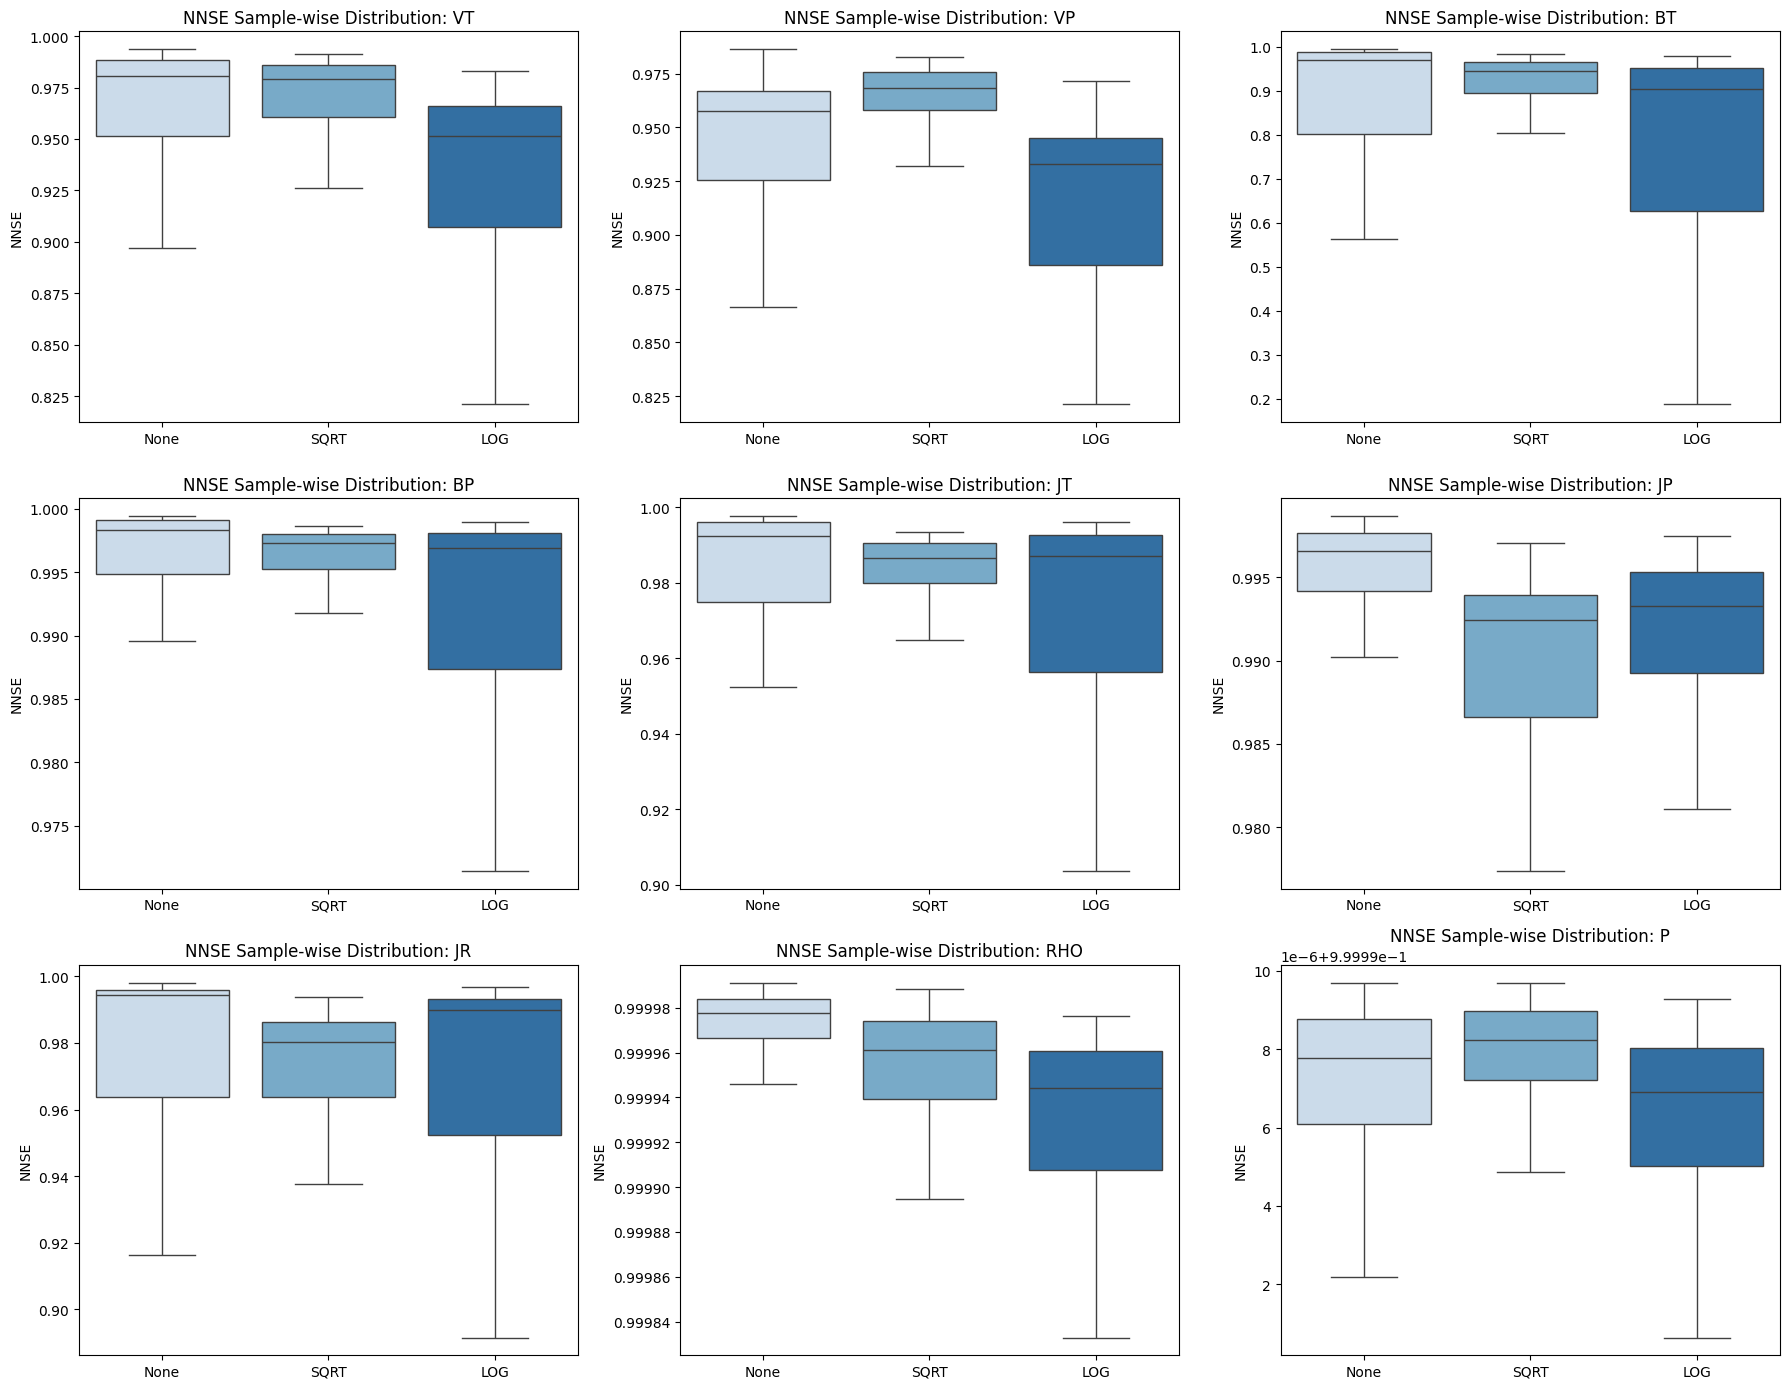

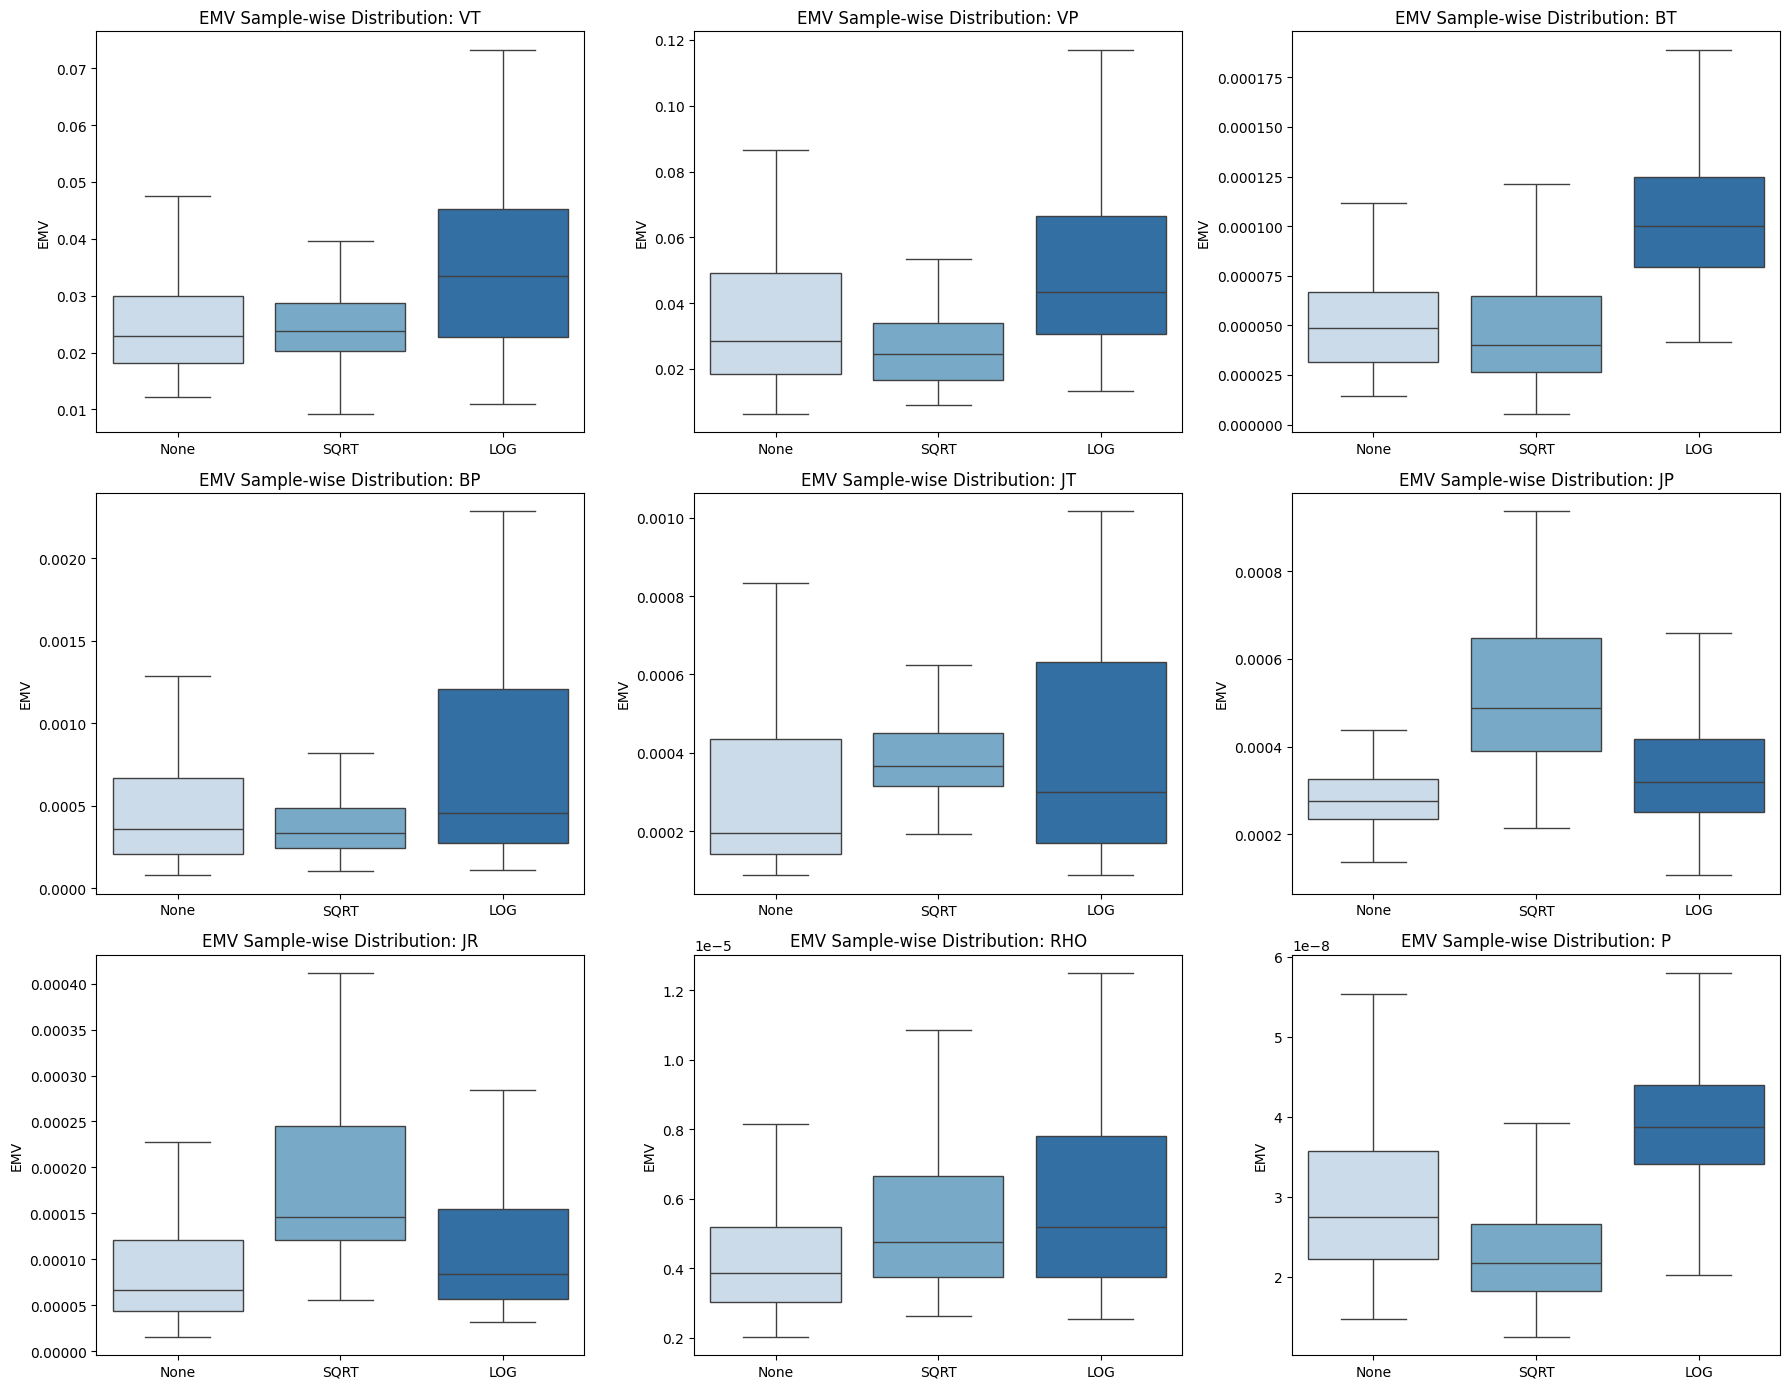

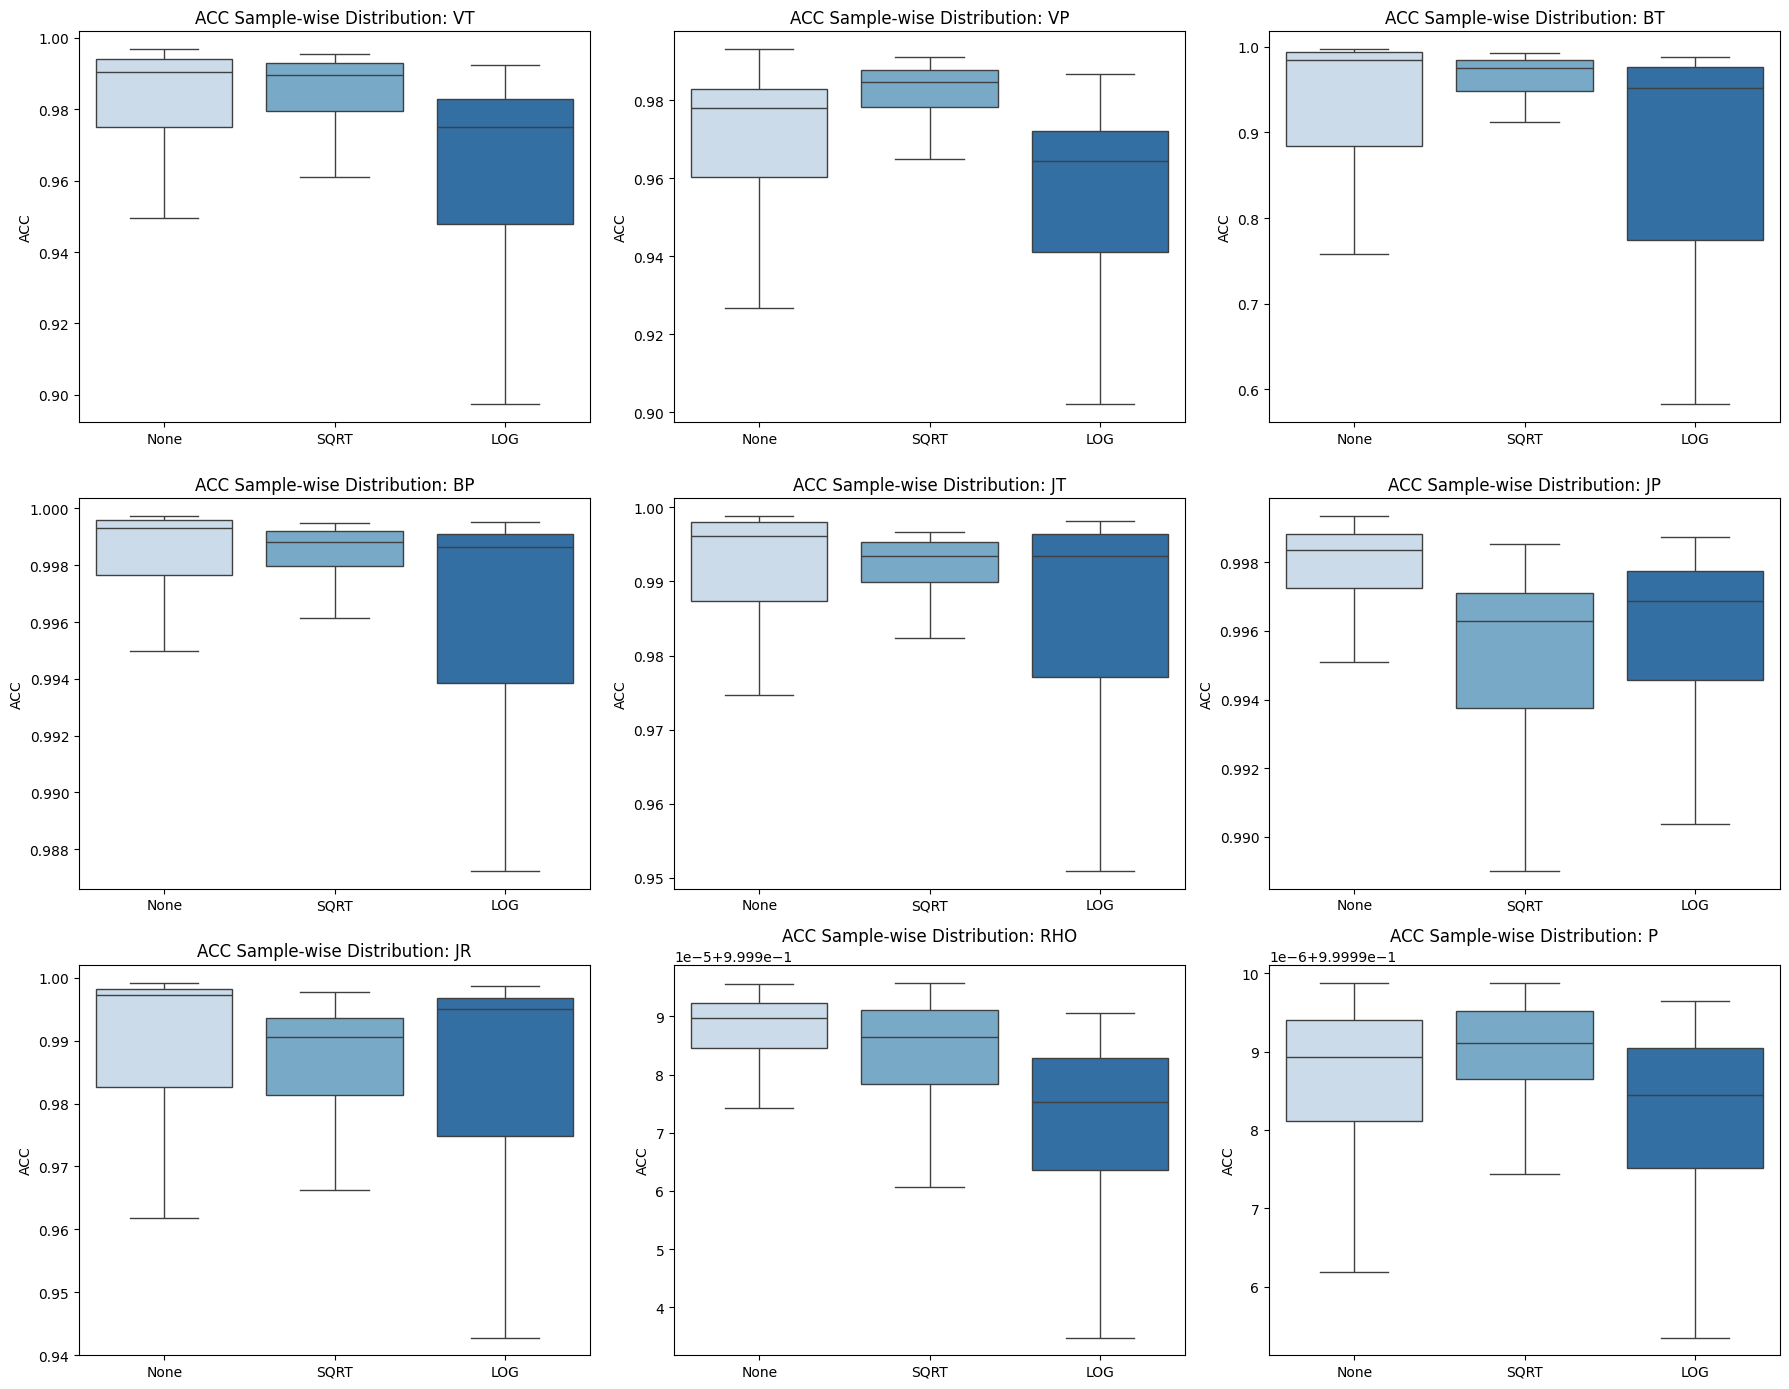

In [70]:
for metric in PER_SAMPLE_PER_COMPONENT_METRICS:
    metric_df = result_data_tf_df[result_data_tf_df['metric'] == metric]
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 14), sharey=False)
    axes = axes.flatten()
    
    for i, comp in enumerate(component_list):
        sns.boxplot(
            data=metric_df,
            x="transformation",              # distribution per run
            y=comp,               # PSNR values for this component
            hue="transformation",           # color by rank
            ax=axes[i],
            showfliers=False,
            palette="Blues",
            # legend=False
            # showfliers=True,
        )
        axes[i].set_title(f"{metric} Sample-wise Distribution: {comp.upper()}")
        axes[i].set_xlabel("")
        axes[i].set_ylabel(metric)
        axes[i].tick_params(axis="x", rotation=0)
        # axes[i].legend(title="Rank")
        # axes[i].legend_.remove()
    
    plt.tight_layout()
    plt.savefig(os.path.join('data_transform_ablation', f'sample_wise_distribution_{metric}.png'), dpi=200)
    plt.show()

In [204]:
component_list = ["vt", "vp", "bt", "bp", "jt", "jp", "jr", "rho", "p"]

# long_df = result_data_tf_df.melt(
#     id_vars=["metric", "transformation"],
#     value_vars=component_list,
#     var_name="component",
#     value_name="value"
# )
result_data_tf_df["transformation"] = result_data_tf_df["transformation"].fillna("None")

# Force desired order
transformation_order = ["None", "SQRT", "LOG"]
result_data_tf_df["transformation"] = pd.Categorical(
    result_data_tf_df["transformation"],
    categories=transformation_order,
    ordered=True
)

long_df = result_data_tf_df.melt(
    id_vars=["metric", "transformation"],
    value_vars=component_list,
    var_name="component",
    value_name="value"
)

transformation_metric_summary = (
    long_df
    .groupby(["transformation", "metric"], observed=True)["value"]
    .agg(["mean", "std"])
    .unstack("metric")
)

transformation_metric_summary = (
    transformation_metric_summary
    .swaplevel(0, 1, axis=1)
    .sort_index(axis=1)
    .reindex(transformation_order)
)

transformation_metric_summary

metric               ACC                 EMV                 MSE            \
                    mean       std      mean       std      mean       std   
transformation                                                               
None            0.982333  0.038999  0.007242  0.016887  0.005192  0.017349   
SQRT            0.987351  0.020497  0.006041  0.012098  0.003984  0.011407   
LOG             0.980550  0.040744  0.008139  0.019279  0.006243  0.020709   

metric              NNSE                 PSNR                  UQI            
                    mean       std       mean        std      mean       std  
transformation                                                                
None            0.968619  0.064433  39.671158  10.642557  0.860691  0.152998  
SQRT            0.975520  0.036427  38.697197  10.091477  0.907112  0.092921  
LOG             0.964208  0.072751  39.168251  10.789177  0.852723  0.160250

# Plot Climatology distribution

In [41]:
cr_dirs = get_cr_dirs(DATA_DIR)
np.random.seed(42)
np.random.shuffle(cr_dirs)
# cr_train, cr_test = cr_dirs[:split_ix], cr_dirs[split_ix:]
split_ix = int(len(cr_dirs) * 0.9)
cr_train, cr_test = cr_dirs[:split_ix], cr_dirs[split_ix:]

train_dataset = InitialParamDataset(
DATA_DIR, 
cr_train,
scale_up=1,
transform=None,
pos_embedding=False,
)
test_dataset = InitialParamDataset(
DATA_DIR, 
cr_test, 
v_min=train_dataset.v_min, 
v_max=train_dataset.v_max,
scale_up=1,
transform=None,
pos_embedding=False,
)

Loading simulations: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 812/812 [29:00<00:00,  2.14s/it]


(812, 11, 109, 128)


Loading simulations: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 95/95 [03:26<00:00,  2.18s/it]


(95, 11, 109, 128)


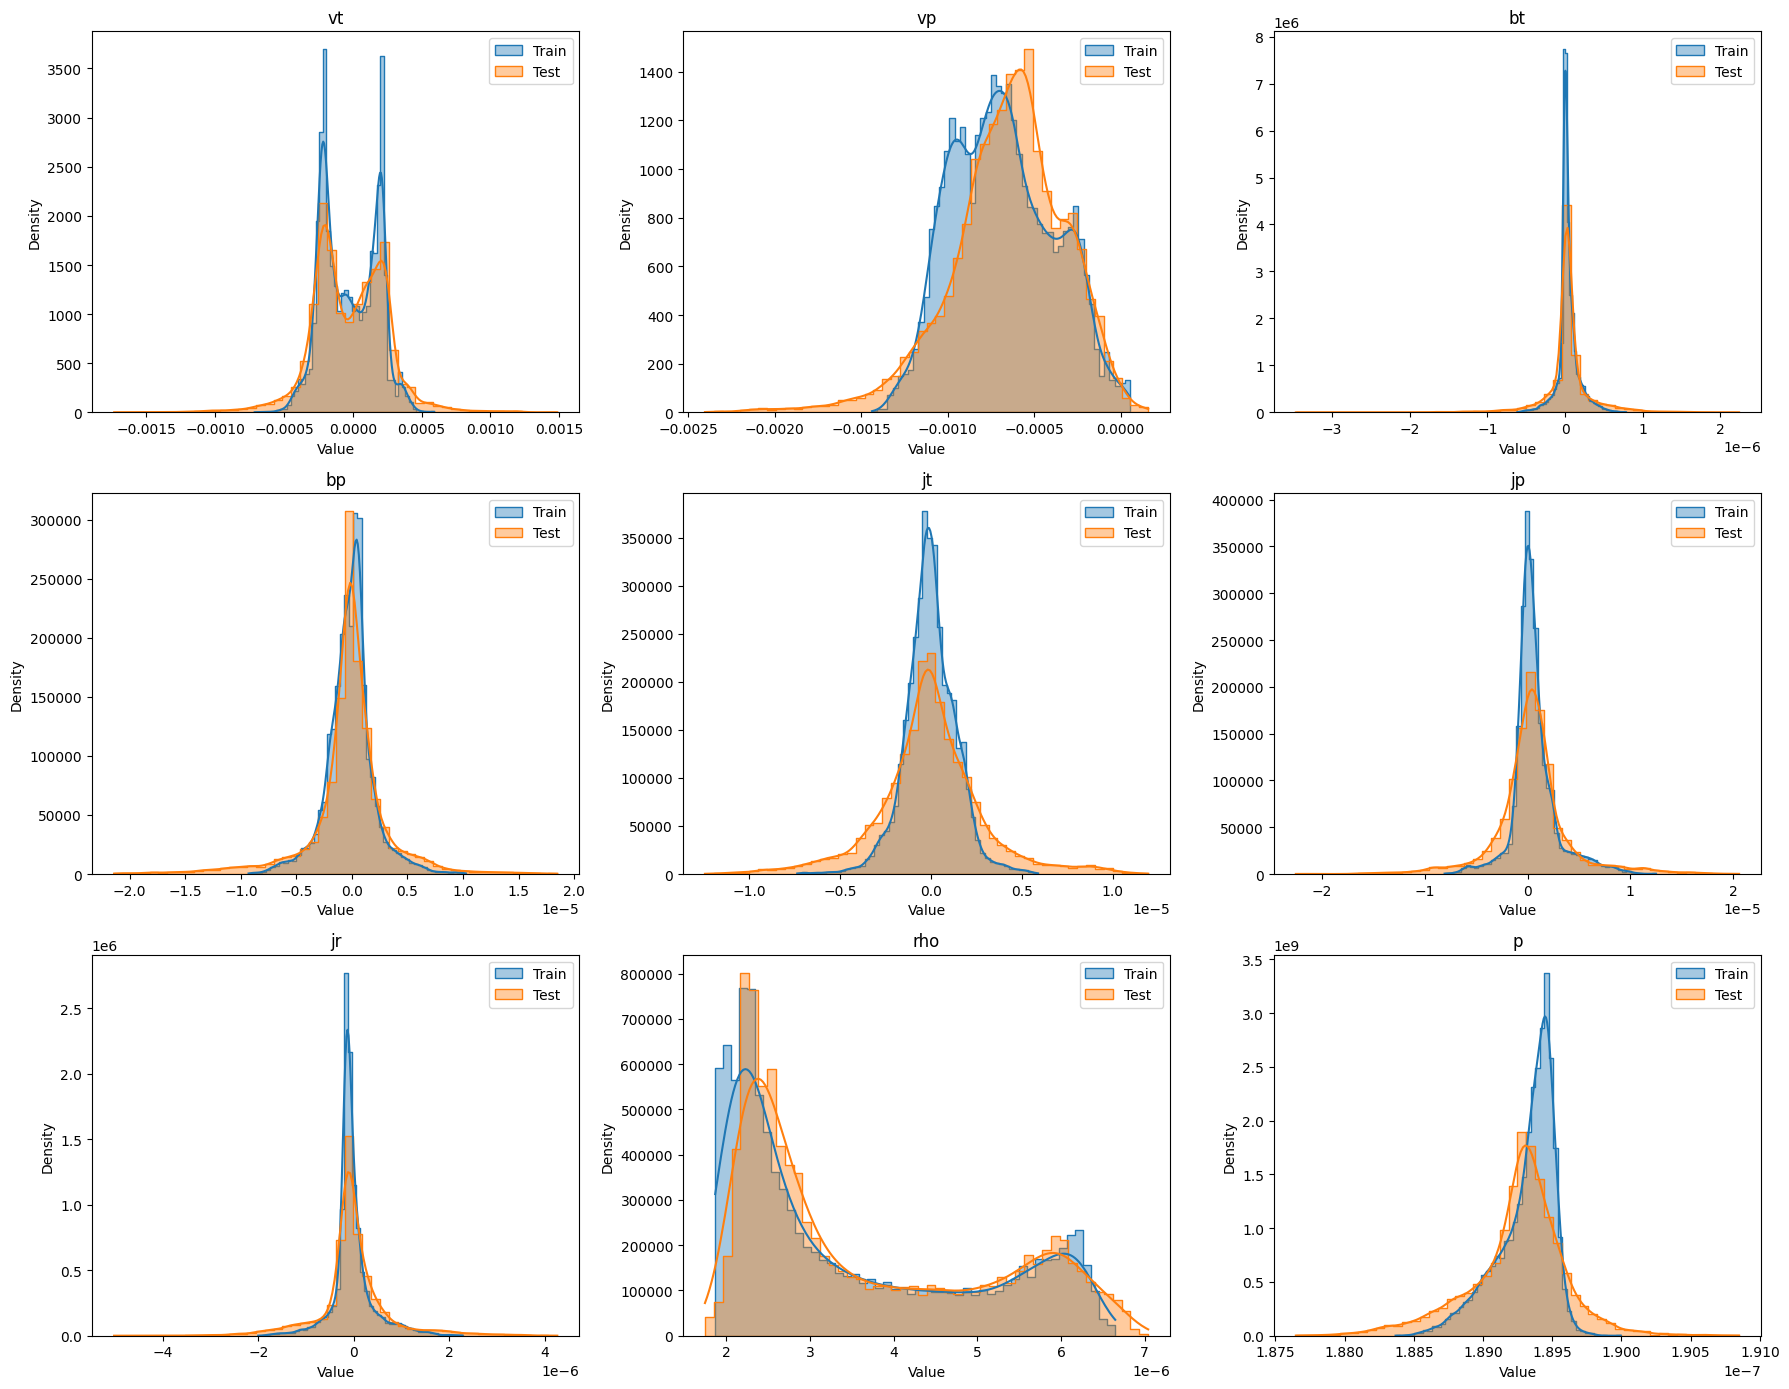

In [63]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i in range(9):
    train_vals = train_dataset.climatology[i].ravel()
    test_vals = test_dataset.climatology[i].ravel()

    sns.histplot(
        train_vals,
        bins=50,
        stat="density",
        kde=True,
        ax=axes[i],
        label="Train",
        alpha=0.4,
        element="step",
        common_norm=False
    )

    sns.histplot(
        test_vals,
        bins=50,
        stat="density",
        kde=True,
        ax=axes[i],
        label="Test",
        alpha=0.4,
        element="step",
        common_norm=False
    )


    axes[i].set_title(component_list[i])
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].legend()

plt.tight_layout()
plt.savefig('histogram_distribution/climatology_no_transformation.png', dpi=300)
plt.show()

In [160]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import torch.nn as nn
import math
import numpy as np
from tqdm import tqdm
from pyhdf.SD import SD, SDC

from os.path import join as path_join
from neuralop import LpLoss
from scipy.ndimage import zoom
import os
from neuralop.losses import H1Loss
from scipy.interpolate import RegularGridInterpolator
import gc

FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf", "jt002.hdf", "jp002.hdf", "jr002.hdf", "rho002.hdf", "p002.hdf"]
# FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf"]

DEFAULT_INSTRUMENTS = [
    "kpo_mas_mas_std_0101",
    "mdi_mas_mas_std_0101",
    "hmi_mast_mas_std_0101",
    "hmi_mast_mas_std_0201",
    "hmi_masp_mas_std_0201",
    "mdi_mas_mas_std_0201",
]


def read_hdf(hdf_path, dataset_names):
    f = SD(hdf_path, SDC.READ)
    datasets = []
    for dataset_name in dataset_names:
        datasets.append(f.select(dataset_name).get())
    return datasets


def get_coords(sim_path):
    v_path = path_join(sim_path, FILE_NAMES[0])
    thetas, phis = read_hdf(v_path, ["fakeDim1", "fakeDim0"])
    return thetas, phis

def interpolate_cube(data, x_old, y_old, z_old, x_new, y_new, z_new):
    interp_func = RegularGridInterpolator(
        (x_old, y_old, z_old),
        data,
        method="linear",
        bounds_error=False,
        fill_value=None,
    )
    xg, yg, zg = np.meshgrid(x_new, y_new, z_new, indexing="ij")
    points_new = np.stack([xg.ravel(), yg.ravel(), zg.ravel()], axis=-1)
    data_new_flat = interp_func(points_new)
    data_new = data_new_flat.reshape((len(x_new), len(y_new), len(z_new)))
    return data_new

def read_sim(sim_path):
    dataset_names = ["Data-Set-2", "fakeDim0", "fakeDim1", "fakeDim2"]
    component_dict = {k.split('002')[0]:{} for k in FILE_NAMES}
    target_phi, target_theta, target_r = [None]*3
    for file_name in FILE_NAMES:
        data, phi, theta, r = read_hdf(f"{sim_path}/{file_name}", dataset_names) 
        comp = file_name.split('002')[0]
        component_dict[comp] = {
            'data': data[:,:, :3],
            'theta': theta,
            'r': r[:3]
        }
        if comp == 'vp':
            target_r = np.array([r[1]], dtype=r.dtype) # [30.742662]
            target_theta = theta
            target_phi = phi
            
    return (component_dict, target_r, target_theta, target_phi)

def get_sim(sim_path, scale_up):
    
    component_list = [k.split('002')[0] for k in FILE_NAMES]
    out, target_r, target_theta, phi = read_sim(sim_path)

    final = dict()
    for component in component_list:
        
        data_old, theta_old, r_old = (
            out[component]["data"],
            out[component]["theta"],
            out[component]["r"],
        )
        # print(f'{component}: Before Interpolation shape: {data_old.shape}')
        data_new = interpolate_cube(data_old, phi, theta_old, r_old, phi, target_theta, target_r)
        data_new = np.transpose(data_new, (2, 1, 0))  # (r, theta, phi)
        # print(f'{component}: After Interpolation shape: {data_new.shape}')
        final[component] = data_new[0,1:-1,:]
        # print(f'{component}: After Cropping shape: {final[component].shape}')

    final_component_arr = np.array([final[comp] for comp in component_list])
    
    if scale_up != 1:
        final_component_arr = enlarge_cube(final_component_arr, scale_up)

    return final_component_arr, (target_r, target_theta[1:-1], phi)


def get_sims(sim_paths, scale_up, pos_emb = None):
    sims = []

    for sim_path in tqdm(sim_paths, desc="Loading simulations"):
        sim, _ = get_sim(sim_path, scale_up)  # (140, 111, 128)
        sims.append(sim)

    sims = np.stack(sims, axis=0)  # (N, 11, 111, 128)
    return sims



def enlarge_cube(cube, scale):
    """
    Enlarge the spatial dimensions (axis 2 and 3) of a 4D cube using bilinear interpolation.

    Parameters:
    - cube: np.ndarray of shape (11, 110, 128)
    - scale: int or float (e.g., 2)

    Returns:
    - enlarged_cube: np.ndarray of shape (11, 110 * scale, 128 * scale)
    """
    return zoom(cube, (1, scale, scale), order=1)

def signed_sqrt_transform(array):
    return np.sign(array) * (np.abs(array)**0.5)

def signed_pow_transform(array, power):
    return np.sign(array) * (np.abs(array)**power)

def signed_log_transform(array):
    return np.sign(array) * np.log(np.abs(array)+1)

def signed_transform(array, transform='sqrt', power=None):
    if transform == 'sqrt':
        return signed_sqrt_transform(array)
    elif transform == 'log':
        return signed_log_transform(array)
    elif transform == 'pow' and power is not None:
        return signed_pow_transform(array, power)
    else:
        raise ValueError("Unsupported transform type or missing power for 'pow' transform.")

def data_transformation(array, transform='sqrt', power=None):
    """
    :param array: (11, H, W)
    Returns: array after data transformation 
    """
    # VR_0 -> No transformation required
    
    # BR_0 -> No transformation required
    # VT_0
    array[:,2] = signed_transform(array[:,2], transform=transform, power=power)   # Sign-preserving data transformation
    # VP_0
    array[:,3] = signed_transform(array[:,3], transform=transform, power=power)   # Sign-preserving data transformation
    # BT_0
    array[:,4] = signed_transform(array[:,4], transform=transform, power=power)   # Sign-preserving data transformation
    # BP_0
    array[:,5] = signed_transform(array[:,5], transform=transform, power=power)   # Sign-preserving data transformation
    # JT_0 -> No transformation required
    # JP_0
    array[:,7] = signed_transform(array[:,7], transform=transform, power=power)   # Sign-preserving data transformation
    # JR_0
    array[:,8] = signed_transform(array[:,8], transform=transform, power=power)   # Sign-preserving data transformation
    # RHO_0 -> No transformation required
    array[:,9] = signed_sqrt_transform(array[:,9])   # Sign-preserving square root transformation
    # P_0 
    array[:,10] = signed_transform(array[:,10], transform='pow', power=0.25)   # Sign-preserving POW(0.25) transformation
    return array


def signed_power_inverse_transform(array, power):
    return torch.sign(array) * (torch.abs(array)**power)

def signed_exp_inverse_transform(array):
    return torch.sign(array) * (torch.exp(torch.abs(array)) - 1)

def signed_inverse_transform(array, transform='square', power=None):
    if transform == 'square':
        return signed_power_inverse_transform(array, power=2)
    elif transform == 'exp':
        return signed_exp_inverse_transform(array)  # Subtract 1 to reverse the +1 in the log transform
    elif transform == 'pow' and power is not None:
        return signed_power_inverse_transform(array, power=power)
    else:
        raise ValueError("Unsupported inverse transform type or missing power for 'pow' inverse transform.")

def data_inverse_transformation(array,inverse_transform, power=None, scale_metric=481.3711):
    """
    :param array: (9, H, W)  
    Returns: array after data transformation 
    """
    # VR_0 -> No inverse transformation required
    
    # BR_0 -> No inverse transformation required
    # VT_0
    array[:, 0] = signed_inverse_transform(array[:, 0], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # VP_0
    array[:,1] = signed_inverse_transform(array[:, 1], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # BT_0
    array[:, 2] = signed_inverse_transform(array[:, 2], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # BP_0
    array[:, 3] = signed_inverse_transform(array[:, 3], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # JT_0 -> No inverse transformation required
    # JP_0
    array[:, 5] = signed_inverse_transform(array[:, 5], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # JR_0
    array[:, 6] = signed_inverse_transform(array[:, 6], transform=inverse_transform, power=power)   # Sign-preserving inverse transformation
    # RHO_0 -> No inverse transformation required
    array[:, 7] = signed_inverse_transform(array[:, 7], transform='square')   # Sign-preserving inverse square transformation
    # P_0 
    array[:, 8] = signed_inverse_transform(array[:, 8], transform='pow', power=4)   # Sign-preserving inverse POW(4) transformation

    return array * scale_metric

def min_max_normalize(array, min_=None, max_=None):
    if min_ is None or max_ is None:
        min_ = np.min(array, axis=(0,2,3))
        max_ = np.max(array, axis=(0,2,3))
    array = (array - min_[:,None, None]) / (max_[:,None, None] - min_[:,None, None] + 1e-9)
    return array, min_, max_

def min_max_denormalize(array, min_, max_):
    '''
    Denormalize the data using the provided min and max values.
    :param array: Normalized array of shape (N, 11, H, W)
    :param min_: Minimum values for each channel (shape: (11,))
    :param max_: Maximum values for each channel (shape: (11,))
    '''
    array = array * (max_[:, None, None] - min_[:, None, None] + 1e-9) + min_[:, None, None]
    return array

def compute_climatology(data: np.ndarray, scale_up) -> np.ndarray:
    """
    Compute per-voxel climatology (mean field) from a dataset.

    Args:
        data (np.ndarray): Array of shape (N, 9, 109, 128)

    Returns:
        np.ndarray: Climatology array of shape (9, 109, 128)
    """
    assert data.ndim == 4 and data.shape[1:] == (
        9,
        109 * scale_up,
        128 * scale_up,
    ), "Unexpected input shape."
    climatology = np.mean(data, axis=0)
    climatology = torch.tensor(climatology, dtype=torch.float32)
    return climatology


def get_cr_dirs(data_path):
    """Return list of CR directories (crXXXX) inside data_path."""
    cr_dirs = sorted(
        [
            d
            for d in os.listdir(data_path)
            if d.startswith("cr") and os.path.isdir(os.path.join(data_path, d))
        ]
    )
    return cr_dirs


def collect_sim_paths(data_path, cr_list, instruments=None):
    """Collect simulation paths given a list of CR directories."""
    if instruments is None:
        instruments = DEFAULT_INSTRUMENTS

    sim_paths = []
    cr_nums = []
    for cr in cr_list:
        cr_path = os.path.join(data_path, cr)
        for instrument in instruments:
            instrument_path = os.path.join(cr_path, instrument)
            if os.path.exists(instrument_path):
                sim_paths.append(instrument_path)
                cr_nums.append(cr)
    return sim_paths, cr_nums


class InitialParamDataset(Dataset):
    def __init__(
        self,
        data_path,
        cr_list,
        v_min=None,
        v_max=None,
        instruments=None,
        scale_up=1,
        pos_embedding = None,
        transform=None,
        transform_fn = None
    ):
        super().__init__()
        if transform == 'pow':
            self.transform = 'pow'
            self.inverse_transform = 'pow'
            self.transform_power = 0.5
            self.inverse_transform_power = 2
        elif transform in {'sqrt', 'log'}:
            self.transform = transform
            self.inverse_transform = 'exp' if transform == 'log' else 'square'
            self.transform_power = None
            self.inverse_transform_power = None
        
        self.sim_paths, self.cr_mapping = collect_sim_paths(data_path, cr_list, instruments)
        self.sims = get_sims(self.sim_paths, scale_up, pos_embedding)
        self.climatology = compute_climatology(self.sims[:,2:], scale_up)
        print(self.sims.shape)

        _, (r,theta,phi) = get_sim(self.sim_paths[0], scale_up)
        self.r = torch.tensor(r, dtype=torch.float32)
        self.theta = torch.tensor(theta, dtype=torch.float32)
        self.phi = torch.tensor(phi, dtype=torch.float32)

        # self.sims = data_transformation(self.sims, self.transform, power=self.transform_power)
        # self.sims, self.v_min, self.v_max = min_max_normalize(self.sims, v_min, v_max)

        self.data_min = torch.tensor([ 4.67303783e-01, -1.58353511e-03, -7.15157911e-02, -3.33132781e-02,
       -1.28728367e-04, -2.80083535e-04, -4.16646682e-04, -1.07131642e-03,
       -1.45251848e-04,  1.45591866e-06,  1.14962724e-07], dtype=torch.float32)
        self.data_max = torch.tensor([1.3710672e+00, 1.6776990e-03, 7.1827546e-02, 6.5376662e-02,
       8.6796281e-05, 2.7548801e-04, 3.7248712e-04, 1.0954458e-03,
       1.5482063e-04, 1.2102652e-05, 4.1580401e-07], dtype=torch.float32)

        

    def __getitem__(self, index):
        cube = self.sims[index]

        C, H, W = cube.shape

        return {
            "x": torch.from_numpy(cube[:2]).float(),
            "y": torch.from_numpy(cube[2:]).float(),
            'cr': self.cr_mapping[index],
            'idx': index
        }

    def __len__(self):
        return len(self.sims)

    def get_min_max(self):
        return {"v_min": [float(v) for v in self.v_min], "v_max": [float(v) for v in self.v_max]}

    def get_grid_points(self):
        return get_coords(self.sim_paths[0])


In [161]:
cr_dirs = get_cr_dirs(DATA_DIR)
np.random.seed(42)
np.random.shuffle(cr_dirs)
# cr_train, cr_test = cr_dirs[:split_ix], cr_dirs[split_ix:]
split_ix = int(len(cr_dirs) * 0.9)
cr_train, cr_test = cr_dirs[:split_ix], cr_dirs[split_ix:]

train_dataset = InitialParamDataset(
DATA_DIR, 
cr_dirs,
scale_up=1,
transform=None,
pos_embedding=False,
)

Loading simulations: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 907/907 [01:48<00:00,  8.38it/s]


(907, 11, 109, 128)


In [107]:
component_list
compoenent

['vt', 'vp', 'bt', 'bp', 'jt', 'jp', 'jr', 'rho', 'p']

In [162]:
new_arr = np.zeros((907,9,109,128))

for i, comp in enumerate(component_list):
    old_arr = train_dataset.sims[:,i+2]
    if comp == 'jt':
        new_arr[:,i] = old_arr
    elif comp == 'p':
        new_arr[:,i] = np.sign(old_arr)*np.power(np.abs(old_arr),0.25)
    else:
        new_arr[:,i] = np.sign(old_arr)*np.sqrt(np.abs(old_arr))


(907, 109, 128)
(907, 109, 128)
(907, 109, 128)
(907, 109, 128)
(907, 109, 128)
(907, 109, 128)
(907, 109, 128)
(907, 109, 128)
(907, 109, 128)


In [163]:
min_ = np.min(new_arr, axis=(2,3))
max_ = np.max(new_arr, axis=(2,3))
range_ = max_ - min_

In [164]:
norm_arr = np.zeros((907,9,109,128))
for i, comp in enumerate(component_list):
    norm_arr[:,i] = (new_arr[:,i] - min_[:,i,np.newaxis,np.newaxis])/range_[:,i,np.newaxis,np.newaxis]

In [156]:
old_min_ = np.min(train_dataset.sims[:,2:], axis=(2,3))
old_max_ = np.max(train_dataset.sims[:,2:], axis=(2,3))
old_range_ = old_max_ - old_min_

old_norm_arr = np.zeros((907,9,109,128))
for i, comp in enumerate(component_list):
    old_norm_arr[:,i] = (train_dataset.sims[:,i+2] - old_min_[:,i,np.newaxis,np.newaxis])/old_range_[:,i,np.newaxis,np.newaxis]

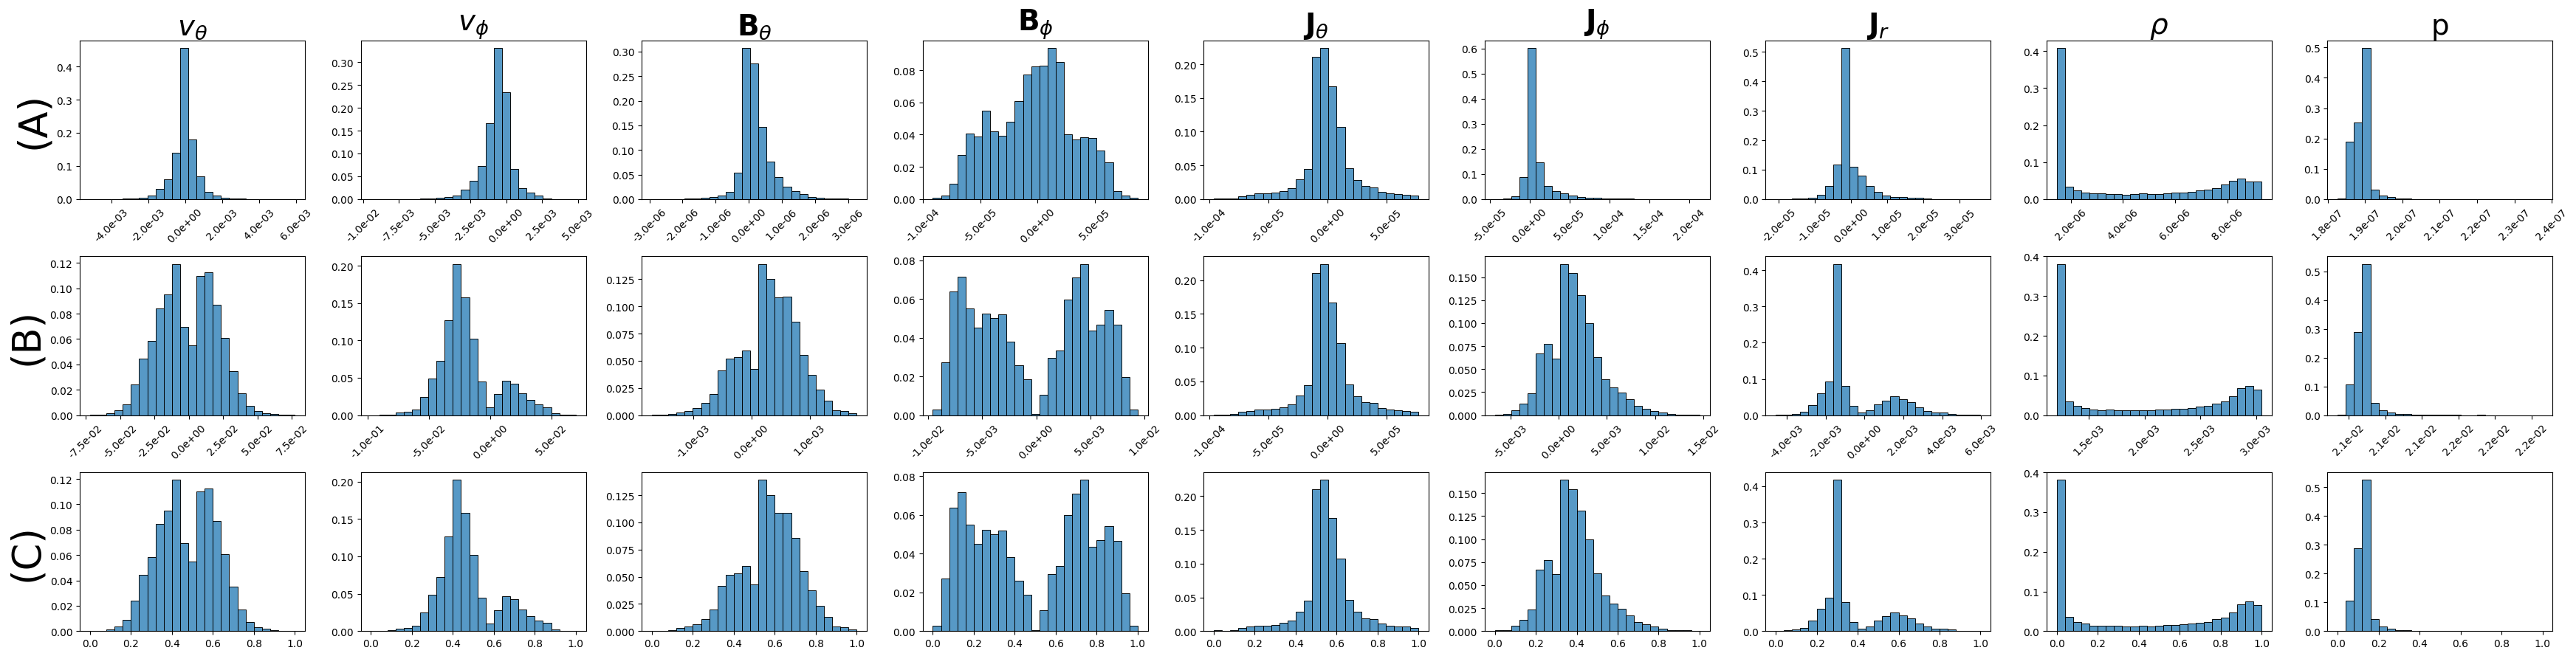

In [289]:
fig, ax = plt.subplots(3,9,figsize=(35,9))
# ax = ax.flatten()
for i,c in enumerate(component_list):
    sns.histplot(train_dataset.sims[0,i+2].reshape((-1,)), bins=25, stat='probability',ax=ax[0,i])
    sns.histplot(new_arr[0,i].reshape((-1,)), bins=25, stat='probability',ax=ax[1,i])
    sns.histplot(norm_arr[0,i].reshape((-1,)), bins=25, stat='probability',ax=ax[2,i])
    ax[0,i].set_title(f'{component_title_dict[c]}', fontsize=28)
    ax[0,i].set_ylabel('')
    ax[1,i].set_ylabel('')
    ax[2,i].set_ylabel('')
    ax[0,0].set_ylabel('(A)', fontsize=38)
    ax[1,0].set_ylabel('(B)', fontsize=38)
    ax[2,0].set_ylabel('(C)', fontsize=38)
    ax[0,i].tick_params(axis="x", rotation=45)
    ax[0,i].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1e'))
    ax[1,i].tick_params(axis="x", rotation=45)
    ax[1,i].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1e'))
    
plt.tight_layout()
plt.savefig('histogram_distribution/data_transformation.pdf', dpi=300)
plt.show()

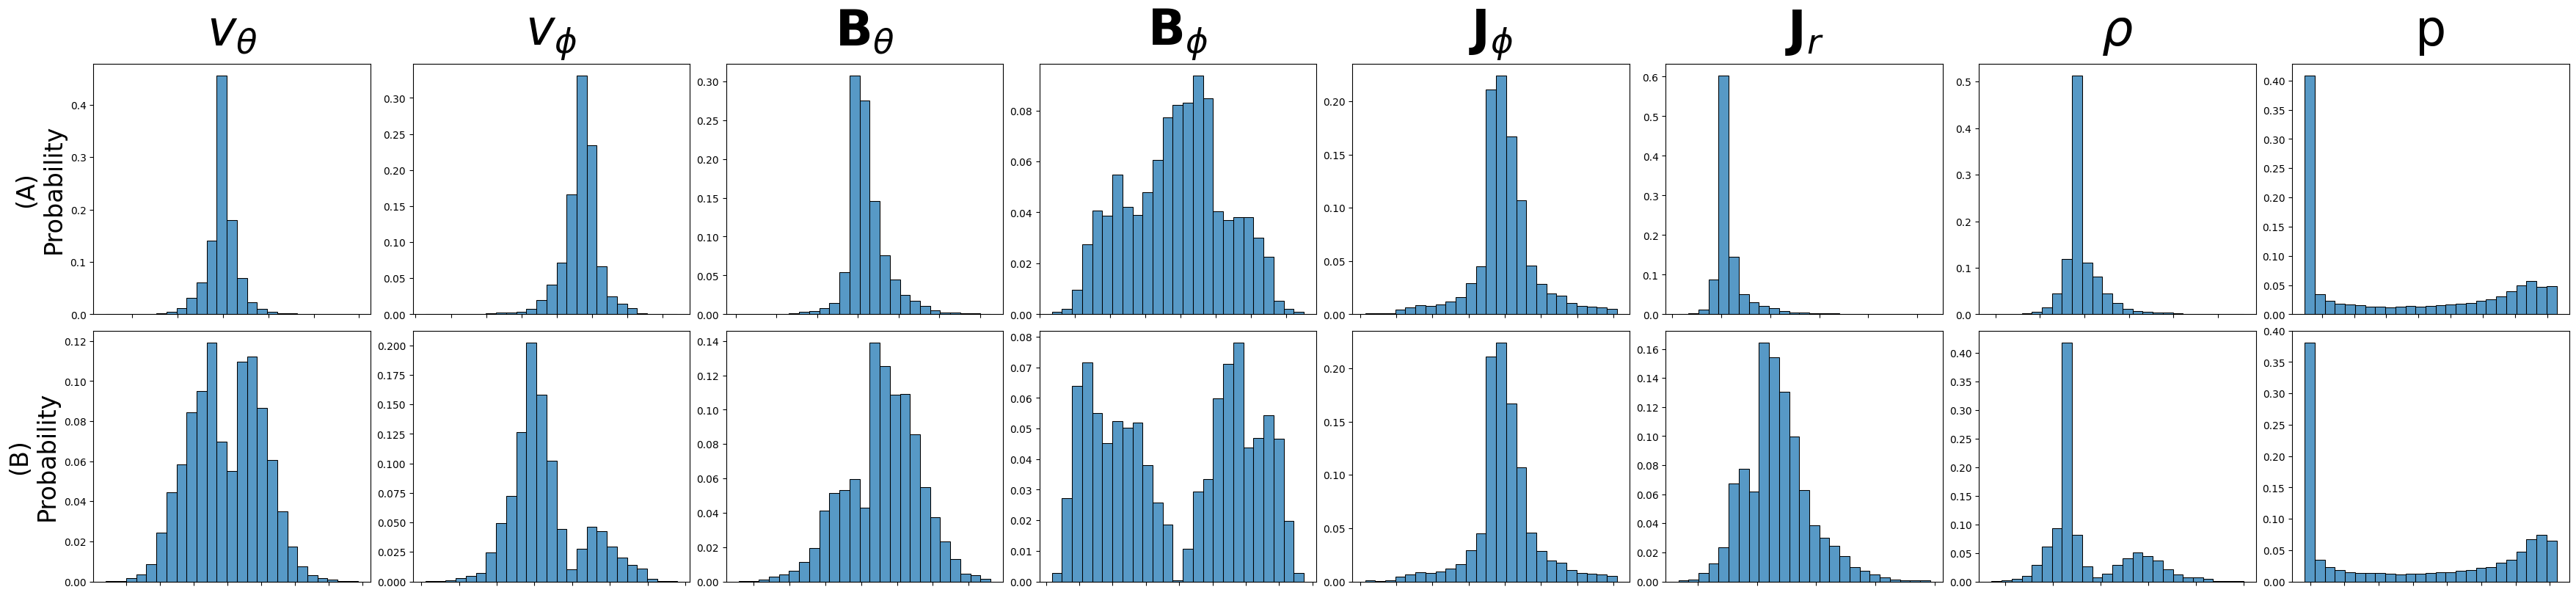

In [321]:
fig, ax = plt.subplots(2, 8, figsize=(35, 8), constrained_layout=True)

for i, c in enumerate([c for c in component_list if c in (set(component_list)-{'jt'})]):
    sns.histplot(
        train_dataset.sims[0, i + 2].reshape((-1,)),
        bins=25,
        stat="probability",
        ax=ax[0, i],
    )
    sns.histplot(
        new_arr[0, i].reshape((-1,)),
        bins=25,
        stat="probability",
        ax=ax[1, i],
    )
    # sns.histplot(
    #     norm_arr[0, i].reshape((-1,)),
    #     bins=25,
    #     stat="probability",
    #     ax=ax[2, i],
    # )

    ax[0, i].set_title(component_title_dict[c], fontsize=48, pad=18)

    for r in range(2):
        ax[r, i].set_xlabel("")
        ax[r, i].set_ylabel("")
        ax[r, i].tick_params(axis="x", labelbottom=False)  # hide x-axis values

    # only first column gets y-axis label
    ax[0, 0].set_ylabel("(A)\nProbability", fontsize=24)
    ax[1, 0].set_ylabel("(B)\nProbability", fontsize=24)
    # ax[2, 0].set_ylabel("(C)\nProbability", fontsize=24)

# plt.tight_layout()
plt.savefig("histogram_distribution/data_transformation.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [170]:
import matplotlib.ticker as mticker

In [225]:
job_id_descriptors = {
    '2026_04_01__065102': {'rank': 0.4, 'model': 'LocalNO'},
    '2026_04_25__075617': {'rank': 0.4, 'model': 'SFNO'},
    '2026_04_27__213057': {'rank': 0.4, 'model': 'TFNO'},
}
for job in job_id_descriptors.keys():
    f = np.load(os.path.join(BASE_DIR, job,'test_best_epoch_per_sample_per_component.npz'))
    for metric in PER_SAMPLE_PER_COMPONENT_METRICS:
        job_id_descriptors[job][metric] = f[metric]

In [226]:
result_rows = []

for run_name, run_data in job_id_descriptors.items():
    for metric in PER_SAMPLE_PER_COMPONENT_METRICS:
        metric_values = run_data[metric]
        row_dict = {}
        for idx, val in enumerate(metric_values):
            row_dict['rank'] = run_data["rank"]
            row_dict['model'] = run_data["model"]
            row_dict['job'] = run_name
            row_dict['metric'] = metric
            row_dict = {component_list[comp]: v for comp, v in enumerate(val)}
            result_rows.append(row_dict)

result_baseline_df = pd.DataFrame(result_rows)
print(result_baseline_df.shape)
result_baseline_df.head(n=10)

(1710, 13)


,vt,vp,bt,bp,jt,jp,jr,rho,p,rank,model,job,metric
0,0.019451,0.020053,1.472986e-07,3.299634e-06,2.398170e-06,1.288869e-05,4.594086e-07,1.077429e-09,3.846071e-14,0.4,LocalNO,2026_04_01__065102,MSE
1,0.004804,0.006773,2.156490e-08,3.309967e-07,6.084532e-07,1.067848e-06,1.105311e-07,9.308410e-11,9.185418e-15,0.4,LocalNO,2026_04_01__065102,MSE
2,0.004443,0.005821,3.459292e-09,2.793712e-07,3.883334e-07,1.043463e-06,8.201101e-08,9.211686e-11,8.818506e-15,0.4,LocalNO,2026_04_01__065102,MSE
3,0.003586,0.003263,7.698546e-10,2.233214e-07,2.765294e-07,5.507462e-07,6.339214e-08,6.227592e-11,2.049029e-14,0.4,LocalNO,2026_04_01__065102,MSE
4,0.005682,0.007838,1.628140e-08,3.246172e-07,6.507017e-07,1.336708e-06,1.096759e-07,1.059029e-10,5.156347e-15,0.4,LocalNO,2026_04_01__065102,MSE
5,0.012048,0.014413,5.707268e-08,7.910967e-07,9.989349e-07,1.964770e-06,2.766257e-07,1.146258e-10,9.465630e-15,0.4,LocalNO,2026_04_01__065102,MSE
6,0.010769,0.025667,4.728639e-08,5.826968e-07,9.348417e-07,2.589795e-06,1.761391e-07,7.092077e-11,8.998316e-15,0.4,LocalNO,2026_04_01__065102,MSE
7,0.011981,0.024556,8.485694e-08,3.226767e-06,2.198354e-05,3.546809e-06,7.349150e-07,7.746397e-10,2.574739e-14,0.4,LocalNO,2026_04_01__065102,MSE
8,0.005224,0.013474,8.683616e-09,7.504712e-07,1.599993e-06,1.518008e-06,2.249925e-07,4.206306e-10,1.359136e-14,0.4,LocalNO,2026_04_01__065102,MSE
9,0.004871,0.016291,4.201206e-09,7.948943e-07,2.103696e-06,1.137448e-06,2.131963e-07,4.561954e-10,1.823991e-14,0.4,LocalNO,2026_04_01__065102,MSE


In [227]:
# result_data_tf_df["transformation"] = result_data_tf_df["transformation"].fillna("None")

# Force desired order
model_order = ['TFNO',"SFNO", "LocalNO"]
result_baseline_df["model"] = pd.Categorical(
    result_baseline_df["model"],
    categories=model_order,
    ordered=True
)

long_df = result_baseline_df.melt(
    id_vars=["metric", "model"],
    value_vars=component_list,
    var_name="component",
    value_name="value"
)

model_metric_summary = (
    long_df
    .groupby(["model", "metric"], observed=True)["value"]
    .agg(["mean", "std"])
    .unstack("metric")
)

model_metric_summary = (
    model_metric_summary
    .swaplevel(0, 1, axis=1)
    .sort_index(axis=1)
    .reindex(model_order)
)

model_metric_summary

metric        ACC                 EMV                 MSE                NNSE  \
             mean       std      mean       std      mean       std      mean   
model                                                                           
TFNO     0.948841  0.075308  0.015026  0.033738  0.019438  0.055544  0.920024   
SFNO     0.630712  0.454170  0.041580  0.110607  0.086952  0.319662  0.765092   
LocalNO  0.987351  0.020497  0.006041  0.012098  0.003984  0.011407  0.975520   

metric                  PSNR                  UQI            
              std       mean        std      mean       std  
model                                                        
TFNO     0.093733  31.820347   8.440102  0.803465  0.188233  
SFNO     0.227425  28.625822  11.436337  0.566160  0.402826  
LocalNO  0.036427  38.697197  10.091477  0.907112  0.092921

In [228]:
len(train_dataset)

907

In [305]:
job_id_descriptors = {
    '2026_04_01__065102': {'rank': 0.4, 'version': 'V2'},
    '2026_05_04__044854': {'rank': 0.4, 'version': 'V3'},
}
for job in job_id_descriptors.keys():
    if job_id_descriptors[job]['version'] == 'V2':
        f = np.load(os.path.join(BASE_DIR, job,'test_best_epoch_per_sample_per_component.npz'))
    else:
        f = np.load(os.path.join('/data/solar_wind_pred_vignesh/ParamNetwork', job,'test_best_epoch_per_sample_per_component.npz'))
    for metric in PER_SAMPLE_PER_COMPONENT_METRICS:
        job_id_descriptors[job][metric] = f[metric]

result_rows = []

for run_name, run_data in job_id_descriptors.items():
    for metric in PER_SAMPLE_PER_COMPONENT_METRICS:
        metric_values = run_data[metric]
        row_dict = {}
        for idx, val in enumerate(metric_values):
            row_dict['rank'] = run_data["rank"]
            row_dict['version'] = run_data["version"]
            row_dict['job'] = run_name
            row_dict['metric'] = metric
            row_dict = {component_list[comp]: v for comp, v in enumerate(val)}
            result_rows.append(row_dict)

result_version_df = pd.DataFrame(result_rows)
print(result_version_df.shape)
result_version_df.head(n=10)

(1140, 13)


,vt,vp,bt,bp,jt,jp,jr,rho,p,rank,version,job,metric
0,0.019451,0.020053,1.472986e-07,3.299634e-06,2.398170e-06,1.288869e-05,4.594086e-07,1.077429e-09,3.846071e-14,0.4,V2,2026_04_01__065102,MSE
1,0.004804,0.006773,2.156490e-08,3.309967e-07,6.084532e-07,1.067848e-06,1.105311e-07,9.308410e-11,9.185418e-15,0.4,V2,2026_04_01__065102,MSE
2,0.004443,0.005821,3.459292e-09,2.793712e-07,3.883334e-07,1.043463e-06,8.201101e-08,9.211686e-11,8.818506e-15,0.4,V2,2026_04_01__065102,MSE
3,0.003586,0.003263,7.698546e-10,2.233214e-07,2.765294e-07,5.507462e-07,6.339214e-08,6.227592e-11,2.049029e-14,0.4,V2,2026_04_01__065102,MSE
4,0.005682,0.007838,1.628140e-08,3.246172e-07,6.507017e-07,1.336708e-06,1.096759e-07,1.059029e-10,5.156347e-15,0.4,V2,2026_04_01__065102,MSE
5,0.012048,0.014413,5.707268e-08,7.910967e-07,9.989349e-07,1.964770e-06,2.766257e-07,1.146258e-10,9.465630e-15,0.4,V2,2026_04_01__065102,MSE
6,0.010769,0.025667,4.728639e-08,5.826968e-07,9.348417e-07,2.589795e-06,1.761391e-07,7.092077e-11,8.998316e-15,0.4,V2,2026_04_01__065102,MSE
7,0.011981,0.024556,8.485694e-08,3.226767e-06,2.198354e-05,3.546809e-06,7.349150e-07,7.746397e-10,2.574739e-14,0.4,V2,2026_04_01__065102,MSE
8,0.005224,0.013474,8.683616e-09,7.504712e-07,1.599993e-06,1.518008e-06,2.249925e-07,4.206306e-10,1.359136e-14,0.4,V2,2026_04_01__065102,MSE
9,0.004871,0.016291,4.201206e-09,7.948943e-07,2.103696e-06,1.137448e-06,2.131963e-07,4.561954e-10,1.823991e-14,0.4,V2,2026_04_01__065102,MSE


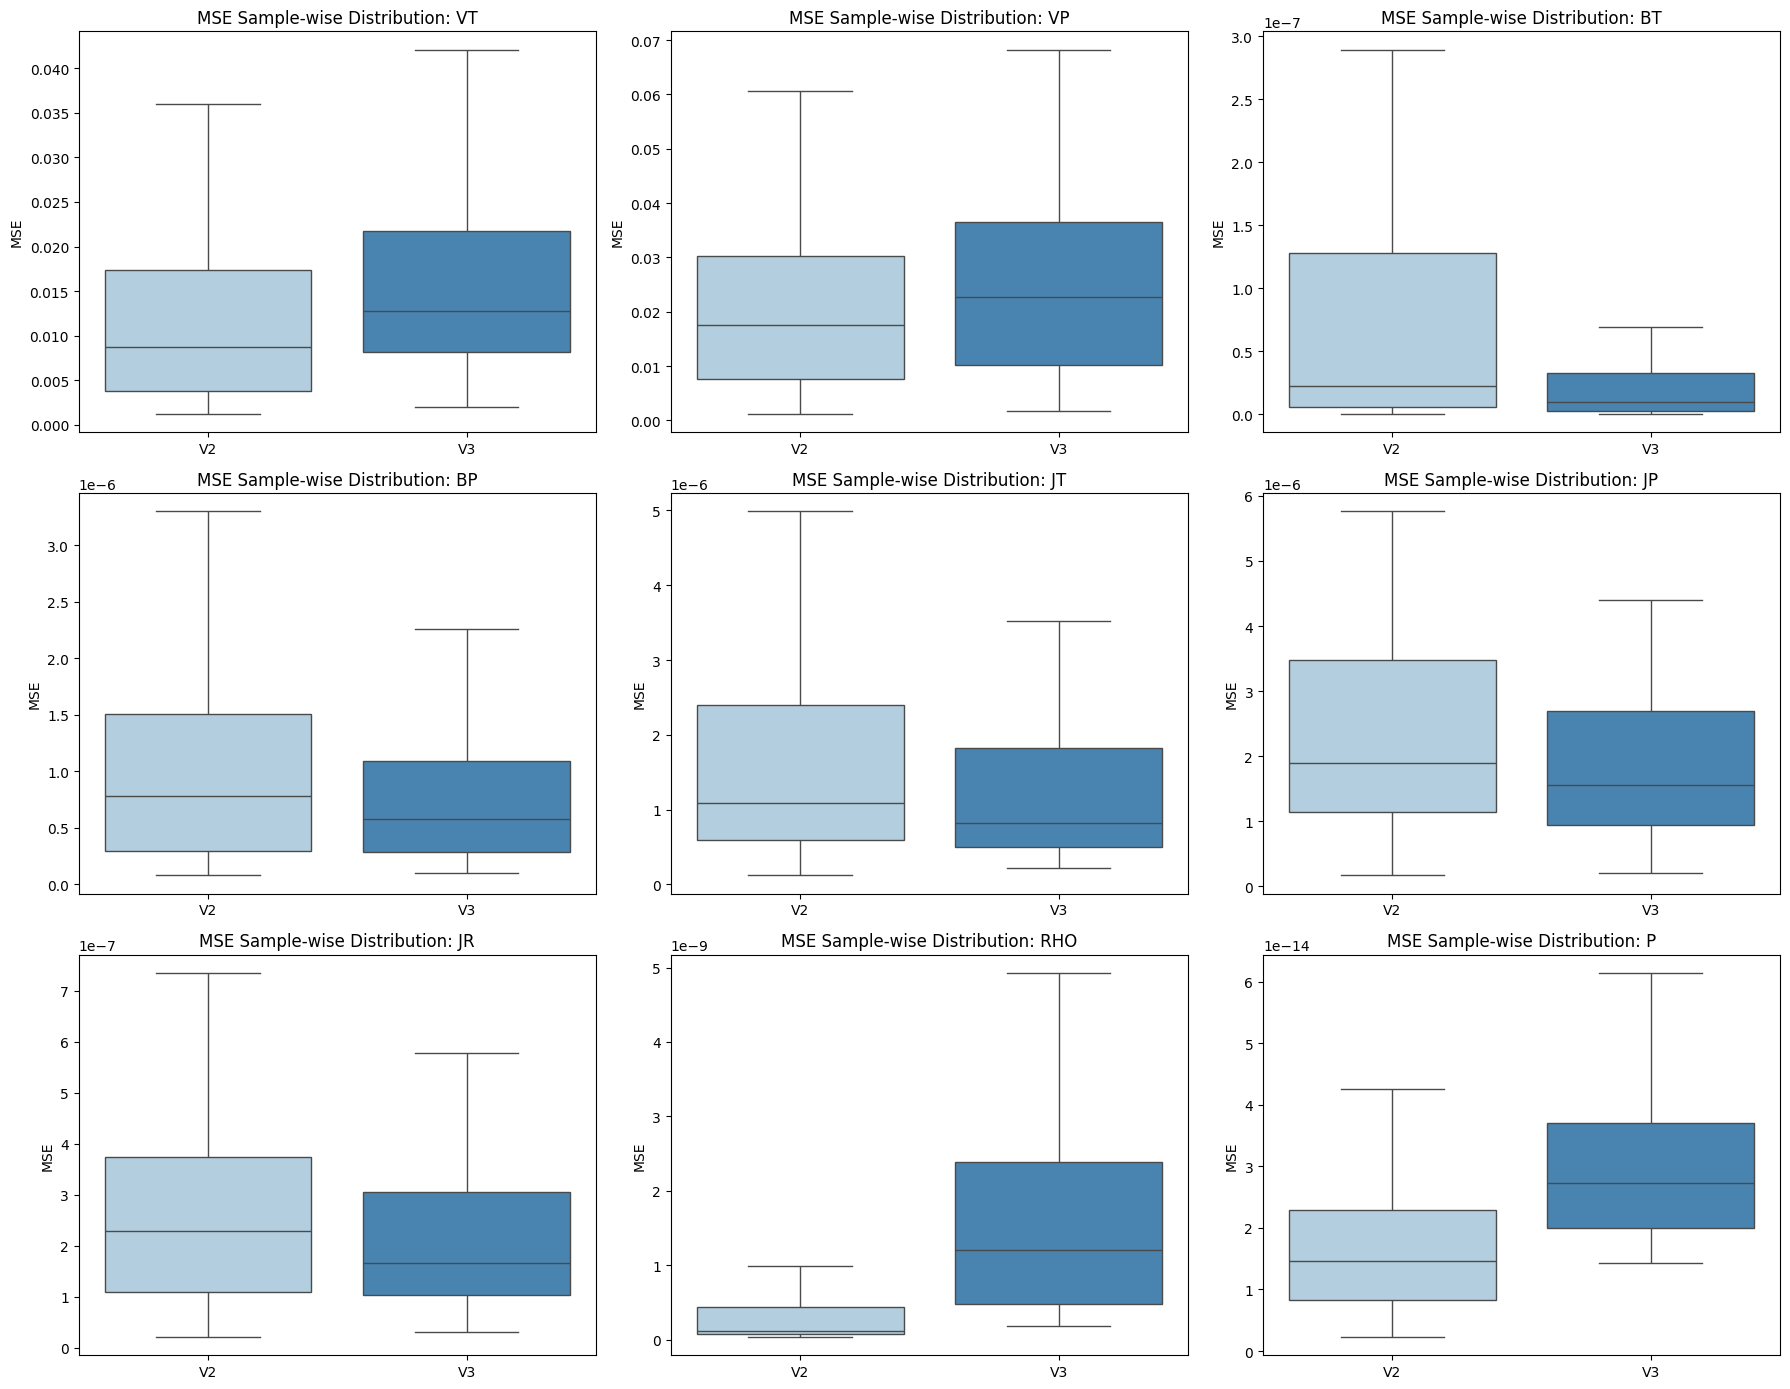

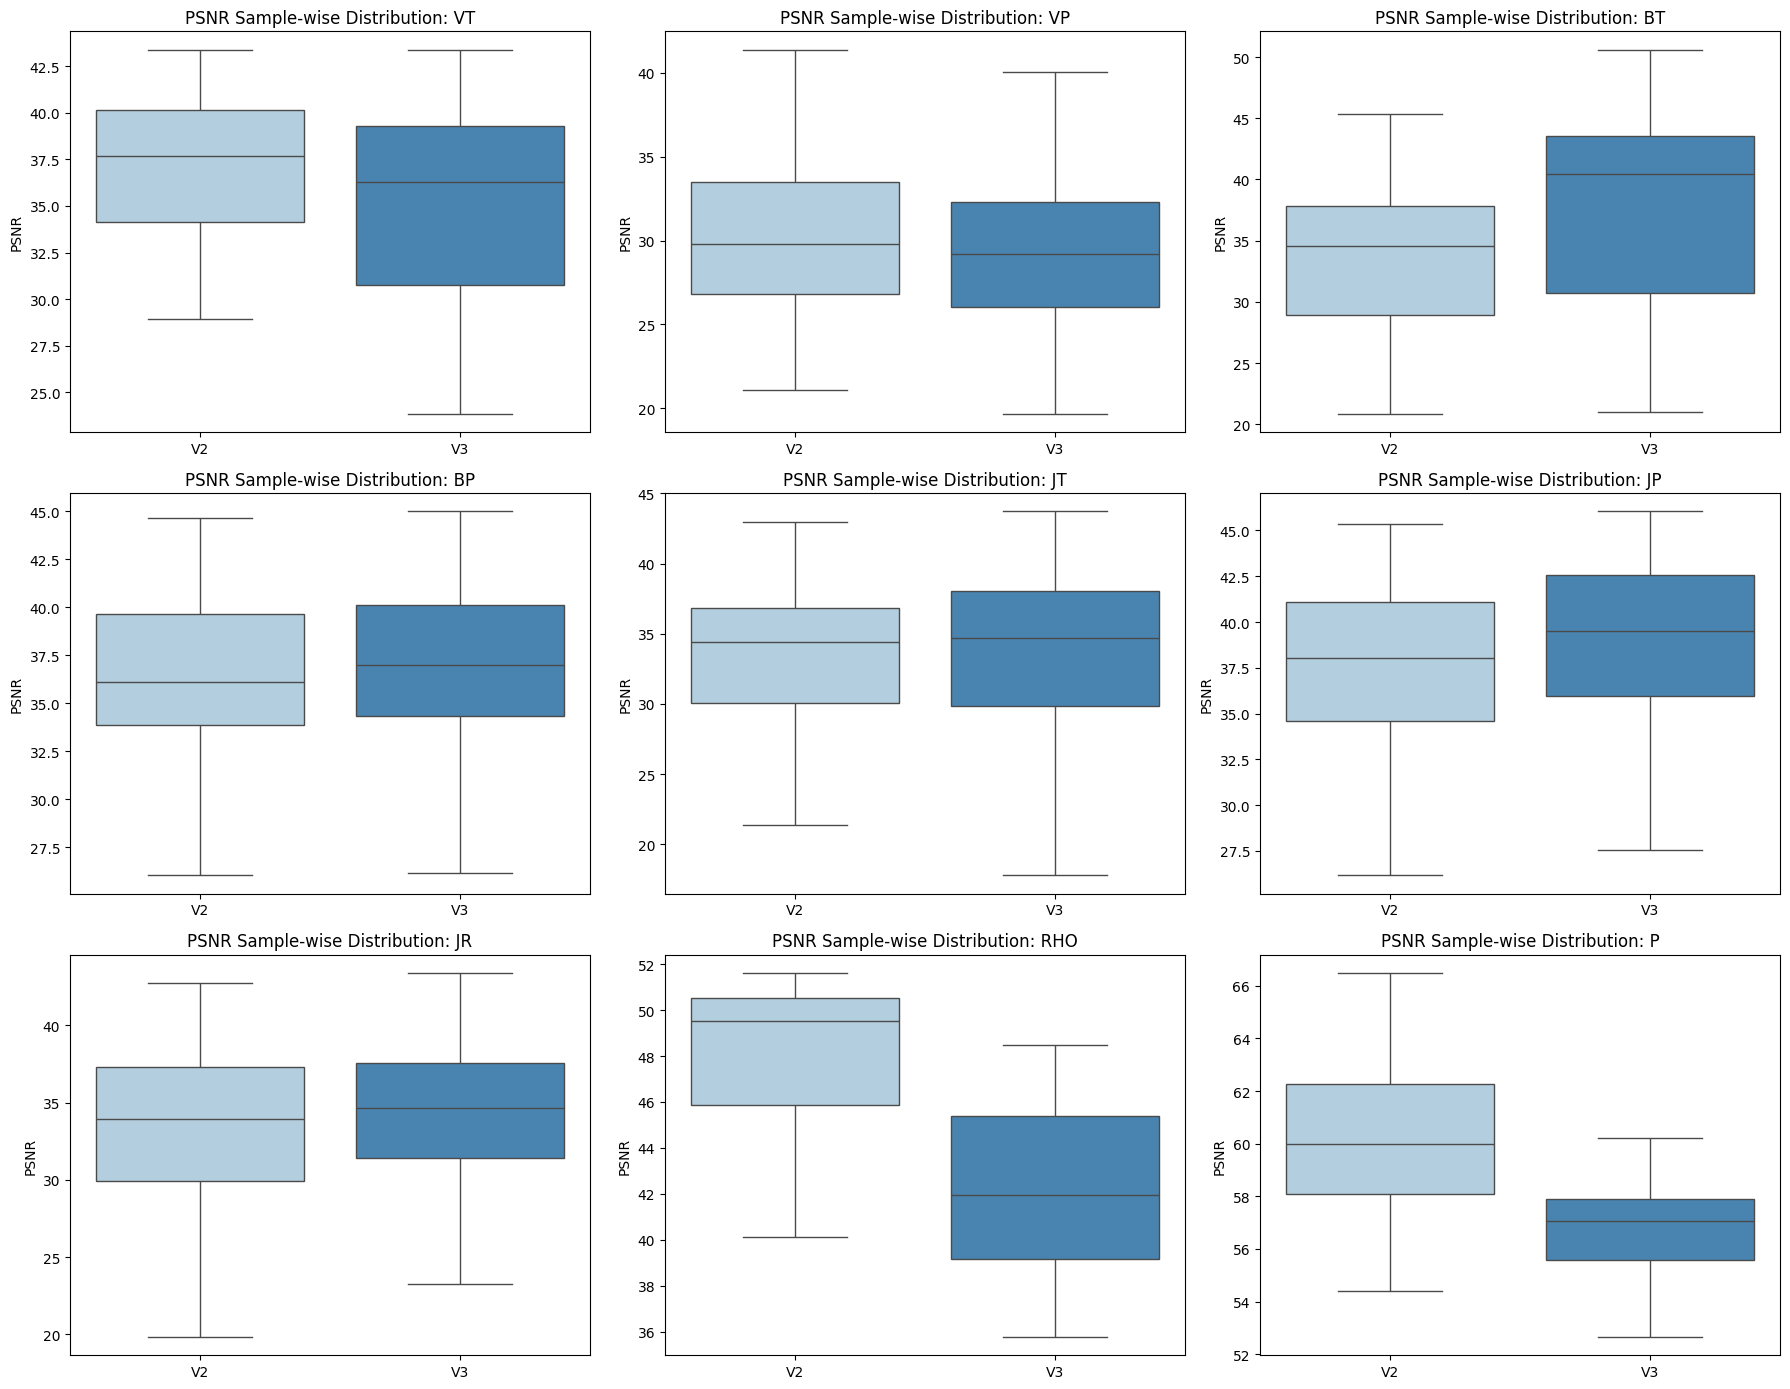

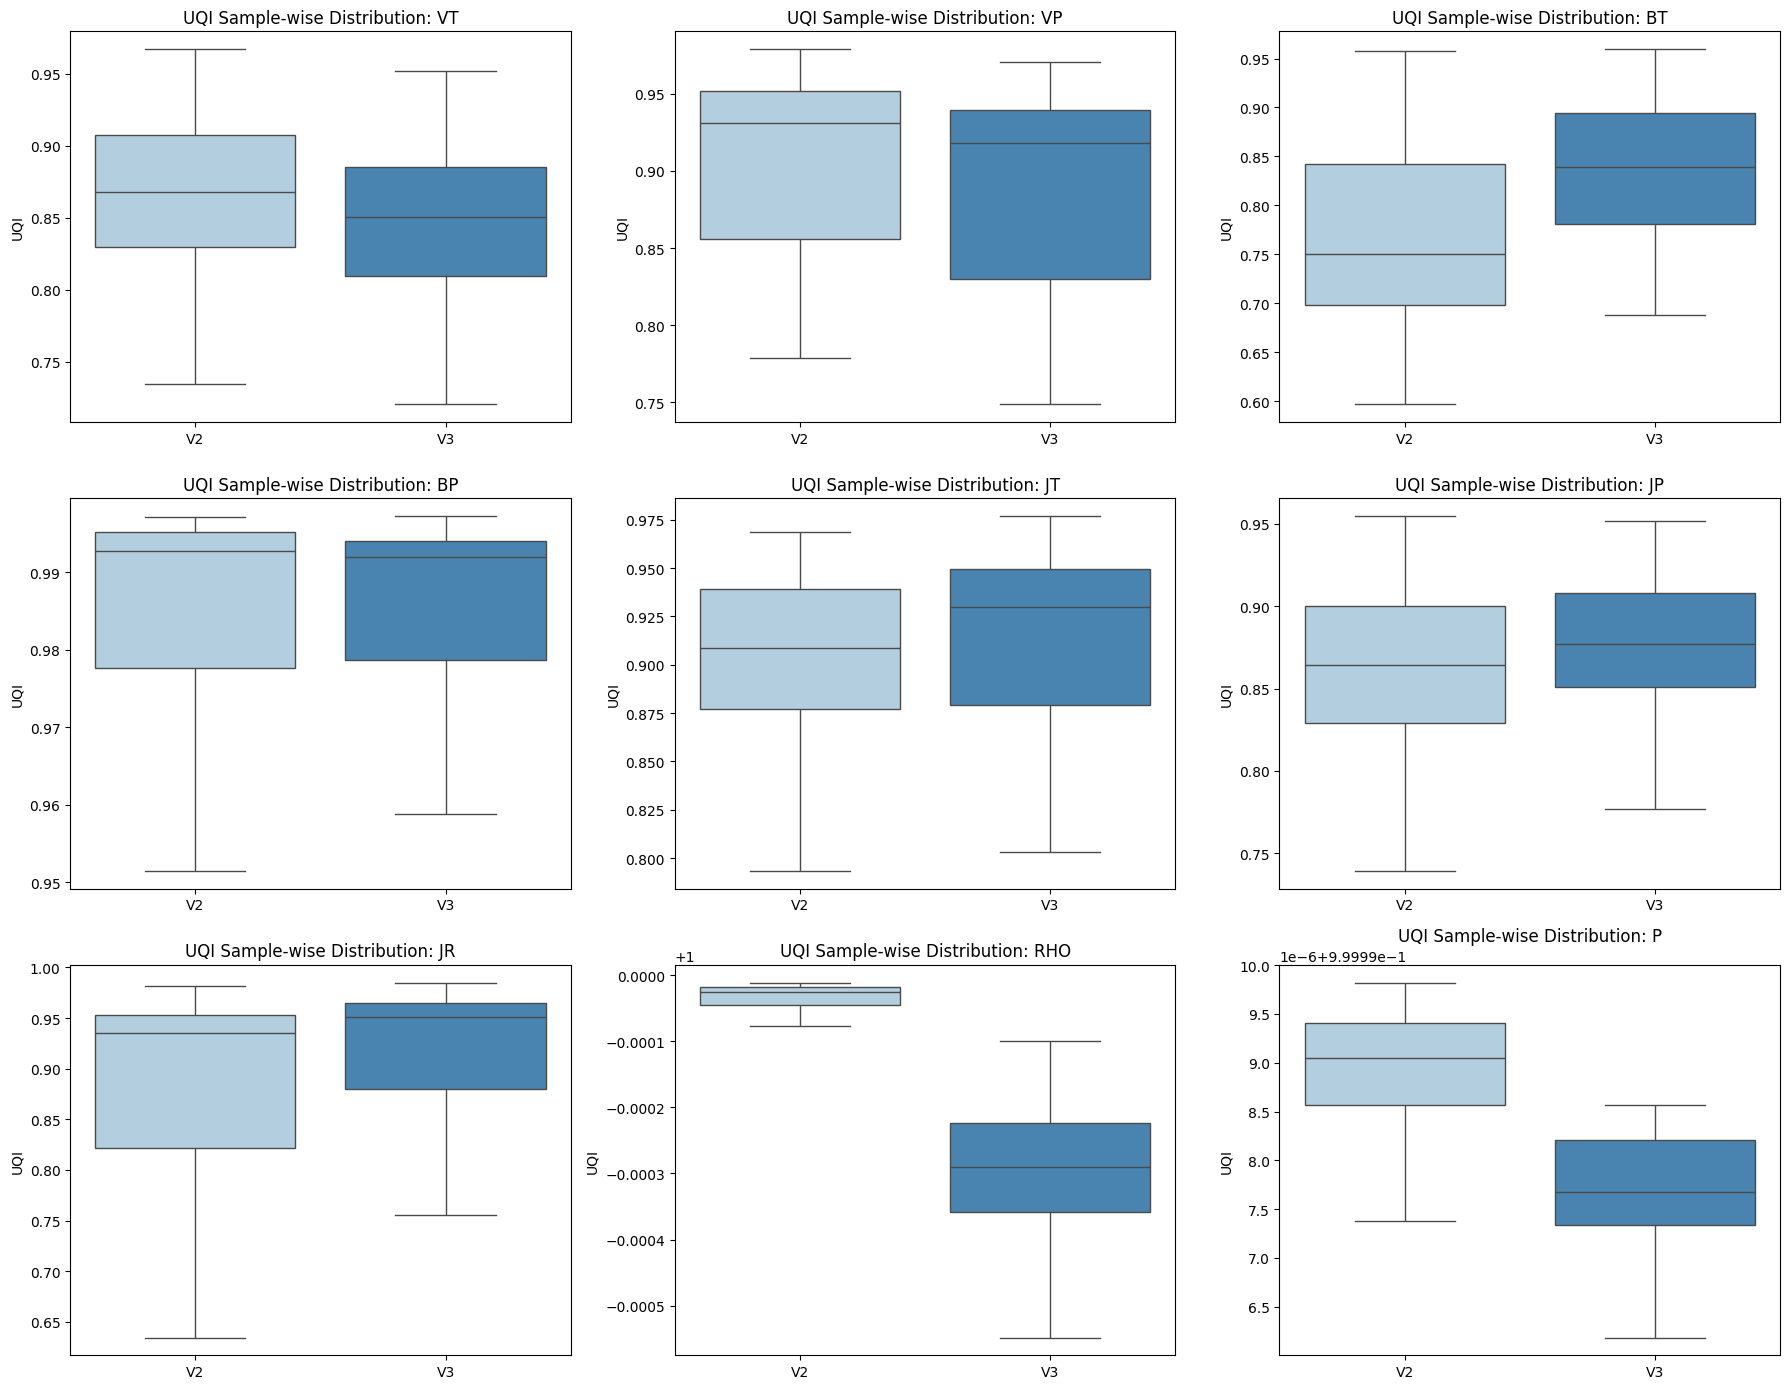

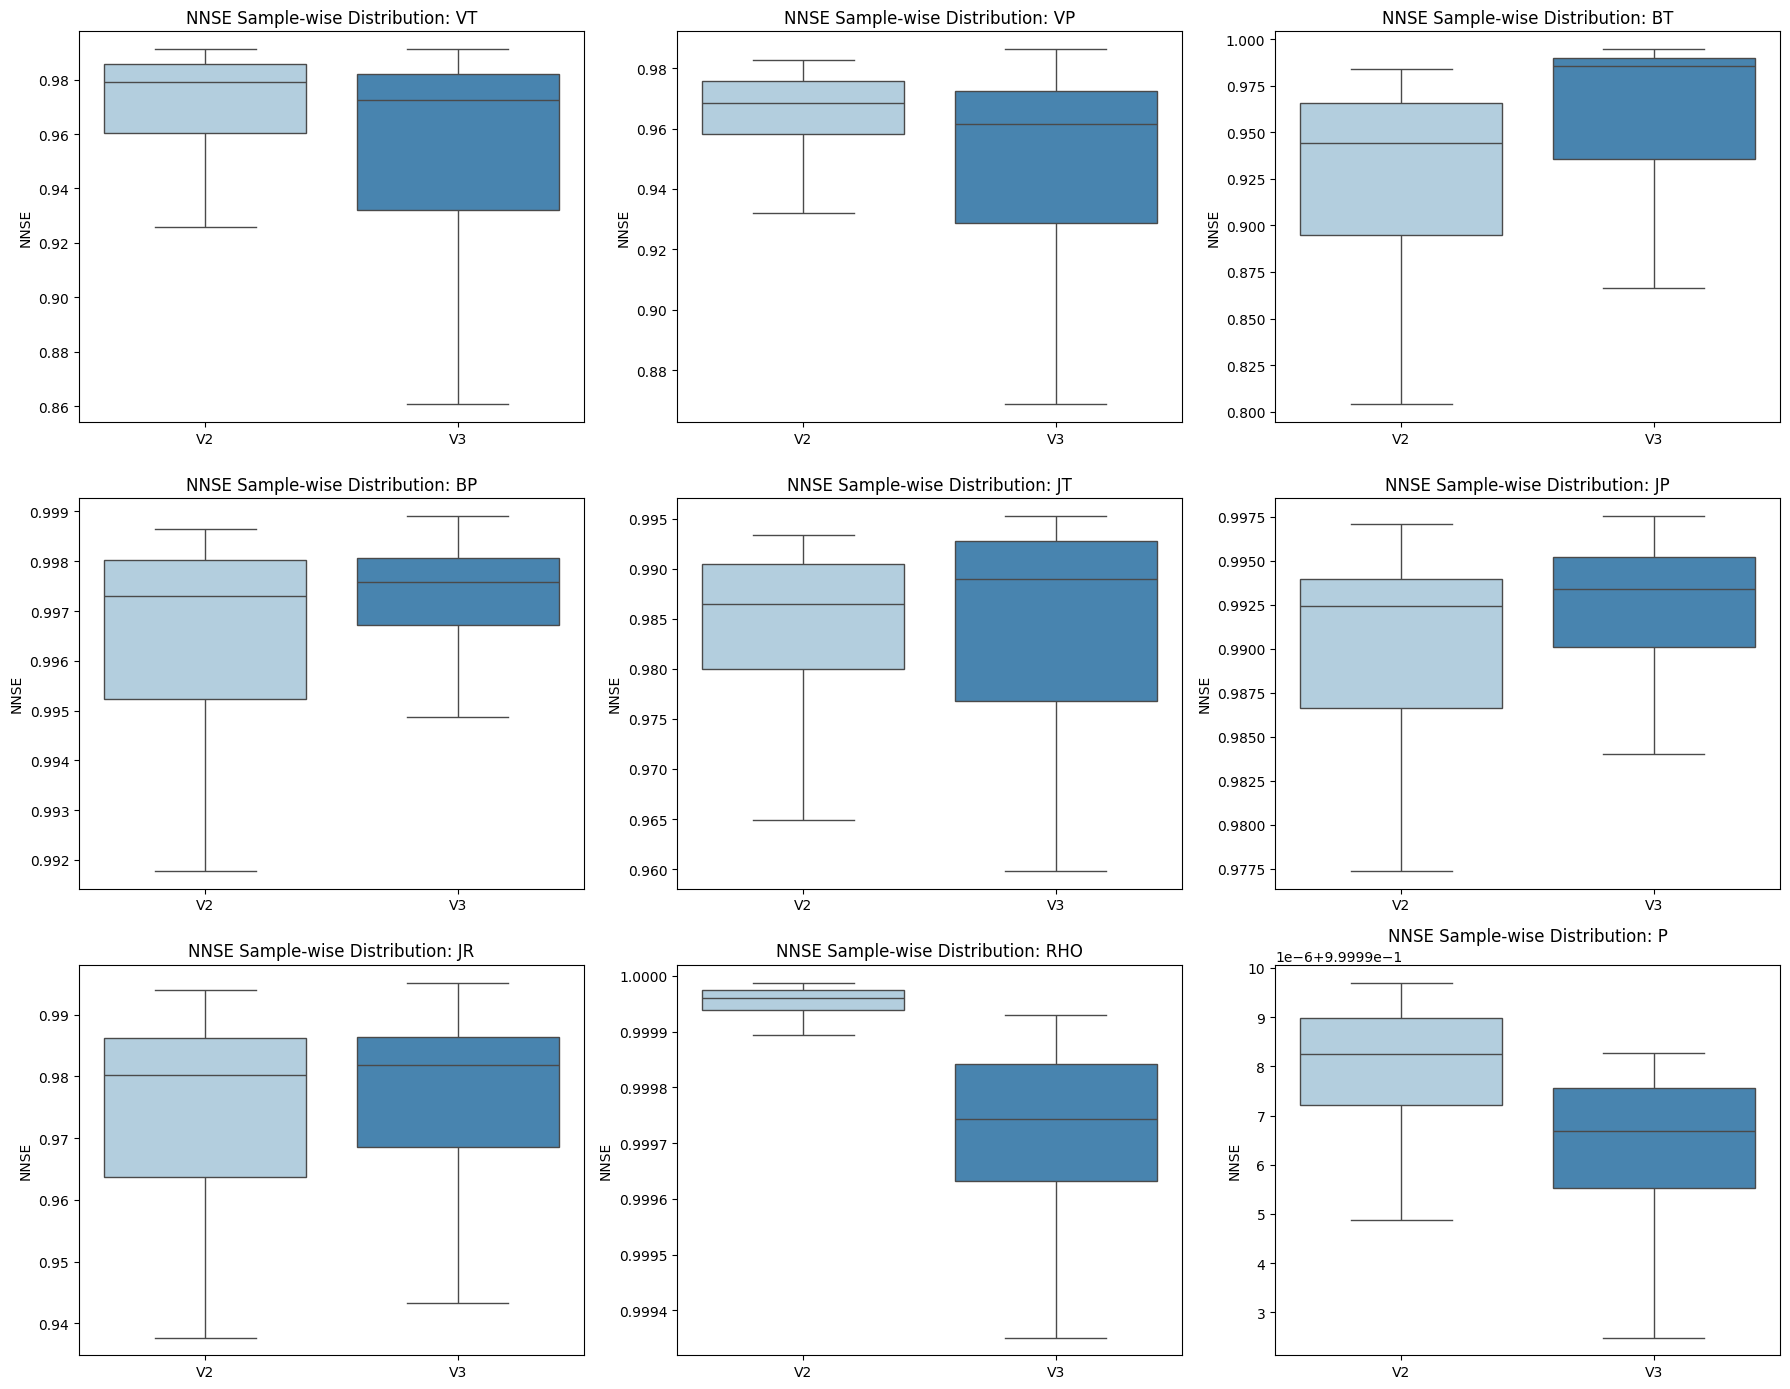

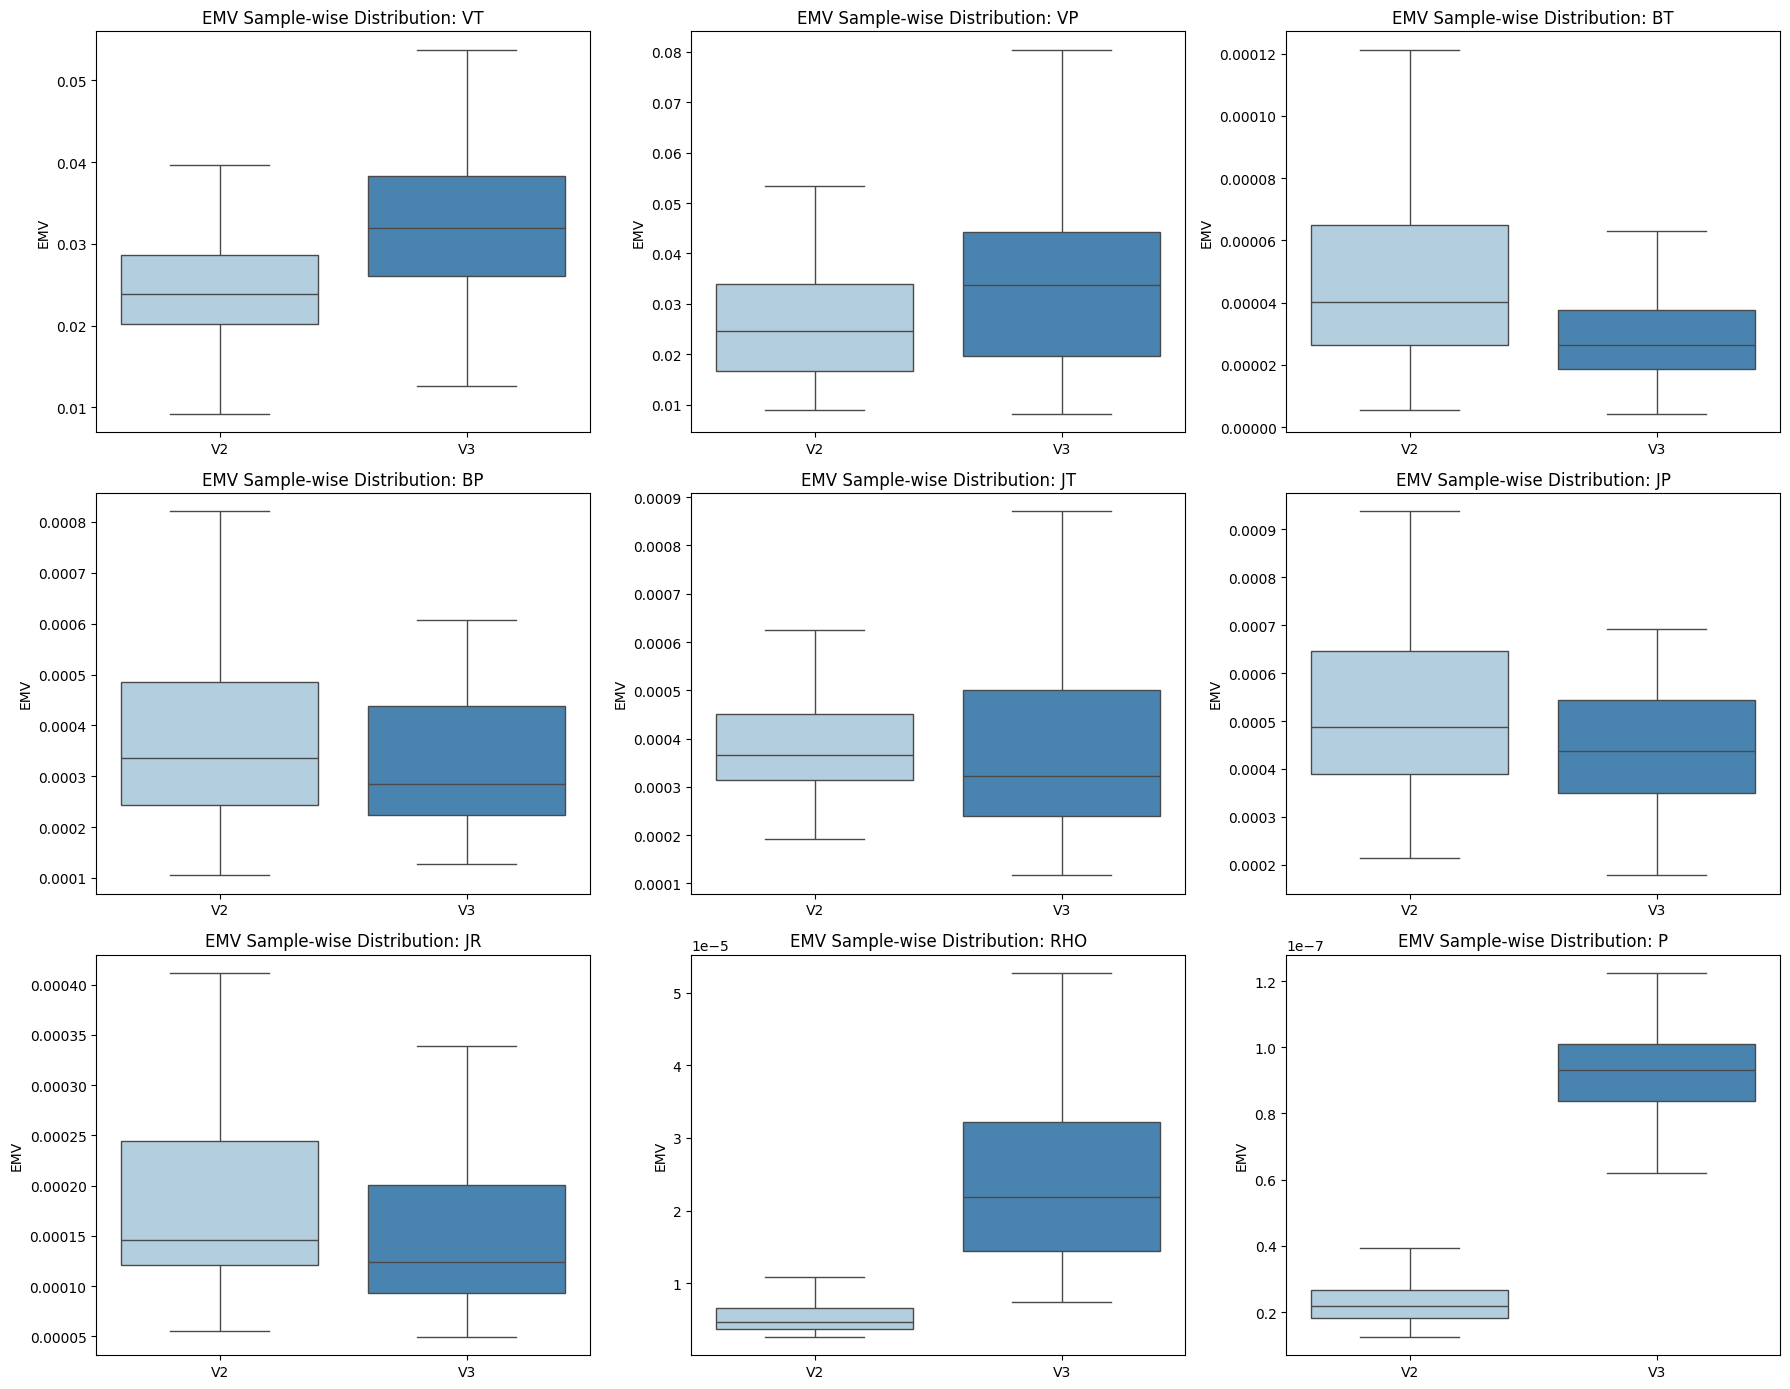

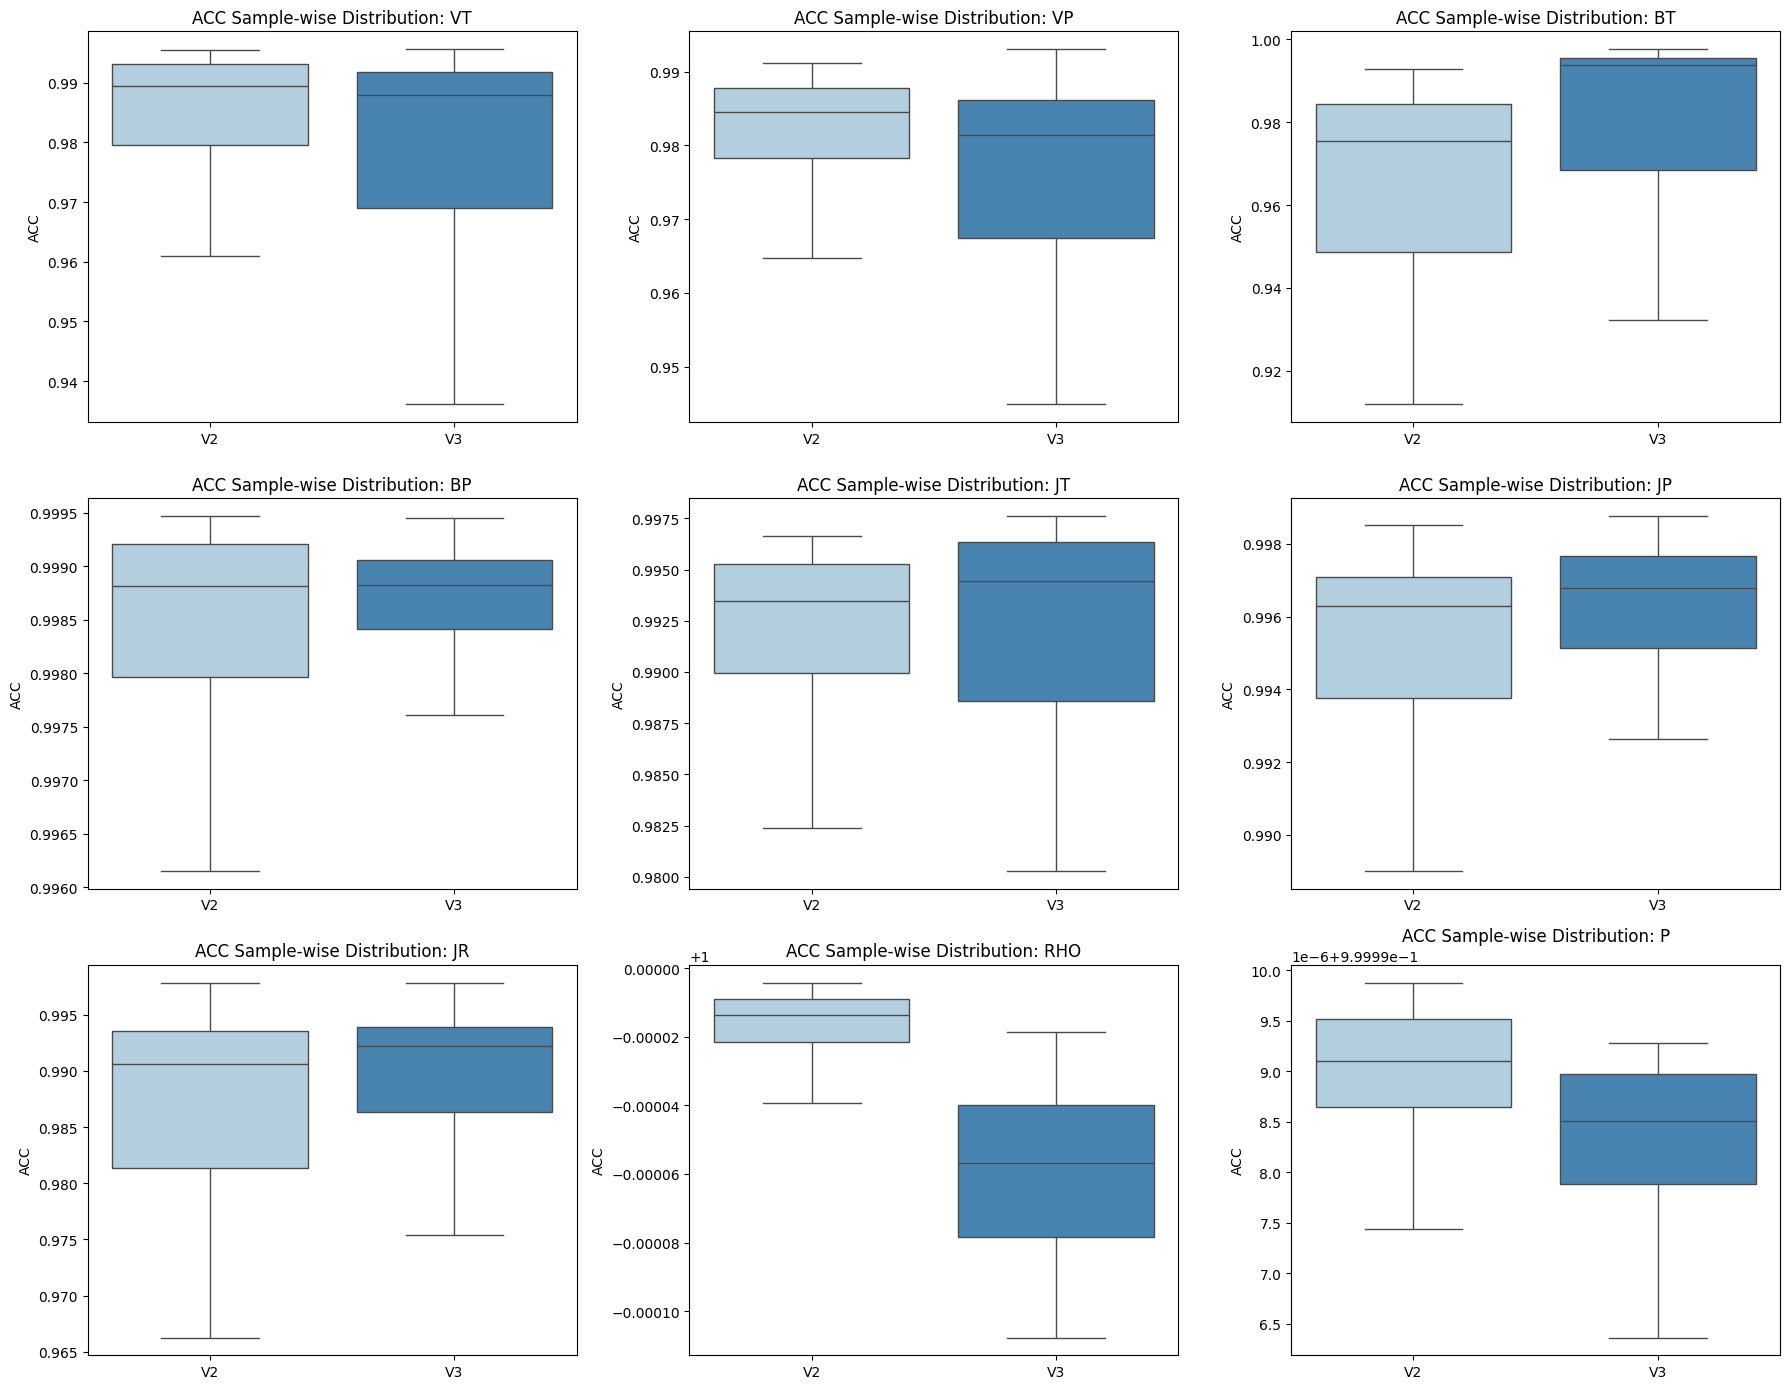

In [307]:
for metric in PER_SAMPLE_PER_COMPONENT_METRICS:
    metric_df = result_version_df[result_version_df['metric'] == metric]
    
    fig, axes = plt.subplots(3, 3, figsize=(18, 14), sharey=False)
    axes = axes.flatten()
    
    for i, comp in enumerate(component_list):
        sns.boxplot(
            data=metric_df,
            x="version",              # distribution per run
            y=comp,               # PSNR values for this component
            hue="version",           # color by rank
            ax=axes[i],
            showfliers=False,
            palette="Blues",
            # legend=False
            # showfliers=True,
        )
        axes[i].set_title(f"{metric} Sample-wise Distribution: {comp.upper()}")
        axes[i].set_xlabel("")
        axes[i].set_ylabel(metric)
        axes[i].tick_params(axis="x", rotation=0)
        # axes[i].legend(title="Rank")
        # axes[i].legend_.remove()
    
    plt.tight_layout()
    plt.savefig(os.path.join('data_transform_ablation', f'model_arch_distribution_{metric}.png'), dpi=200)
    plt.show()

In [299]:
instrument_dict = {}
for cr in cr_dirs:
    for instrument in os.listdir(os.path.join(DATA_DIR, cr)):
        # print(folders)
        instrument_dict[instrument] = instrument_dict.get(instrument,0) + 1

instrument_dict

{'hmi_mast_mas_std_0201': 137,
 'hmi_masp_mas_std_0201': 111,
 'hmi_mast_mas_std_0101': 138,
 'mdi_mas_mas_std_0201': 98,
 'mdi_mas_mas_std_0101': 148,
 'kpo_mas_mas_std_0101': 275}

In [293]:
print(DATA_DIR)

/data/solar_wind_pred_vignesh/hdf/medium


In [300]:
sum(instrument_dict.values())

907